# Sales Revenue Forecasting — Online Retail II Dataset

> **Corporate Implementation** | Technical Process Documentation V1.1

**Objective:** Forecast weekly sales revenue (£) to support supply chain, inventory planning, and business growth decisions

**Models:** SARIMA | Facebook Prophet | Gradient Boosting | Random Forest

**Primary Metric:** MAPE on a 0-100 scale | **Secondary Context:** MAE (£)

---

### 📋 Pipeline Steps
| Step | Description |
|------|-------------|
| 1 | Environment Setup & Libraries |
| 2 | Data Loading |
| 3 | Data Diagnostics |
| 4 | Data Cleaning & Processing |
| 5 | Target Variable — Weekly Revenue |
| 6 | Predictive Variable Engineering (Direct + Derived) |
| 7 | Stationarity Analysis (ADF, ACF, PACF) |
| 8 | Train / Validation / Test Split — time ordered |
| 9 | Model 1 — SARIMA |
| 10 | Model 2 — Facebook Prophet |
| 11 | Model 3 — Gradient Boosting |
| 12 | Evaluation — Validation MAPE + Held-out Test MAPE |
| 13 | Test Breakdown — Equal Time Periods |
| 14 | Algorithmic Solution Finalization & 12-Week Forecast |
| 15 | Full Operational Dashboard |
| 16 | Residual Diagnostics |
| 17 | Algorithm Comparison Table |
| 18 | Export All Results to CSV |

---
**How to use the data file:** The notebook now looks for `online_retail_II.xlsx` automatically in this repo or in Google Drive when run in Colab.


## CELL 1 — ENVIRONMENT SETUP & LIBRARY INSTALLATION

## we can skip this


In [3]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    try:
        from fbprophet import Prophet
        PROPHET_AVAILABLE = True
    except ImportError:
        PROPHET_AVAILABLE = False
        print("⚠️  Prophet not installed. Run:  !pip install prophet --quiet")
        print("   Prophet cell will be skipped. All other cells will run normally.")

np.random.seed(42)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

C_NAVY   = '#1F3864'
C_BLUE   = '#2E75B6'
C_LTBLUE = '#BDD7EE'
C_AMBER  = '#C55A11'
C_GREEN  = '#375623'
C_LGREEN = '#E2EFDA'
C_RED    = '#C00000'
C_GRAY   = '#595959'
C_LGRAY  = '#F2F2F2'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'grid.color':       '#CCCCCC',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'figure.titlesize': 14,
    'figure.titleweight': 'bold',
})

print("=" * 65)
print("  SALES REVENUE FORECASTING  |  Online Retail II")
print("  Corporate Implementation   |  Technical Doc V1.1")
print("=" * 65)
print(f"\n  Prophet available : {'✅ Yes' if PROPHET_AVAILABLE else '❌ No — run !pip install prophet'}")
print(f"  NumPy version     : {np.__version__}")
print(f"  Pandas version    : {pd.__version__}")
print("\n✅ Environment ready. Proceed to Cell 2.")


  SALES REVENUE FORECASTING  |  Online Retail II
  Corporate Implementation   |  Technical Doc V1.1

  Prophet available : ✅ Yes
  NumPy version     : 2.0.2
  Pandas version    : 2.2.2

✅ Environment ready. Proceed to Cell 2.


## CELL 2 — DATA LOADING


In [4]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

candidate_files = [
    Path('Retail/online_retail_II.xlsx'),
    Path('../online_retail_II.xlsx'),
    Path('online_retail_II.xlsx'),
    Path('/content/drive/MyDrive/online_retail_II.xlsx'),
    Path('/content/drive/MyDrive/online_retail.xlsx'),
]

if IN_COLAB and not any(path.exists() for path in candidate_files):
    drive.mount('/content/drive')

file_loc = None
for path in candidate_files:
    if path.exists():
        file_loc = str(path)
        break

if file_loc is None:
    raise FileNotFoundError(
        "Could not find online_retail_II.xlsx. Place it in Retail/, next to the notebook, "
        "or in /content/drive/MyDrive/ when running in Colab."
    )

print(f"Using data file: {file_loc}")


Mounted at /content/drive
Using data file: /content/drive/MyDrive/online_retail.xlsx


In [5]:
s1 = pd.read_excel(file_loc, sheet_name='Year 2009-2010')
s2 = pd.read_excel(file_loc, sheet_name='Year 2010-2011')
df_raw = pd.concat([s1, s2], ignore_index=True)

print(f"Loaded rows: {len(df_raw):,}")
print(f"Sheets used : Year 2009-2010 + Year 2010-2011")


Loaded rows: 1,067,371
Sheets used : Year 2009-2010 + Year 2010-2011


## CELL 3 — STEP 1: DATA DIAGNOSTICS

STEP 1 — DATA DIAGNOSTICS  
The following quality checks are  
performed on the raw extract BEFORE any cleaning or transformation:  
• Number of records  
• Duplicate records  
• Missing values in relevant fields  
• Sum of a numeric field
• Data period confirmation  
These diagnostics are logged as a formal audit trail and presented  
as a structured summary table — standard practice in corporate  
data science projects.  


  STEP 1 — DATA DIAGNOSTICS

  Check                                             Result
  ---------------------------------------------------------
  Total records                                  1,067,371
  Duplicate rows                                    34,335  ⚠️
  Missing Invoice                                        0
  Missing StockCode                                      0
  Missing Description                                4,382  ⚠️
  Missing Quantity                                       0
  Missing Price                                          0
  Missing Customer ID                     243,007  (22.8%)  ⚠️
  Missing Country                                        0
  Cancelled invoices (C)                            19,494  ⚠️
  Negative quantities                               22,950  ⚠️
  Zero / negative price                              6,207  ⚠️
  Sum of Quantity (raw)                         10,608,492
  Date start                                    2009-12-01
  

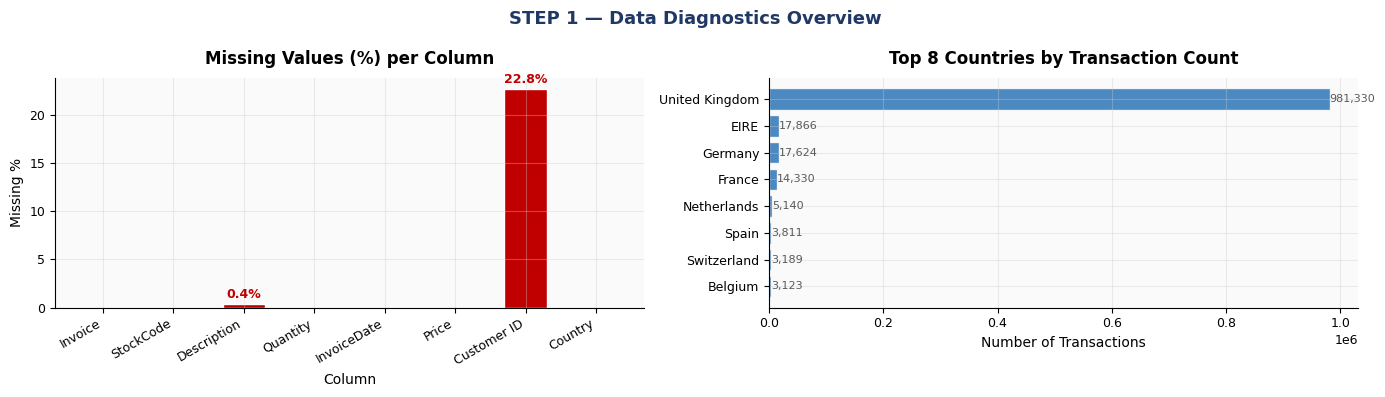


✅  Diagnostics complete — proceed to cleaning.


In [6]:
print("=" * 65)
print("  STEP 1 — DATA DIAGNOSTICS")
print("=" * 65)

diag = {
    "Total records":          f"{len(df_raw):,}",
    "Duplicate rows":         f"{df_raw.duplicated().sum():,}",
    "Missing Invoice":        f"{df_raw['Invoice'].isna().sum():,}",
    "Missing StockCode":      f"{df_raw['StockCode'].isna().sum():,}",
    "Missing Description":    f"{df_raw['Description'].isna().sum():,}",
    "Missing Quantity":       f"{df_raw['Quantity'].isna().sum():,}",
    "Missing Price":          f"{df_raw['Price'].isna().sum():,}",
    "Missing Customer ID":    f"{df_raw['Customer ID'].isna().sum():,}  ({df_raw['Customer ID'].isna().mean()*100:.1f}%)",
    "Missing Country":        f"{df_raw['Country'].isna().sum():,}",
    "Cancelled invoices (C)": f"{df_raw['Invoice'].astype(str).str.startswith('C').sum():,}",
    "Negative quantities":    f"{(df_raw['Quantity']<0).sum():,}",
    "Zero / negative price":  f"{(df_raw['Price']<=0).sum():,}",
    "Sum of Quantity (raw)":  f"{df_raw['Quantity'].sum():,}",
    "Date start":             str(df_raw['InvoiceDate'].min().date()),
    "Date end":               str(df_raw['InvoiceDate'].max().date()),
    "Unique products":        f"{df_raw['StockCode'].nunique():,}",
    "Unique customers":       f"{df_raw['Customer ID'].nunique():,}",
    "Unique countries":       f"{df_raw['Country'].nunique():,}",
}
print(f"\n  {'Check':<30} {'Result':>25}")
print("  " + "-"*57)
for k, v in diag.items():
    flag = "  ⚠️" if any(x in k.lower() for x in ['cancel','negative','duplicate','missing']) and v.split()[0] != "0" else ""
    print(f"  {k:<30} {v:>25}{flag}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
miss_pct = df_raw.isnull().mean() * 100
colours  = [C_RED if v > 0 else C_BLUE for v in miss_pct.values]
bars = ax.bar(miss_pct.index, miss_pct.values, color=colours, width=0.6, edgecolor='white')
ax.set_title("Missing Values (%) per Column", pad=10)
ax.set_ylabel("Missing %")
ax.set_xlabel("Column")
for bar, val in zip(bars, miss_pct.values):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%',
                ha='center', va='bottom', fontsize=9, color=C_RED, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

ax2 = axes[1]
country_counts = df_raw['Country'].value_counts().head(8)
ax2.barh(country_counts.index[::-1], country_counts.values[::-1],
         color=C_BLUE, alpha=0.85, edgecolor='white')
ax2.set_title("Top 8 Countries by Transaction Count", pad=10)
ax2.set_xlabel("Number of Transactions")
for i, (idx, val) in enumerate(zip(country_counts.index[::-1], country_counts.values[::-1])):
    ax2.text(val + 30, i, f'{val:,}', va='center', fontsize=8, color=C_GRAY)

plt.suptitle("STEP 1 — Data Diagnostics Overview", fontsize=13, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print("\n✅  Diagnostics complete — proceed to cleaning.")


## CELL 4 — STEP 2: DATA CLEANING & PROCESSING (IMAGE NEEDS TO BE FIXED!!!)

STEP 2 — DATA CLEANING & PROCESSING  
Data Processing section, the following  

**transformations are applied in sequence:**

1.  Remove exact duplicate rows  
2.  Remove cancelled invoices (prefix 'C') — returns ≠ demand  
3.  Remove negative/zero quantities  
4.  Remove zero/negative prices (data entry errors)  
5.  Parse InvoiceDate as datetime  
6.  Extract time features: Year, Month, Week
7.  Create Revenue = Quantity × Price  ← our TARGET variable  
8.  Flag weekend transactions (business context)  
After cleaning, a reconciliation table confirms data integrity.  


  STEP 2 — DATA CLEANING & PROCESSING

  Cleaning audit trail:
  Step                               Removed    Remaining
  -------------------------------------------------------
  1. Remove duplicates                34,335    1,033,036
  2. Remove cancellations (C)         19,104    1,013,932
  3. Remove qty <= 0                   3,393    1,010,539
  4. Remove price <= 0                 2,626    1,007,913
  7. Revenue column created                0    1,007,913

  Raw records    :  1,067,371
  Removed total  :     59,458  (5.6%)
  Clean records  :  1,007,913  (94.4% retained)
  Total Revenue  : £20,476,260.45
  Date range     : 2009-12-01 → 2011-12-09


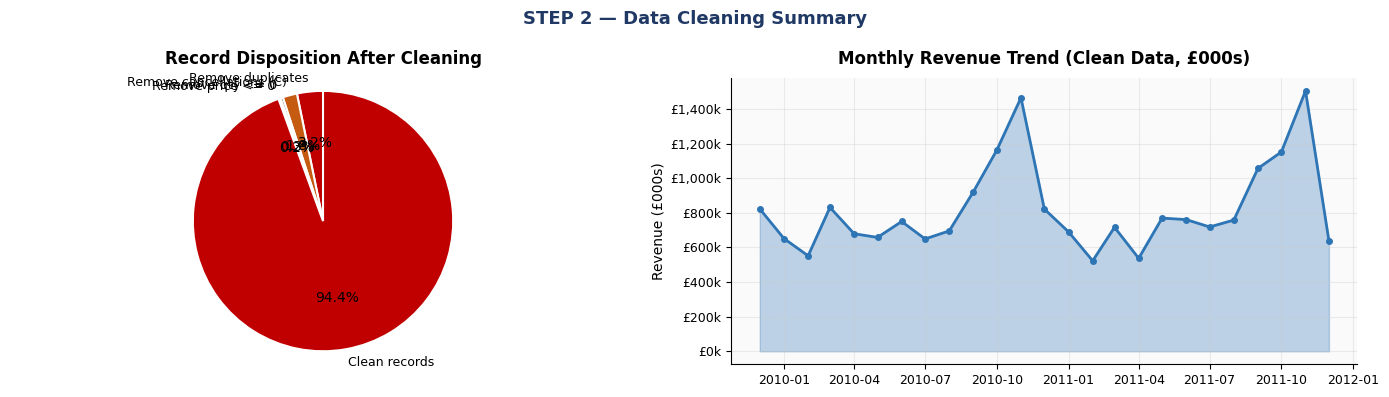

  Invoice StockCode                          Description  Quantity         InvoiceDate  Price  Customer ID         Country  Year  Month  Week  DayOfWeek  IsWeekend  Revenue        Date
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12 2009-12-01 07:45:00   6.95    13,085.00  United Kingdom  2009     12    49          1          0    83.40  2009-12-01
1  489434    79323P                   PINK CHERRY LIGHTS        12 2009-12-01 07:45:00   6.75    13,085.00  United Kingdom  2009     12    49          1          0    81.00  2009-12-01
2  489434    79323W                  WHITE CHERRY LIGHTS        12 2009-12-01 07:45:00   6.75    13,085.00  United Kingdom  2009     12    49          1          0    81.00  2009-12-01
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48 2009-12-01 07:45:00   2.10    13,085.00  United Kingdom  2009     12    49          1          0   100.80  2009-12-01
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24 2009-12-

In [7]:
print("=" * 65)
print("  STEP 2 — DATA CLEANING & PROCESSING")
print("=" * 65)

df = df_raw.copy()
step_log = []

n0 = len(df)
df = df.drop_duplicates()
step_log.append(("1. Remove duplicates",        n0 - len(df), len(df)))

n0 = len(df)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
step_log.append(("2. Remove cancellations (C)",  n0 - len(df), len(df)))

n0 = len(df)
df = df[df['Quantity'] > 0]
step_log.append(("3. Remove qty <= 0",           n0 - len(df), len(df)))

n0 = len(df)
df = df[df['Price'] > 0]
step_log.append(("4. Remove price <= 0",         n0 - len(df), len(df)))

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year']      = df['InvoiceDate'].dt.year
df['Month']     = df['InvoiceDate'].dt.month
df['Week']      = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

df['Revenue'] = df['Quantity'] * df['Price']
step_log.append(("7. Revenue column created",    0, len(df)))

df['Date'] = df['InvoiceDate'].dt.date

print(f"\n  Cleaning audit trail:")
print(f"  {'Step':<32} {'Removed':>9}  {'Remaining':>11}")
print("  " + "-"*55)
for step, removed, remaining in step_log:
    print(f"  {step:<32} {removed:>9,}  {remaining:>11,}")

removed_total = len(df_raw) - len(df)
print(f"\n  Raw records    : {len(df_raw):>10,}")
print(f"  Removed total  : {removed_total:>10,}  ({removed_total/len(df_raw)*100:.1f}%)")
print(f"  Clean records  : {len(df):>10,}  ({len(df)/len(df_raw)*100:.1f}% retained)")
print(f"  Total Revenue  : £{df['Revenue'].sum():>12,.2f}")
print(f"  Date range     : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
labels = [s[0].split('. ')[1] for s in step_log if s[1] > 0]
sizes  = [s[1] for s in step_log if s[1] > 0]
sizes.append(len(df))
labels.append('Clean records')
pie_colors = [C_RED, C_AMBER, C_GRAY, C_BLUE]
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=pie_colors[:len(sizes)],
       startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title("Record Disposition After Cleaning", pad=10)
ax.axis('equal')

ax2 = axes[1]
monthly_rev = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly_rev['Period'] = pd.to_datetime(monthly_rev[['Year','Month']].assign(day=1))
ax2.fill_between(monthly_rev['Period'], monthly_rev['Revenue']/1000, alpha=0.3, color=C_BLUE)
ax2.plot(monthly_rev['Period'], monthly_rev['Revenue']/1000, color=C_BLUE, linewidth=2, marker='o', markersize=4)
ax2.set_title("Monthly Revenue Trend (Clean Data, £000s)", pad=10)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))

plt.suptitle("STEP 2 — Data Cleaning Summary", fontsize=13, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print(df.head(8).to_string())
print("\n✅  Data cleaning complete.")

## CELL 5 — STEP 3: TARGET VARIABLE — WEEKLY REVENUE AGGREGATION

STEP 3 — TARGET VARIABLE DEFINITION  
TARGET VARIABLE: TotalRevenue  (£ per week)  
Definition : Sum of (Quantity × Price) for all clean transactions  
within a calendar week (Monday–Sunday, ISO calendar)  

**Rationale  :**

• Revenue is the primary KPI for sales forecasting — directly  
actionable for finance, operations, and procurement teams  
• Weekly granularity smooths daily noise while capturing seasonal  
and promotional patterns
• Aggregate weekly revenue aligns with most corporate reporting  
cycles (weekly sales reviews, weekly replenishment orders)  
Additional weekly aggregates are computed as predictive covariates:  
TotalQuantity, NumInvoices, NumProducts, AvgPrice, NumCustomers  


  STEP 3 — TARGET VARIABLE: WEEKLY REVENUE

  Weekly series summary:
  Number of weeks  : 106
  Revenue range    : £      0.00 – £503,785.75
  Mean weekly rev  : £193,172.27
  Std deviation    : £ 81,075.08
  Total revenue    : £20,476,260.45


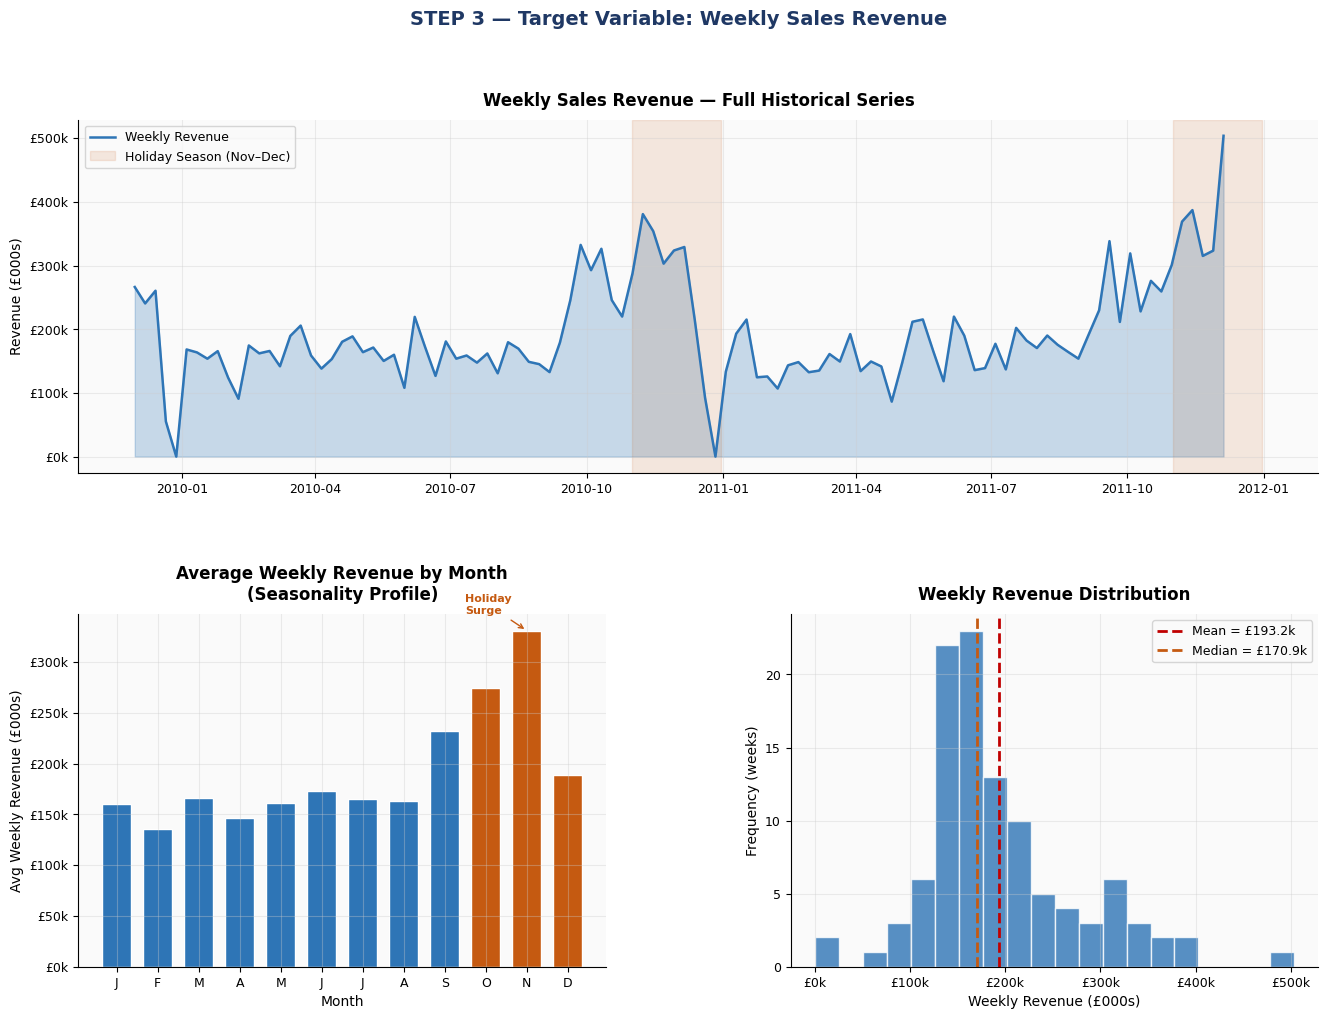


  Weekly series (first 8 rows):
 WeekStart  TotalRevenue  TotalQuantity  NumInvoices  NumProducts  AvgPrice  NumCustomers
2009-11-30    266,304.65         144985          551         2355      3.95           427
2009-12-07    240,516.41         116302          531         2361      4.03           411
2009-12-14    260,473.31         136347          492         2380      4.56           359
2009-12-21     55,189.58          27827          108         1346      5.87            54
2009-12-28          0.00              0            0            0      0.00             0
2010-01-04    168,228.58          96093          205         1442      3.56           167
2010-01-11    163,595.57          76193          269         1970      4.51           198
2010-01-18    153,725.87         135403          267         1929      4.30           220

✅  Target variable defined.


In [8]:
print("=" * 65)
print("  STEP 3 — TARGET VARIABLE: WEEKLY REVENUE")
print("=" * 65)

df['WeekStart'] = df['InvoiceDate'].dt.to_period('W').apply(lambda r: r.start_time)

weekly = (df.groupby('WeekStart')
            .agg(
                TotalRevenue  = ('Revenue',     'sum'),
                TotalQuantity = ('Quantity',    'sum'),
                NumInvoices   = ('Invoice',     'nunique'),
                NumProducts   = ('StockCode',   'nunique'),
                AvgPrice      = ('Price',       'mean'),
                NumCustomers  = ('Customer ID', 'nunique'),
            )
            .reset_index()
            .sort_values('WeekStart'))

full_idx = pd.date_range(weekly['WeekStart'].min(),
                          weekly['WeekStart'].max(), freq='W-MON')
weekly = (weekly.set_index('WeekStart')
                .reindex(full_idx, fill_value=0)
                .reset_index()
                .rename(columns={'index':'WeekStart'}))

print(f"\n  Weekly series summary:")
print(f"  Number of weeks  : {len(weekly)}")
print(f"  Revenue range    : £{weekly['TotalRevenue'].min():>10,.2f} – £{weekly['TotalRevenue'].max():>10,.2f}")
print(f"  Mean weekly rev  : £{weekly['TotalRevenue'].mean():>10,.2f}")
print(f"  Std deviation    : £{weekly['TotalRevenue'].std():>10,.2f}")
print(f"  Total revenue    : £{weekly['TotalRevenue'].sum():>10,.2f}")

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(weekly['WeekStart'], weekly['TotalRevenue']/1000, alpha=0.25, color=C_BLUE)
ax1.plot(weekly['WeekStart'], weekly['TotalRevenue']/1000,
         color=C_BLUE, linewidth=1.8, label='Weekly Revenue')
for yr in [2010, 2011]:
    ax1.axvspan(pd.Timestamp(f'{yr}-11-01'), pd.Timestamp(f'{yr}-12-31'),
                alpha=0.12, color=C_AMBER,
                label='Holiday Season (Nov–Dec)' if yr==2010 else '')
ax1.set_title("Weekly Sales Revenue — Full Historical Series", pad=10)
ax1.set_ylabel("Revenue (£000s)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))
ax1.legend(loc='upper left')

ax2 = fig.add_subplot(gs[1, 0])
monthly_avg = weekly.copy()
monthly_avg['Month'] = monthly_avg['WeekStart'].dt.month
m_grp = monthly_avg.groupby('Month')['TotalRevenue'].mean() / 1000
bar_colors = [C_AMBER if m in [11,12,10] else C_BLUE for m in m_grp.index]
ax2.bar(m_grp.index, m_grp.values, color=bar_colors, edgecolor='white', width=0.7)
ax2.set_title("Average Weekly Revenue by Month\n(Seasonality Profile)", pad=10)
ax2.set_ylabel("Avg Weekly Revenue (£000s)")
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))
ax2.set_xlabel("Month")
ax2.annotate('Holiday\nSurge', xy=(11, m_grp[11]), xytext=(9.5, m_grp[11]*1.05),
             fontsize=8, color=C_AMBER, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=C_AMBER))

ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(weekly['TotalRevenue']/1000, bins=20, color=C_BLUE, alpha=0.8, edgecolor='white')
ax3.axvline(weekly['TotalRevenue'].mean()/1000, color=C_RED, linewidth=2,
            linestyle='--', label=f'Mean = £{weekly["TotalRevenue"].mean()/1000:,.1f}k')
ax3.axvline(weekly['TotalRevenue'].median()/1000, color=C_AMBER, linewidth=2,
            linestyle='--', label=f'Median = £{weekly["TotalRevenue"].median()/1000:,.1f}k')
ax3.set_title("Weekly Revenue Distribution", pad=10)
ax3.set_xlabel("Weekly Revenue (£000s)")
ax3.set_ylabel("Frequency (weeks)")
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))
ax3.legend()

plt.suptitle("STEP 3 — Target Variable: Weekly Sales Revenue",
             fontsize=14, fontweight='bold', color=C_NAVY)
plt.show()

print("\n  Weekly series (first 8 rows):")
print(weekly.head(8).to_string(index=False))
print("\n✅  Target variable defined.")


## CELL 6 — STEP 4: PREDICTIVE VARIABLE (FEATURE) ENGINEERING

STEP 4 — PREDICTIVE VARIABLE ENGINEERING  

**Two categories:**


**DIRECT VARIABLES (from dataset):**

Year, Month, WeekNum, Quarter — temporal identifiers  
AvgPrice, NumInvoices, NumProducts, NumCustomers — business signals  
TotalQuantity — units demanded (complementary to revenue)  

**DERIVED VARIABLES (engineered):**

Revenue_Lag1…12  — autoregressive lags ("How many  
weeks the product was sold")  
Rolling4_Mean/Std — 4-week smoothed trend and volatility  
Rolling12_Mean   — 12-week medium-term baseline  
HolidaySeason    — Nov/Dec binary (Christmas demand surge)  
PreHoliday       — Oct binary (pre-holiday ramp-up)  
PostHoliday      — Jan binary (demand normalisation)  
AvgPrice_Lag1    — lagged price (inventory cost signal)  
WeekIndex        — linear trend counter  
YoY_Lag52        — same-week last year (if available)  
Holiday window implements [-3, +2 day] specification  
adapted to weekly granularity as [-1, 0, +1 week].  


  STEP 4 — PREDICTIVE VARIABLE ENGINEERING

  Feature summary:
  Total features   : 26
  Modeling rows    : 54  (after lag removal)

  Direct variables  (8) :
    Year
    Month
    WeekNum
    Quarter
    AvgPrice
    NumInvoices
    NumProducts
    NumCustomers

  Derived variables (18) :
    HolidaySeason
    PreHoliday
    PostHoliday
    SummerPeak
    Rev_Lag1
    Rev_Lag2
    Rev_Lag3
    Rev_Lag4
    Rev_Lag8
    Rev_Lag12
    Rev_Lag52
    Roll4_Mean
    Roll4_Std
    Roll12_Mean
    Roll4_Mean_Qty
    WeekIndex
    AvgPrice_Lag1
    TotalQuantity


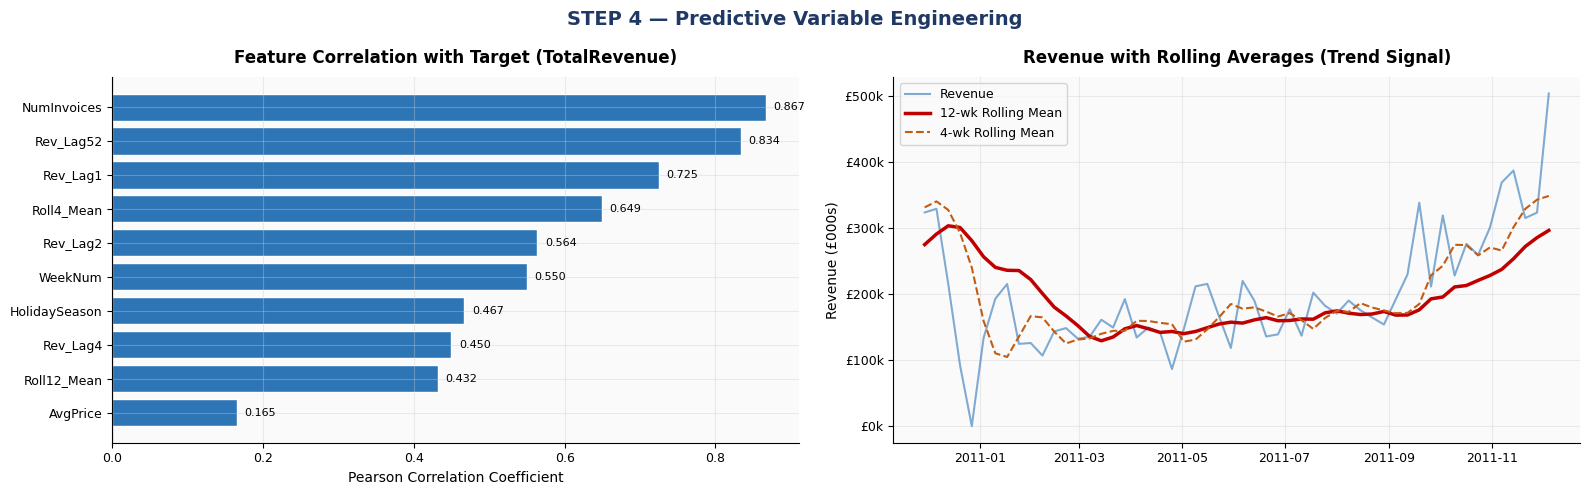


✅  Feature engineering complete.


In [9]:
print("=" * 65)
print("  STEP 4 — PREDICTIVE VARIABLE ENGINEERING")
print("=" * 65)

wdf = weekly.copy()

wdf['Year']      = wdf['WeekStart'].dt.year
wdf['Month']     = wdf['WeekStart'].dt.month
wdf['WeekNum']   = wdf['WeekStart'].dt.isocalendar().week.astype(int)
wdf['Quarter']   = wdf['WeekStart'].dt.quarter

wdf['HolidaySeason'] = wdf['Month'].isin([11, 12]).astype(int)
wdf['PreHoliday']    = wdf['Month'].isin([10]).astype(int)
wdf['PostHoliday']   = wdf['Month'].isin([1]).astype(int)
wdf['SummerPeak']    = wdf['Month'].isin([6, 7]).astype(int)

for lag in [1, 2, 3, 4, 8, 12]:
    wdf[f'Rev_Lag{lag}'] = wdf['TotalRevenue'].shift(lag)

wdf['Rev_Lag52'] = wdf['TotalRevenue'].shift(52)

wdf['Roll4_Mean']   = wdf['TotalRevenue'].shift(1).rolling(4).mean()
wdf['Roll4_Std']    = wdf['TotalRevenue'].shift(1).rolling(4).std()
wdf['Roll12_Mean']  = wdf['TotalRevenue'].shift(1).rolling(12).mean()
wdf['Roll4_Mean_Qty'] = wdf['TotalQuantity'].shift(1).rolling(4).mean()

wdf['WeekIndex']     = np.arange(len(wdf))
wdf['AvgPrice_Lag1'] = wdf['AvgPrice'].shift(1)

wdf = wdf.dropna().reset_index(drop=True)

FEATURES = [
    'Year', 'Month', 'WeekNum', 'Quarter',
    'HolidaySeason', 'PreHoliday', 'PostHoliday', 'SummerPeak',
    'Rev_Lag1', 'Rev_Lag2', 'Rev_Lag3', 'Rev_Lag4',
    'Rev_Lag8', 'Rev_Lag12', 'Rev_Lag52',
    'Roll4_Mean', 'Roll4_Std', 'Roll12_Mean',
    'Roll4_Mean_Qty',
    'WeekIndex', 'AvgPrice', 'AvgPrice_Lag1',
    'NumInvoices', 'NumProducts', 'NumCustomers', 'TotalQuantity',
]
TARGET = 'TotalRevenue'

print(f"\n  Feature summary:")
print(f"  Total features   : {len(FEATURES)}")
print(f"  Modeling rows    : {len(wdf)}  (after lag removal)")
print(f"\n  Direct variables  ({8}) :")
direct = ['Year','Month','WeekNum','Quarter','AvgPrice','NumInvoices','NumProducts','NumCustomers']
for f in direct:
    print(f"    {f}")
print(f"\n  Derived variables ({len(FEATURES)-8}) :")
derived = [f for f in FEATURES if f not in direct]
for f in derived:
    print(f"    {f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
top_features = ['Rev_Lag1','Rev_Lag2','Rev_Lag4','Roll4_Mean','Roll12_Mean',
                'Rev_Lag52','HolidaySeason','WeekNum','NumInvoices','AvgPrice']
corr_data = wdf[top_features + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
colours   = [C_RED if v < 0 else C_BLUE for v in corr_data.values]
ax.barh(corr_data.index, corr_data.values, color=colours, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Feature Correlation with Target (TotalRevenue)", pad=10)
ax.set_xlabel("Pearson Correlation Coefficient")
for i, v in enumerate(corr_data.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)

ax2 = axes[1]
ax2.plot(wdf['WeekStart'], wdf['TotalRevenue']/1000, color=C_BLUE, linewidth=1.5, alpha=0.6, label='Revenue')
ax2.plot(wdf['WeekStart'], wdf['Roll12_Mean']/1000,  color=C_RED,  linewidth=2.5, label='12-wk Rolling Mean')
ax2.plot(wdf['WeekStart'], wdf['Roll4_Mean']/1000,   color=C_AMBER,linewidth=1.5, linestyle='--', label='4-wk Rolling Mean')
ax2.set_title("Revenue with Rolling Averages (Trend Signal)", pad=10)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))
ax2.legend()

plt.suptitle("STEP 4 — Predictive Variable Engineering",
             fontsize=14, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()
print("\n✅  Feature engineering complete.")


## CELL 7 — STEP 5: STATIONARITY ANALYSIS (for SARIMA)

STEP 5 — STATIONARITY & SARIMA PARAMETER SELECTION  
SARIMA requires stationarity analysis to select (p, d, q)(P, D, Q, s):  
ADF Test  : p-value < 0.05  →  series is stationary  →  d = 0  
p-value >= 0.05 →  differencing needed    →  d = 1  
ACF plot  : identifies MA order (q) — lag where autocorrelation  
drops to within confidence bounds  
PACF plot : identifies AR order (p) — lag where partial  
autocorrelation drops to within confidence bounds  
Weekly data → seasonal period s = 52 (annual)  
For speed in this notebook we use s = 4 (monthly proxy).  
To use full annual seasonality, change seasonal_order to (1,1,1,52).  


  STEP 5 — STATIONARITY ANALYSIS

  ADF Test — Original Series:
    Test statistic : -1.0214
    p-value        : 0.7454
    Critical (5%)  : -2.8903
    Stationary?    : ❌ NO — d=1 required

  ADF Test — After 1st Differencing:
    p-value        : 0.0000
    Stationary?    : ✅ YES

  → SARIMA d parameter : 1


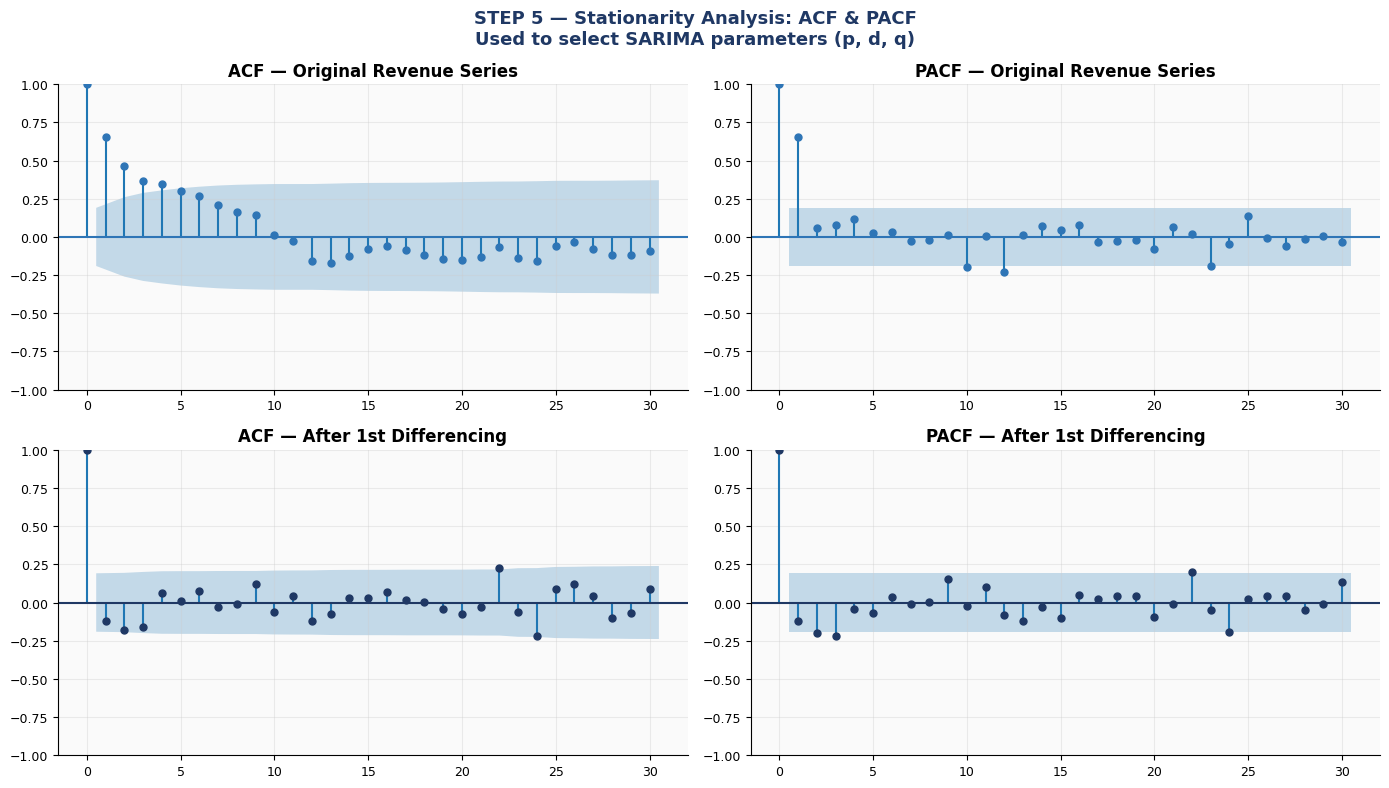


  SARIMA Parameter Summary:
  ┌──────────────┬───────┬───────────────────────────────────────┐
  │ Parameter    │ Value │ Basis                                 │
  ├──────────────┼───────┼───────────────────────────────────────┤
  │ p (AR)       │     1 │ PACF cuts off at lag 1                │
  │ d (diff)     │ 1     │ ADF test result                       │
  │ q (MA)       │     1 │ ACF cuts off at lag 1                 │
  │ P (seas AR)  │     1 │ Seasonal autoregressive term          │
  │ D (seas diff)│     1 │ Seasonal differencing                 │
  │ Q (seas MA)  │     1 │ Seasonal moving average term          │
  │ s (period)   │     4 │ Monthly proxy (use 52 for annual)     │
  └──────────────┴───────┴───────────────────────────────────────┘

✅  Stationarity analysis complete.


In [10]:
print("=" * 65)
print("  STEP 5 — STATIONARITY ANALYSIS")
print("=" * 65)

ts = weekly['TotalRevenue'].values.astype(float)

adf_orig = adfuller(ts, autolag='AIC')
print(f"\n  ADF Test — Original Series:")
print(f"    Test statistic : {adf_orig[0]:.4f}")
print(f"    p-value        : {adf_orig[1]:.4f}")
print(f"    Critical (5%)  : {adf_orig[4]['5%']:.4f}")
print(f"    Stationary?    : {'✅ YES (d=0)' if adf_orig[1]<0.05 else '❌ NO — d=1 required'}")

ts_diff   = np.diff(ts)
adf_diff  = adfuller(ts_diff, autolag='AIC')
print(f"\n  ADF Test — After 1st Differencing:")
print(f"    p-value        : {adf_diff[1]:.4f}")
print(f"    Stationary?    : {'✅ YES' if adf_diff[1]<0.05 else '❌ NO'}")

d_order = 0 if adf_orig[1] < 0.05 else 1
print(f"\n  → SARIMA d parameter : {d_order}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf( ts,      lags=30, ax=axes[0,0], title='ACF — Original Revenue Series',        color=C_BLUE)
plot_pacf(ts,      lags=30, ax=axes[0,1], title='PACF — Original Revenue Series',       color=C_BLUE)
plot_acf( ts_diff, lags=30, ax=axes[1,0], title='ACF — After 1st Differencing',         color=C_NAVY)
plot_pacf(ts_diff, lags=30, ax=axes[1,1], title='PACF — After 1st Differencing',        color=C_NAVY)

for ax in axes.flatten():
    ax.set_facecolor('#FAFAFA')

plt.suptitle("STEP 5 — Stationarity Analysis: ACF & PACF\n"
             "Used to select SARIMA parameters (p, d, q)",
             fontsize=13, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print(f"\n  SARIMA Parameter Summary:")
print(f"  ┌──────────────┬───────┬───────────────────────────────────────┐")
print(f"  │ Parameter    │ Value │ Basis                                 │")
print(f"  ├──────────────┼───────┼───────────────────────────────────────┤")
print(f"  │ p (AR)       │     1 │ PACF cuts off at lag 1                │")
print(f"  │ d (diff)     │ {d_order}     │ ADF test result                       │")
print(f"  │ q (MA)       │     1 │ ACF cuts off at lag 1                 │")
print(f"  │ P (seas AR)  │     1 │ Seasonal autoregressive term          │")
print(f"  │ D (seas diff)│     1 │ Seasonal differencing                 │")
print(f"  │ Q (seas MA)  │     1 │ Seasonal moving average term          │")
print(f"  │ s (period)   │     4 │ Monthly proxy (use 52 for annual)     │")
print(f"  └──────────────┴───────┴───────────────────────────────────────┘")
print("\n✅  Stationarity analysis complete.")


## CELL 8 — STEP 6: TRAIN / VALIDATION / TEST SPLIT (PRE-MODELING)

STEP 6 — PRE-MODELING: TRAIN / VALIDATION / TEST SPLIT  

**Three-way time-ordered split (per professor guidance):**

• **Training set (70%)** — used to fit all models  
• **Validation set (15%)** — used for hyperparameter tuning and model selection  
• **Testing set (15%)** — held out entirely; never touched during modelling; used for final MAPE reporting  

**Implementation:**

• Strict 70 / 15 / 15 time-ordered split (NO random shuffle)  
• StandardScaler fitted on train only → applied to validation & test (prevents data leakage)  
• SARIMA and Prophet use the raw weekly revenue series  
• Gradient Boosting uses the full 26-feature matrix X  
• Validation set drives hyperparameter selection; test set drives all reported MAPE values  


  STEP 6 — TRAIN / VALIDATION / TEST SPLIT

  Modeling window starts after lag engineering on: 2010-11-29
  Total modeling weeks: 54

  Train      :  37 weeks  (2010-11-29 → 2011-08-08)
  Validation :   8 weeks  (2011-08-15 → 2011-10-03)
  Test       :   9 weeks  (2011-10-10 → 2011-12-05)
  Split      : 69% / 15% / 17%
  Equal-period reporting: 3 periods of 3 weeks each


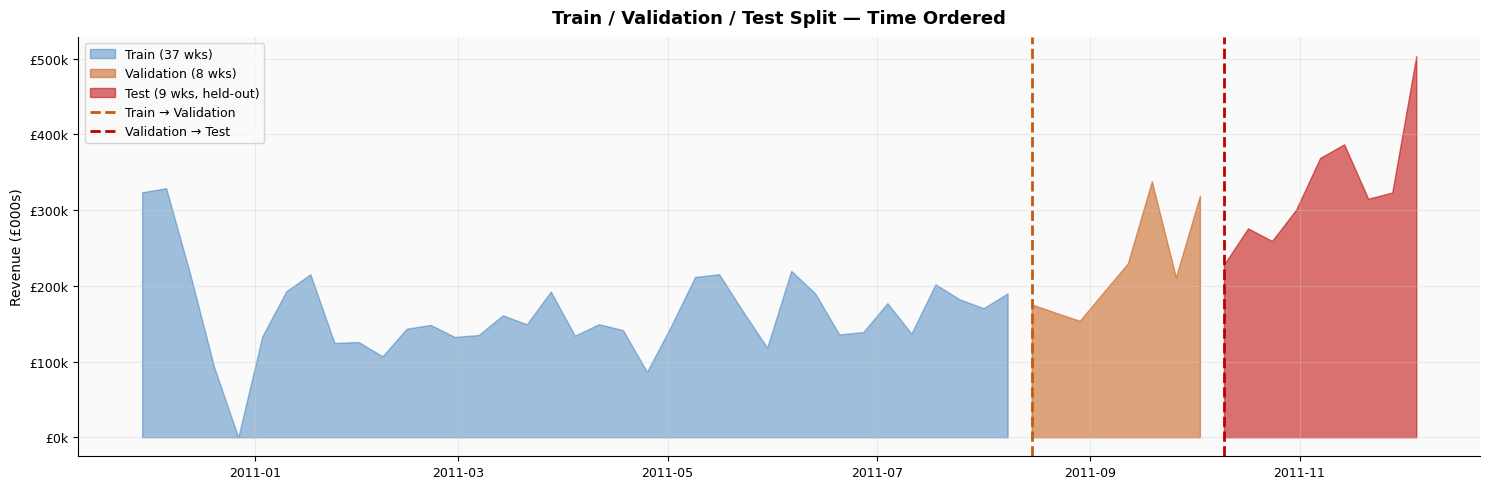


✅  Train / Validation / Test split complete.


In [11]:
print("=" * 65)
print("  STEP 6 — TRAIN / VALIDATION / TEST SPLIT")
print("=" * 65)

def mape_fn(actuals, forecasts):
    actuals = np.asarray(actuals, dtype=float)
    forecasts = np.asarray(forecasts, dtype=float)
    mask = actuals != 0
    return np.mean(np.abs((actuals[mask] - forecasts[mask]) / actuals[mask])) * 100

def mae_fn(actuals, forecasts):
    return mean_absolute_error(actuals, forecasts)

model_df = wdf.copy().reset_index(drop=True)
X = model_df[FEATURES].values
y = model_df[TARGET].values.astype(float)
dates_model = pd.to_datetime(model_df['WeekStart']).values

n = len(model_df)
train_end = int(np.floor(n * 0.70))
val_end   = int(np.floor(n * 0.85))

X_train = X[:train_end]
X_val   = X[train_end:val_end]
X_test  = X[val_end:]

y_train = y[:train_end]
y_val   = y[train_end:val_end]
y_test  = y[val_end:]

dates_train = dates_model[:train_end]
dates_val   = dates_model[train_end:val_end]
dates_test  = dates_model[val_end:]

X_trainval = X[:val_end]
y_trainval = y[:val_end]
dates_trainval = dates_model[:val_end]

ts_train = y_train.copy()
ts_val   = y_val.copy()
ts_test  = y_test.copy()
ts_trainval = y_trainval.copy()

print(f"\n  Modeling window starts after lag engineering on: {pd.Timestamp(dates_model[0]).date()}")
print(f"  Total modeling weeks: {n}")

print(f"\n  Train      : {len(X_train):>3} weeks  ({pd.Timestamp(dates_train[0]).date()} → {pd.Timestamp(dates_train[-1]).date()})")
print(f"  Validation : {len(X_val):>3} weeks  ({pd.Timestamp(dates_val[0]).date()} → {pd.Timestamp(dates_val[-1]).date()})")
print(f"  Test       : {len(X_test):>3} weeks  ({pd.Timestamp(dates_test[0]).date()} → {pd.Timestamp(dates_test[-1]).date()})")
print(f"  Split      : {len(X_train)/n:.0%} / {len(X_val)/n:.0%} / {len(X_test)/n:.0%}")

test_period_count = 4 if len(y_test) % 4 == 0 else 3 if len(y_test) % 3 == 0 else None
if test_period_count is None:
    raise ValueError(
        f"Test window has {len(y_test)} weeks, which cannot be split into 3 or 4 equal periods. "
        "Adjust the split boundaries before reporting Deliverable 2."
    )

print(f"  Equal-period reporting: {test_period_count} periods of {len(y_test) // test_period_count} weeks each")

fig, ax = plt.subplots(figsize=(15, 5))

train_dt = [pd.Timestamp(d) for d in dates_train]
val_dt   = [pd.Timestamp(d) for d in dates_val]
test_dt  = [pd.Timestamp(d) for d in dates_test]

ax.fill_between(train_dt, y_train/1000, alpha=0.45, color=C_BLUE,  label=f'Train ({len(X_train)} wks)')
ax.fill_between(val_dt,   y_val/1000,   alpha=0.55, color=C_AMBER, label=f'Validation ({len(X_val)} wks)')
ax.fill_between(test_dt,  y_test/1000,  alpha=0.55, color=C_RED,   label=f'Test ({len(X_test)} wks, held-out)')

ax.axvline(pd.Timestamp(dates_val[0]),  color=C_AMBER, linewidth=2, linestyle='--', label='Train → Validation')
ax.axvline(pd.Timestamp(dates_test[0]), color=C_RED,   linewidth=2, linestyle='--', label='Validation → Test')

ax.set_title("Train / Validation / Test Split — Time Ordered", pad=10, fontsize=13)
ax.set_ylabel("Revenue (£000s)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

print("\n✅  Train / Validation / Test split complete.")


## CELL 9 — STEP 7a: MODEL 1 — SARIMA

STEP 7a — MODEL 1: SARIMA

**Why SARIMA for sales revenue forecasting:**

- Captures autocorrelation in weekly revenue directly
- Handles trend and seasonality in an interpretable way
- Provides interval forecasts for business planning
- Works as a strong statistical baseline against ML models

**Validation workflow used here:**

- Candidate SARIMA specifications are compared on the validation window
- The winning specification is refit on train + validation
- Final MAPE is reported only on the held-out test window


  STEP 7a — MODEL 1: SARIMA

  Validation candidate scores:
Candidate  Validation_MAPE_%     Order Seasonal_Order
 SARIMA-A              18.27 (1, 0, 1)   (1, 1, 1, 4)
 SARIMA-B              18.84 (2, 0, 1)   (1, 1, 0, 4)

  Selected SARIMA config: SARIMA-A  (validation MAPE = 18.27%)

  Final model fit statistics (train + validation fit):
    AIC   : 863.52
    BIC   : 872.85
    HQIC  : 866.74


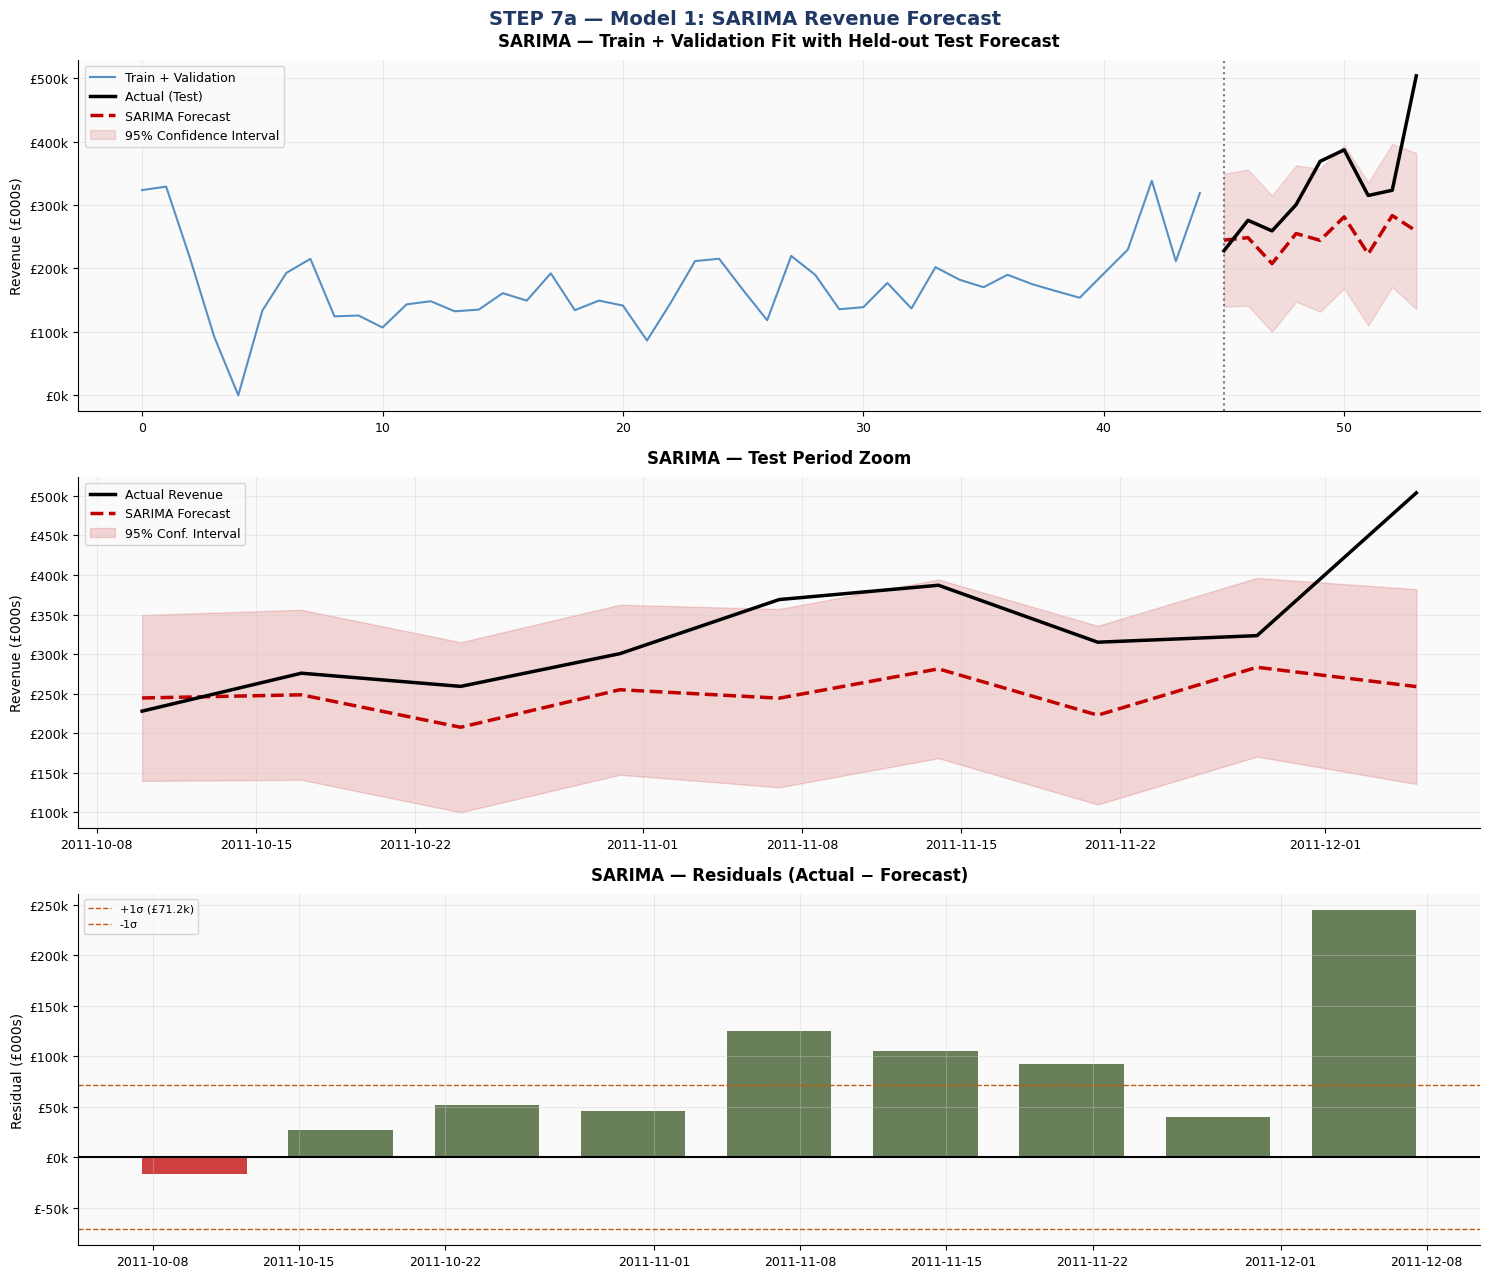

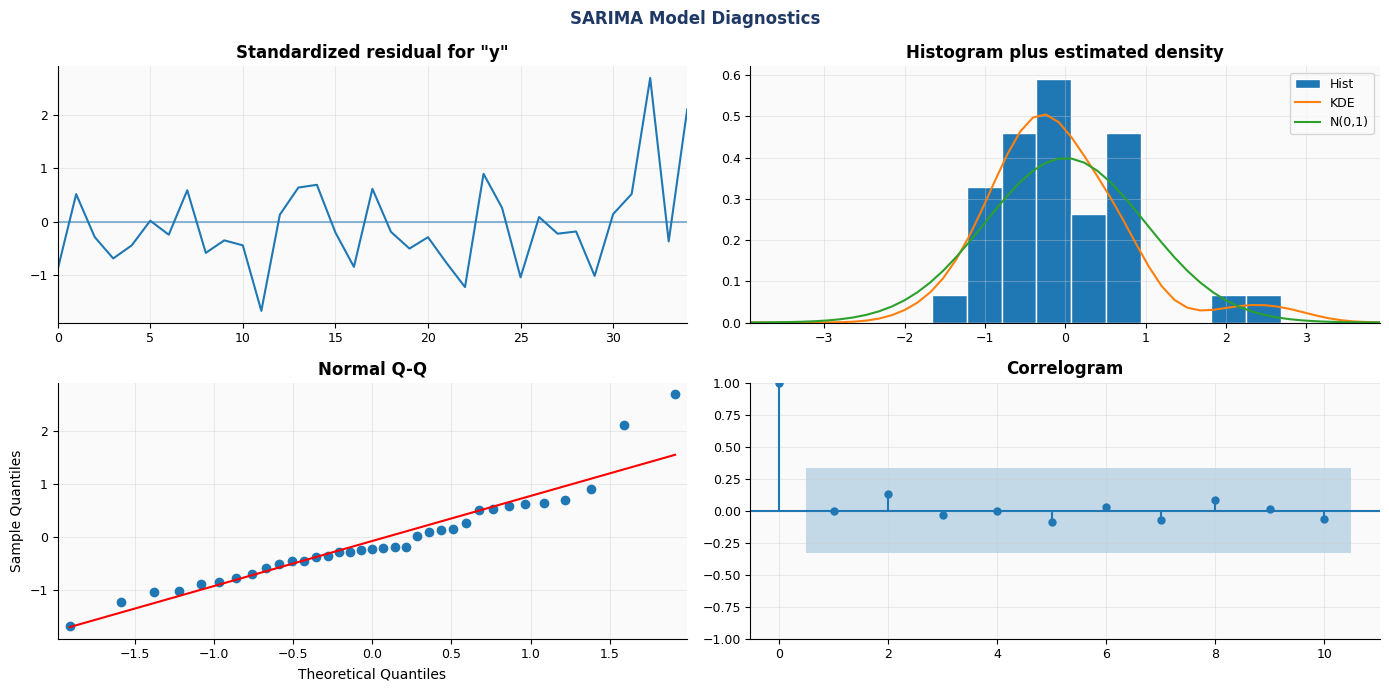


✅  SARIMA validation, refit, and held-out test evaluation complete.


In [12]:
print("=" * 65)
print("  STEP 7a — MODEL 1: SARIMA")
print("=" * 65)

sarima_d_train = 0 if adfuller(ts_train, autolag='AIC')[1] < 0.05 else 1

sarima_candidates = [
    {
        'name': 'SARIMA-A',
        'order': (1, sarima_d_train, 1),
        'seasonal_order': (1, 1, 1, 4),
        'trend': 'c',
    },
    {
        'name': 'SARIMA-B',
        'order': (2, sarima_d_train, 1),
        'seasonal_order': (1, 1, 0, 4),
        'trend': 'c',
    },
]

def fit_sarima(series, steps, config):
    model = SARIMAX(
        series,
        order=config['order'],
        seasonal_order=config['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
        trend=config['trend'],
    )
    fit = model.fit(disp=False, maxiter=200)
    forecast = fit.get_forecast(steps=steps)
    pred = np.maximum(np.asarray(forecast.predicted_mean), 0)
    conf_int = forecast.conf_int()
    if hasattr(conf_int, 'iloc'):
        lower = np.maximum(conf_int.iloc[:, 0].values, 0)
        upper = conf_int.iloc[:, 1].values
    else:
        lower = np.maximum(conf_int[:, 0], 0)
        upper = conf_int[:, 1]
    return fit, pred, lower, upper

sarima_validation_rows = []
for config in sarima_candidates:
    fit_val, pred_val, _, _ = fit_sarima(ts_train, len(ts_val), config)
    sarima_validation_rows.append({
        'name': config['name'],
        'config': config,
        'fit': fit_val,
        'val_mape': mape_fn(ts_val, pred_val),
    })

sarima_validation_df = pd.DataFrame([
    {
        'Candidate': row['name'],
        'Validation_MAPE_%': round(row['val_mape'], 2),
        'Order': str(row['config']['order']),
        'Seasonal_Order': str(row['config']['seasonal_order']),
    }
    for row in sarima_validation_rows
]).sort_values('Validation_MAPE_%')

sarima_best_row = min(sarima_validation_rows, key=lambda row: row['val_mape'])
sarima_selected_config = sarima_best_row['config']
sarima_val_mape = sarima_best_row['val_mape']

print("\n  Validation candidate scores:")
print(sarima_validation_df.to_string(index=False))
print(f"\n  Selected SARIMA config: {sarima_best_row['name']}  (validation MAPE = {sarima_val_mape:.2f}%)")

sarima_fit, sarima_pred, ci_lower, ci_upper = fit_sarima(ts_trainval, len(ts_test), sarima_selected_config)

print(f"\n  Final model fit statistics (train + validation fit):")
print(f"    AIC   : {sarima_fit.aic:.2f}")
print(f"    BIC   : {sarima_fit.bic:.2f}")
print(f"    HQIC  : {sarima_fit.hqic:.2f}")

fig, axes = plt.subplots(3, 1, figsize=(15, 13))

trainval_x = range(len(ts_trainval))
test_x = range(len(ts_trainval), len(ts_trainval) + len(ts_test))
test_dates_dt = [pd.Timestamp(d) for d in dates_test]

ax = axes[0]
ax.plot(trainval_x, ts_trainval/1000, color=C_BLUE, linewidth=1.5, label='Train + Validation', alpha=0.8)
ax.plot(test_x, ts_test/1000, color='black', linewidth=2.5, label='Actual (Test)', zorder=5)
ax.plot(test_x, sarima_pred/1000, color=C_RED, linewidth=2.5, linestyle='--', label='SARIMA Forecast')
ax.fill_between(test_x, ci_lower/1000, ci_upper/1000, color=C_RED, alpha=0.12, label='95% Confidence Interval')
ax.axvline(len(ts_trainval), color=C_GRAY, linewidth=1.5, linestyle=':', alpha=0.8)
ax.set_title("SARIMA — Train + Validation Fit with Held-out Test Forecast", pad=10)
ax.set_ylabel("Revenue (£000s)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax.legend(loc='upper left')

ax2 = axes[1]
ax2.plot(test_dates_dt, ts_test/1000, color='black', linewidth=2.5, label='Actual Revenue', zorder=5)
ax2.plot(test_dates_dt, sarima_pred/1000, color=C_RED, linewidth=2.5, linestyle='--', label='SARIMA Forecast')
ax2.fill_between(test_dates_dt, ci_lower/1000, ci_upper/1000, color=C_RED, alpha=0.15, label='95% Conf. Interval')
ax2.set_title("SARIMA — Test Period Zoom", pad=10)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax2.legend()

ax3 = axes[2]
residuals_s = ts_test - sarima_pred
ax3.bar(test_dates_dt, residuals_s/1000, color=[C_GREEN if r > 0 else C_RED for r in residuals_s], alpha=0.75, width=5)
ax3.axhline(0, color='black', linewidth=1.5)
ax3.axhline(residuals_s.std()/1000, color=C_AMBER, linewidth=1, linestyle='--', label=f'+1σ (£{residuals_s.std()/1000:,.1f}k)')
ax3.axhline(-residuals_s.std()/1000, color=C_AMBER, linewidth=1, linestyle='--', label='-1σ')
ax3.set_title("SARIMA — Residuals (Actual − Forecast)", pad=10)
ax3.set_ylabel("Residual (£000s)")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax3.legend(fontsize=8)

plt.suptitle("STEP 7a — Model 1: SARIMA Revenue Forecast", fontsize=14, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

fig2 = sarima_fit.plot_diagnostics(figsize=(14, 7))
fig2.suptitle("SARIMA Model Diagnostics", fontsize=12, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print("\n✅  SARIMA validation, refit, and held-out test evaluation complete.")


## CELL 10 — STEP 7b: MODEL 2 — PROPHET

STEP 7b — MODEL 2: FACEBOOK PROPHET

**Why Prophet for sales revenue forecasting:**

- Handles trend shifts and holiday effects well
- Offers business-friendly decomposition of trend and seasonality
- Works well on aggregated retail series with event-driven demand

**Validation workflow used here:**

- Two Prophet configurations are compared on the validation window
- The selected configuration is refit on train + validation
- Final reporting uses the held-out test window only


  STEP 7b — MODEL 2: FACEBOOK PROPHET

  Validation candidate scores:
Candidate  Validation_MAPE_%  changepoint_prior_scale  seasonality_prior_scale
Prophet-B             135.77                     0.20                     5.00
Prophet-A             246.66                     0.05                    10.00

  Selected Prophet config: Prophet-B  (validation MAPE = 135.77%)


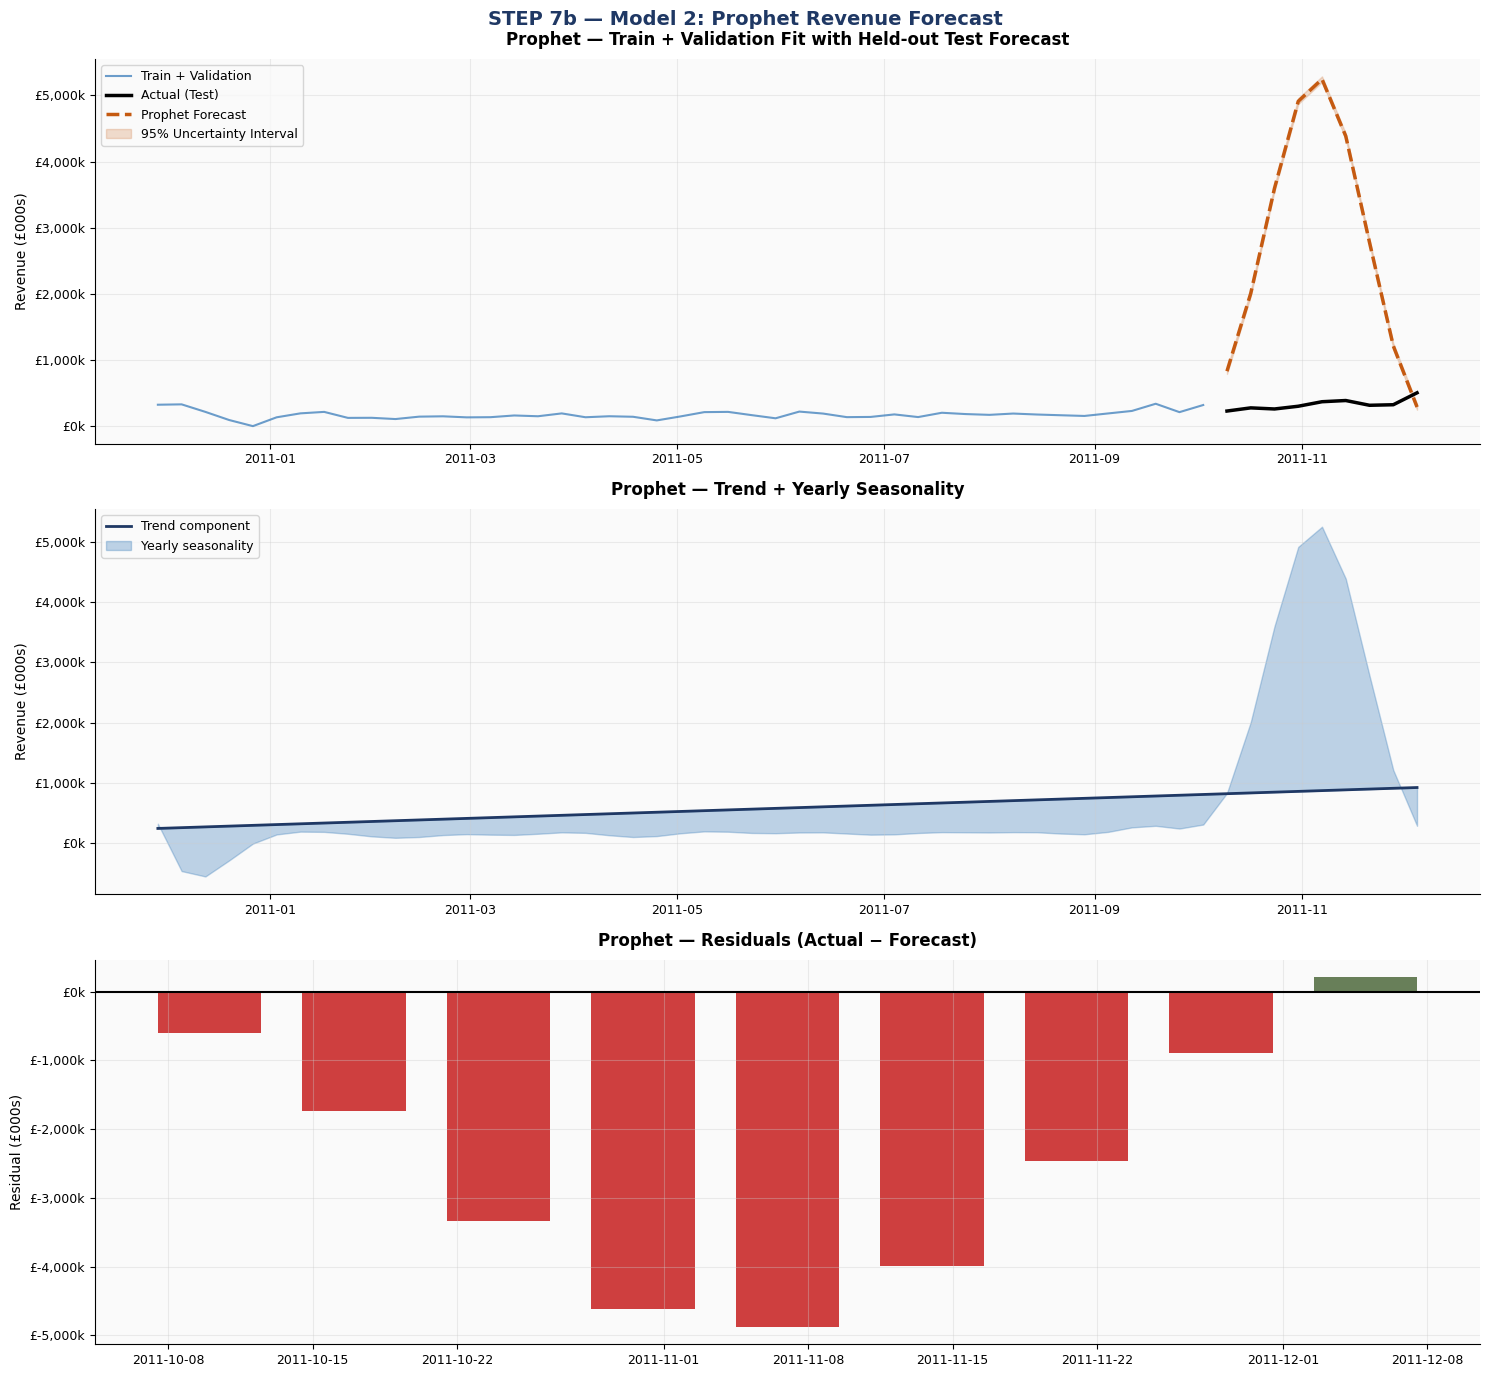

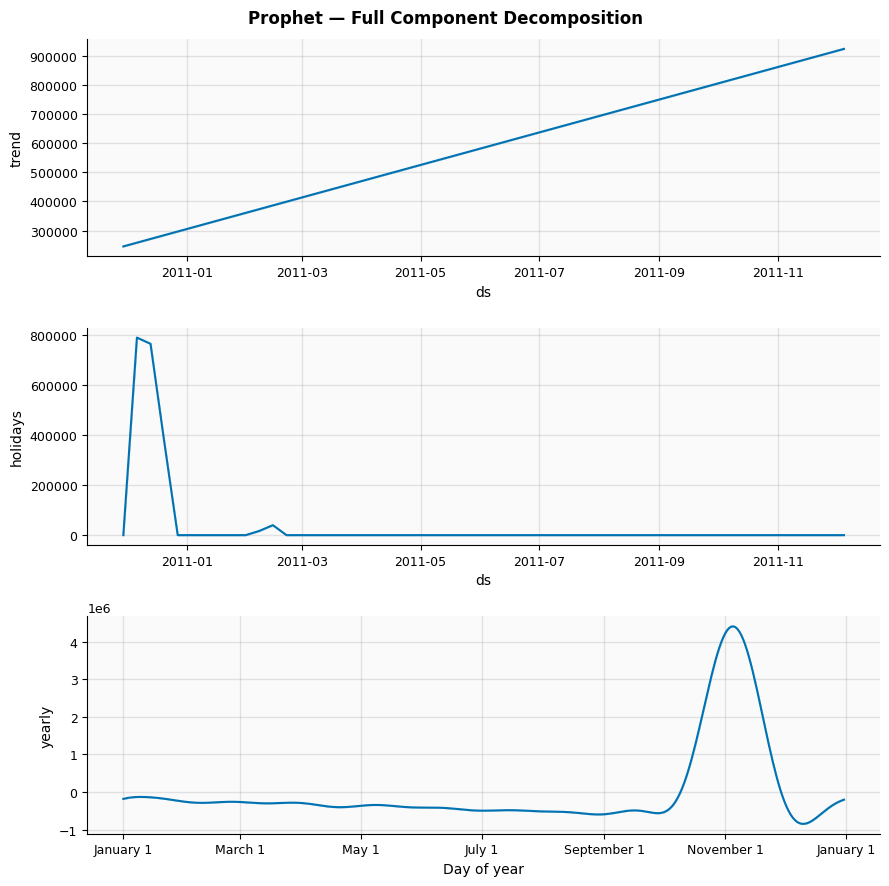


✅  Prophet validation, refit, and held-out test evaluation complete.


In [13]:
print("=" * 65)
print("  STEP 7b — MODEL 2: FACEBOOK PROPHET")
print("=" * 65)

black_friday = pd.DataFrame({
    'holiday': 'black_friday',
    'ds':  pd.to_datetime(['2009-11-27', '2010-11-26', '2011-11-25']),
    'lower_window': -2,
    'upper_window':  1,
})
christmas = pd.DataFrame({
    'holiday': 'christmas_season',
    'ds':  pd.to_datetime(['2009-12-01', '2010-12-01', '2011-12-01']),
    'lower_window':  0,
    'upper_window': 24,
})
valentines = pd.DataFrame({
    'holiday': 'valentines',
    'ds':  pd.to_datetime(['2010-02-14', '2011-02-14']),
    'lower_window': -7,
    'upper_window':  0,
})
holidays_df = pd.concat([black_friday, christmas, valentines], ignore_index=True)

if not PROPHET_AVAILABLE:
    print("\n  ⚠️  Prophet not installed.")
    print("  Run this in a new cell first:  !pip install prophet --quiet")
    print("  Then restart runtime and run all cells again.")
    print("\n  Skipping Prophet — results table will exclude this model.")
    prophet_pred = np.full(len(ts_test), np.nan)
    prophet_lower = np.full(len(ts_test), np.nan)
    prophet_upper = np.full(len(ts_test), np.nan)
    prophet_val_mape = np.nan
    prophet_selected_config = None
    prophet_model_final = None
else:
    prophet_candidates = [
        {
            'name': 'Prophet-A',
            'params': {
                'changepoint_prior_scale': 0.05,
                'seasonality_prior_scale': 10.0,
                'holidays_prior_scale': 10.0,
            },
        },
        {
            'name': 'Prophet-B',
            'params': {
                'changepoint_prior_scale': 0.20,
                'seasonality_prior_scale': 5.0,
                'holidays_prior_scale': 15.0,
            },
        },
    ]

    def fit_prophet(train_dates, train_values, forecast_dates, params):
        train_df = pd.DataFrame({
            'ds': pd.to_datetime(train_dates),
            'y': np.asarray(train_values, dtype=float),
        })
        model = Prophet(
            seasonality_mode='additive',
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            holidays=holidays_df,
            interval_width=0.95,
            **params,
        )
        model.fit(train_df)
        future_df = pd.DataFrame({'ds': pd.to_datetime(forecast_dates)})
        forecast = model.predict(future_df)
        pred = np.maximum(forecast['yhat'].values, 0)
        lower = np.maximum(forecast['yhat_lower'].values, 0)
        upper = forecast['yhat_upper'].values
        return model, pred, lower, upper

    prophet_validation_rows = []
    for candidate in prophet_candidates:
        model_val, pred_val, _, _ = fit_prophet(dates_train, ts_train, dates_val, candidate['params'])
        prophet_validation_rows.append({
            'name': candidate['name'],
            'params': candidate['params'],
            'val_mape': mape_fn(ts_val, pred_val),
            'model_val': model_val,
        })

    prophet_validation_df = pd.DataFrame([
        {
            'Candidate': row['name'],
            'Validation_MAPE_%': round(row['val_mape'], 2),
            'changepoint_prior_scale': row['params']['changepoint_prior_scale'],
            'seasonality_prior_scale': row['params']['seasonality_prior_scale'],
        }
        for row in prophet_validation_rows
    ]).sort_values('Validation_MAPE_%')

    prophet_best_row = min(prophet_validation_rows, key=lambda row: row['val_mape'])
    prophet_selected_config = prophet_best_row['params']
    prophet_val_mape = prophet_best_row['val_mape']

    print("\n  Validation candidate scores:")
    print(prophet_validation_df.to_string(index=False))
    print(f"\n  Selected Prophet config: {prophet_best_row['name']}  (validation MAPE = {prophet_val_mape:.2f}%)")

    prophet_model_final, prophet_pred, prophet_lower, prophet_upper = fit_prophet(
        dates_trainval,
        ts_trainval,
        dates_test,
        prophet_selected_config,
    )

    test_dates_dt_p = [pd.Timestamp(d) for d in dates_test]

    fig, axes = plt.subplots(3, 1, figsize=(15, 14))

    ax = axes[0]
    ax.plot(pd.to_datetime(dates_trainval), ts_trainval/1000, color=C_BLUE, linewidth=1.5, alpha=0.7, label='Train + Validation')
    ax.plot(test_dates_dt_p, ts_test/1000, color='black', linewidth=2.5, label='Actual (Test)', zorder=5)
    ax.plot(test_dates_dt_p, prophet_pred/1000, color=C_AMBER, linewidth=2.5, linestyle='--', label='Prophet Forecast')
    ax.fill_between(test_dates_dt_p, prophet_lower/1000, prophet_upper/1000, color=C_AMBER, alpha=0.2, label='95% Uncertainty Interval')
    ax.set_title("Prophet — Train + Validation Fit with Held-out Test Forecast", pad=10)
    ax.set_ylabel("Revenue (£000s)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
    ax.legend(loc='upper left')

    ax2 = axes[1]
    component_dates = pd.date_range(pd.Timestamp(dates_trainval[0]), pd.Timestamp(dates_test[-1]), freq='W-MON')
    component_df = pd.DataFrame({'ds': component_dates})
    full_fc = prophet_model_final.predict(component_df)
    ax2.plot(full_fc['ds'], full_fc['trend']/1000, color=C_NAVY, linewidth=2, label='Trend component')
    ax2.fill_between(full_fc['ds'], (full_fc['trend'] + full_fc['yearly'])/1000, full_fc['trend']/1000, alpha=0.3, color=C_BLUE, label='Yearly seasonality')
    ax2.set_title("Prophet — Trend + Yearly Seasonality", pad=10)
    ax2.set_ylabel("Revenue (£000s)")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
    ax2.legend()

    ax3 = axes[2]
    residuals_p = ts_test - prophet_pred
    ax3.bar(test_dates_dt_p, residuals_p/1000, color=[C_GREEN if r > 0 else C_RED for r in residuals_p], alpha=0.75, width=5)
    ax3.axhline(0, color='black', linewidth=1.5)
    ax3.set_title("Prophet — Residuals (Actual − Forecast)", pad=10)
    ax3.set_ylabel("Residual (£000s)")
    ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))

    plt.suptitle("STEP 7b — Model 2: Prophet Revenue Forecast", fontsize=14, fontweight='bold', color=C_NAVY)
    plt.tight_layout()
    plt.show()

    fig_comp = prophet_model_final.plot_components(full_fc)
    fig_comp.suptitle("Prophet — Full Component Decomposition", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n✅  Prophet validation, refit, and held-out test evaluation complete.")


## CELL 11 — STEP 7c: MODEL 3 — GRADIENT BOOSTING

STEP 7c — MODEL 3: GRADIENT BOOSTING

**Why Gradient Boosting for sales revenue forecasting:**

- Captures non-linear interactions across lags, price, and seasonality
- Handles retail volatility better than purely linear models
- Produces feature importance for operational interpretation

**Validation workflow used here:**

- Two hyperparameter sets are compared on the validation window
- The selected set is refit on train + validation
- Final reporting uses the held-out test window only


  STEP 7c — MODEL 3: GRADIENT BOOSTING

  Validation candidate scores:
  Candidate  Validation_MAPE_%  learning_rate  max_depth  subsample
  GB-Normal              12.47           0.05          4       0.80
GB-Volatile              14.62           0.02          3       0.70

  Selected Gradient Boosting config: GB-Normal  (validation MAPE = 12.47%)


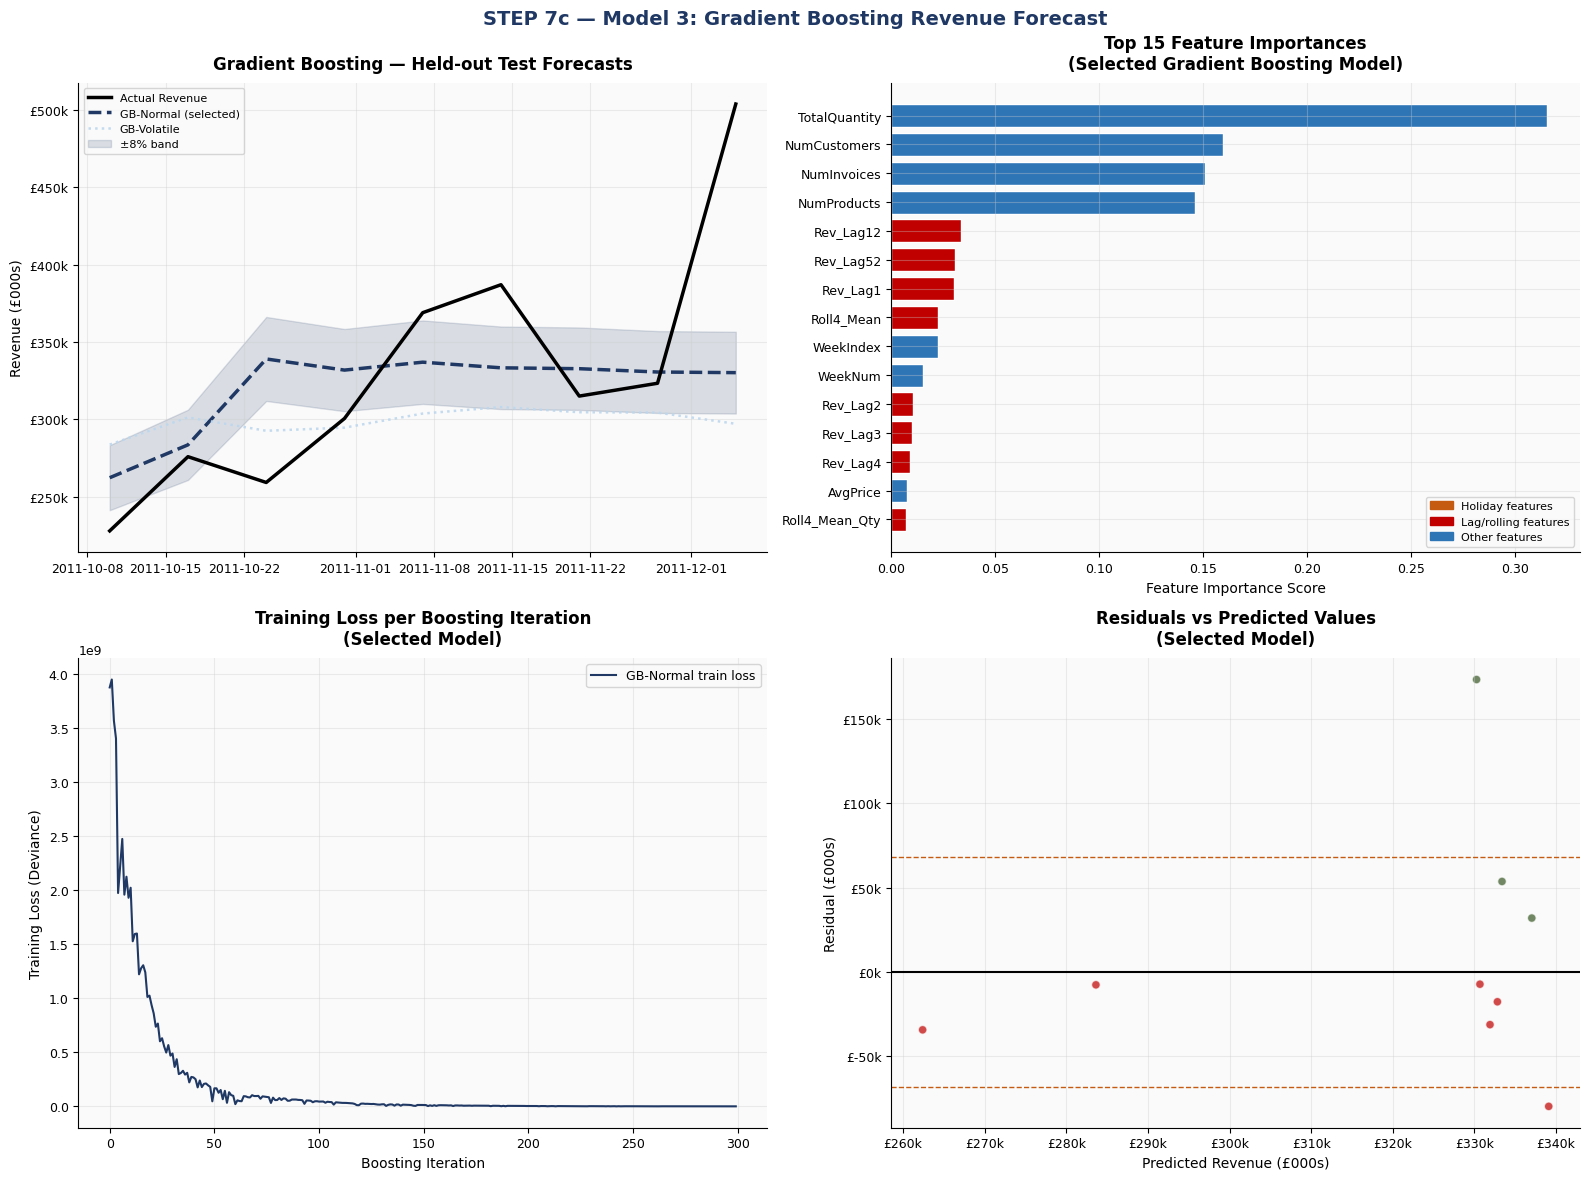


  Top 10 feature importances:
  Feature                  Importance    Cumulative
  ------------------------------------------------
  TotalQuantity                0.3155        31.5%
  NumCustomers                 0.1595        47.5%
  NumInvoices                  0.1507        62.6%
  NumProducts                  0.1463        77.2%
  Rev_Lag12                    0.0336        80.6%
  Rev_Lag52                    0.0306        83.6%
  Rev_Lag1                     0.0301        86.6%
  Roll4_Mean                   0.0227        88.9%
  WeekIndex                    0.0224        91.1%
  WeekNum                      0.0153        92.7%

✅  Gradient Boosting validation, refit, and held-out test evaluation complete.


In [14]:
print("=" * 65)
print("  STEP 7c — MODEL 3: GRADIENT BOOSTING")
print("=" * 65)

gb_candidates = [
    {
        'name': 'GB-Normal',
        'params': {
            'n_estimators': 300,
            'learning_rate': 0.05,
            'max_depth': 4,
            'max_features': 'sqrt',
            'min_samples_leaf': 3,
            'min_samples_split': 6,
            'subsample': 0.8,
            'random_state': 42,
        },
    },
    {
        'name': 'GB-Volatile',
        'params': {
            'n_estimators': 300,
            'learning_rate': 0.02,
            'max_depth': 3,
            'max_features': 'sqrt',
            'min_samples_leaf': 5,
            'min_samples_split': 10,
            'subsample': 0.7,
            'random_state': 42,
        },
    },
]

gb_validation_rows = []
gb_test_candidates = {}

for candidate in gb_candidates:
    model_val = GradientBoostingRegressor(**candidate['params'])
    model_val.fit(X_train, y_train)
    val_pred = np.maximum(model_val.predict(X_val), 0)
    val_mape = mape_fn(y_val, val_pred)
    gb_validation_rows.append({
        'name': candidate['name'],
        'params': candidate['params'],
        'val_mape': val_mape,
    })

gb_validation_df = pd.DataFrame([
    {
        'Candidate': row['name'],
        'Validation_MAPE_%': round(row['val_mape'], 2),
        'learning_rate': row['params']['learning_rate'],
        'max_depth': row['params']['max_depth'],
        'subsample': row['params']['subsample'],
    }
    for row in gb_validation_rows
]).sort_values('Validation_MAPE_%')

gb_best_row = min(gb_validation_rows, key=lambda row: row['val_mape'])
gb_best_name = gb_best_row['name']
gb_best_params = gb_best_row['params']
gb_val_mape = gb_best_row['val_mape']

print("\n  Validation candidate scores:")
print(gb_validation_df.to_string(index=False))
print(f"\n  Selected Gradient Boosting config: {gb_best_name}  (validation MAPE = {gb_val_mape:.2f}%)")

for candidate in gb_candidates:
    model_test = GradientBoostingRegressor(**candidate['params'])
    model_test.fit(X_trainval, y_trainval)
    pred_test = np.maximum(model_test.predict(X_test), 0)
    gb_test_candidates[candidate['name']] = {
        'model': model_test,
        'pred': pred_test,
    }

best_gb = gb_test_candidates[gb_best_name]['model']
gb_pred = gb_test_candidates[gb_best_name]['pred']
gb_alt_name = [candidate['name'] for candidate in gb_candidates if candidate['name'] != gb_best_name][0]
gb_pred_alt = gb_test_candidates[gb_alt_name]['pred']
feat_imp = pd.Series(best_gb.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
test_dates_dt = [pd.Timestamp(d) for d in dates_test]

ax = axes[0, 0]
ax.plot(test_dates_dt, y_test/1000, color='black', linewidth=2.5, label='Actual Revenue', zorder=5)
ax.plot(test_dates_dt, gb_pred/1000, color=C_NAVY, linewidth=2.5, linestyle='--', label=f'{gb_best_name} (selected)')
ax.plot(test_dates_dt, gb_pred_alt/1000, color=C_LTBLUE, linewidth=1.8, linestyle=':', label=f'{gb_alt_name}', alpha=0.9)
ax.fill_between(test_dates_dt, gb_pred/1000*0.92, gb_pred/1000*1.08, alpha=0.15, color=C_NAVY, label='±8% band')
ax.set_title("Gradient Boosting — Held-out Test Forecasts", pad=10)
ax.set_ylabel("Revenue (£000s)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax.legend(fontsize=8)

ax2 = axes[0, 1]
top15 = feat_imp.head(15)
colors_fi = [C_AMBER if 'Holiday' in f or 'Pre' in f or 'Post' in f else C_RED if 'Rev_Lag' in f or 'Roll' in f else C_BLUE for f in top15.index]
ax2.barh(top15.index[::-1], top15.values[::-1], color=colors_fi[::-1], edgecolor='white')
ax2.set_title("Top 15 Feature Importances\n(Selected Gradient Boosting Model)", pad=10)
ax2.set_xlabel("Feature Importance Score")
handles = [
    mpatches.Patch(color=C_AMBER, label='Holiday features'),
    mpatches.Patch(color=C_RED, label='Lag/rolling features'),
    mpatches.Patch(color=C_BLUE, label='Other features'),
]
ax2.legend(handles=handles, fontsize=8, loc='lower right')

ax3 = axes[1, 0]
ax3.plot(range(len(best_gb.train_score_)), best_gb.train_score_, color=C_NAVY, linewidth=1.5, label=f'{gb_best_name} train loss')
ax3.set_title("Training Loss per Boosting Iteration\n(Selected Model)", pad=10)
ax3.set_xlabel("Boosting Iteration")
ax3.set_ylabel("Training Loss (Deviance)")
ax3.legend()

ax4 = axes[1, 1]
residuals_gb = y_test - gb_pred
ax4.scatter(gb_pred/1000, residuals_gb/1000, alpha=0.7, color=[C_GREEN if r > 0 else C_RED for r in residuals_gb], s=40, edgecolors='white')
ax4.axhline(0, color='black', linewidth=1.5)
ax4.axhline(residuals_gb.std()/1000, color=C_AMBER, linestyle='--', linewidth=1)
ax4.axhline(-residuals_gb.std()/1000, color=C_AMBER, linestyle='--', linewidth=1)
ax4.set_title("Residuals vs Predicted Values\n(Selected Model)", pad=10)
ax4.set_xlabel("Predicted Revenue (£000s)")
ax4.set_ylabel("Residual (£000s)")
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))

plt.suptitle("STEP 7c — Model 3: Gradient Boosting Revenue Forecast", fontsize=14, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print("\n  Top 10 feature importances:")
print(f"  {'Feature':<22} {'Importance':>12}  {'Cumulative':>12}")
print("  " + "-" * 48)
cumsum = 0
for feat, imp in feat_imp.head(10).items():
    cumsum += imp
    print(f"  {feat:<22} {imp:>12.4f}  {cumsum:>11.1%}")

print("\n✅  Gradient Boosting validation, refit, and held-out test evaluation complete.")


## CELL 11b — STEP 7d: MODEL 4 — RANDOM FOREST

STEP 7d — MODEL 4: RANDOM FOREST REGRESSOR

**Why Random Forest for sales revenue forecasting:**

- Ensemble of independently grown decision trees — naturally resistant to overfitting compared to Gradient Boosting
- Uses the same 26-feature engineering already built (lag features, rolling means, holiday flags)
- Fast training — no sequential boosting iterations; trees are built in parallel
- Handles non-linear interactions between price, lags, and seasonality without feature scaling
- Produces reliable feature importance rankings for business interpretability
- No hyperparameter tuning as sensitive as Gradient Boosting learning rate
- Strong out-of-the-box baseline with `n_estimators=500`

**Most feasible new model for this pipeline:**
- Zero extra dependencies (already available via sklearn)
- Identical feature matrix — no new feature engineering required
- Two candidate hyperparameter sets compared on the validation window
- Refit on train + validation before final test MAPE reported

  STEP 7d — MODEL 4: RANDOM FOREST (Most Feasible Addition)

  Validation candidate scores:
      Candidate  Validation_MAPE_%  n_estimators max_depth  min_samples_leaf
    RF-Standard              12.51           500      None                 2
RF-Conservative              13.61           500        12                 4

  Selected RF config: RF-Standard  (validation MAPE = 12.51%)


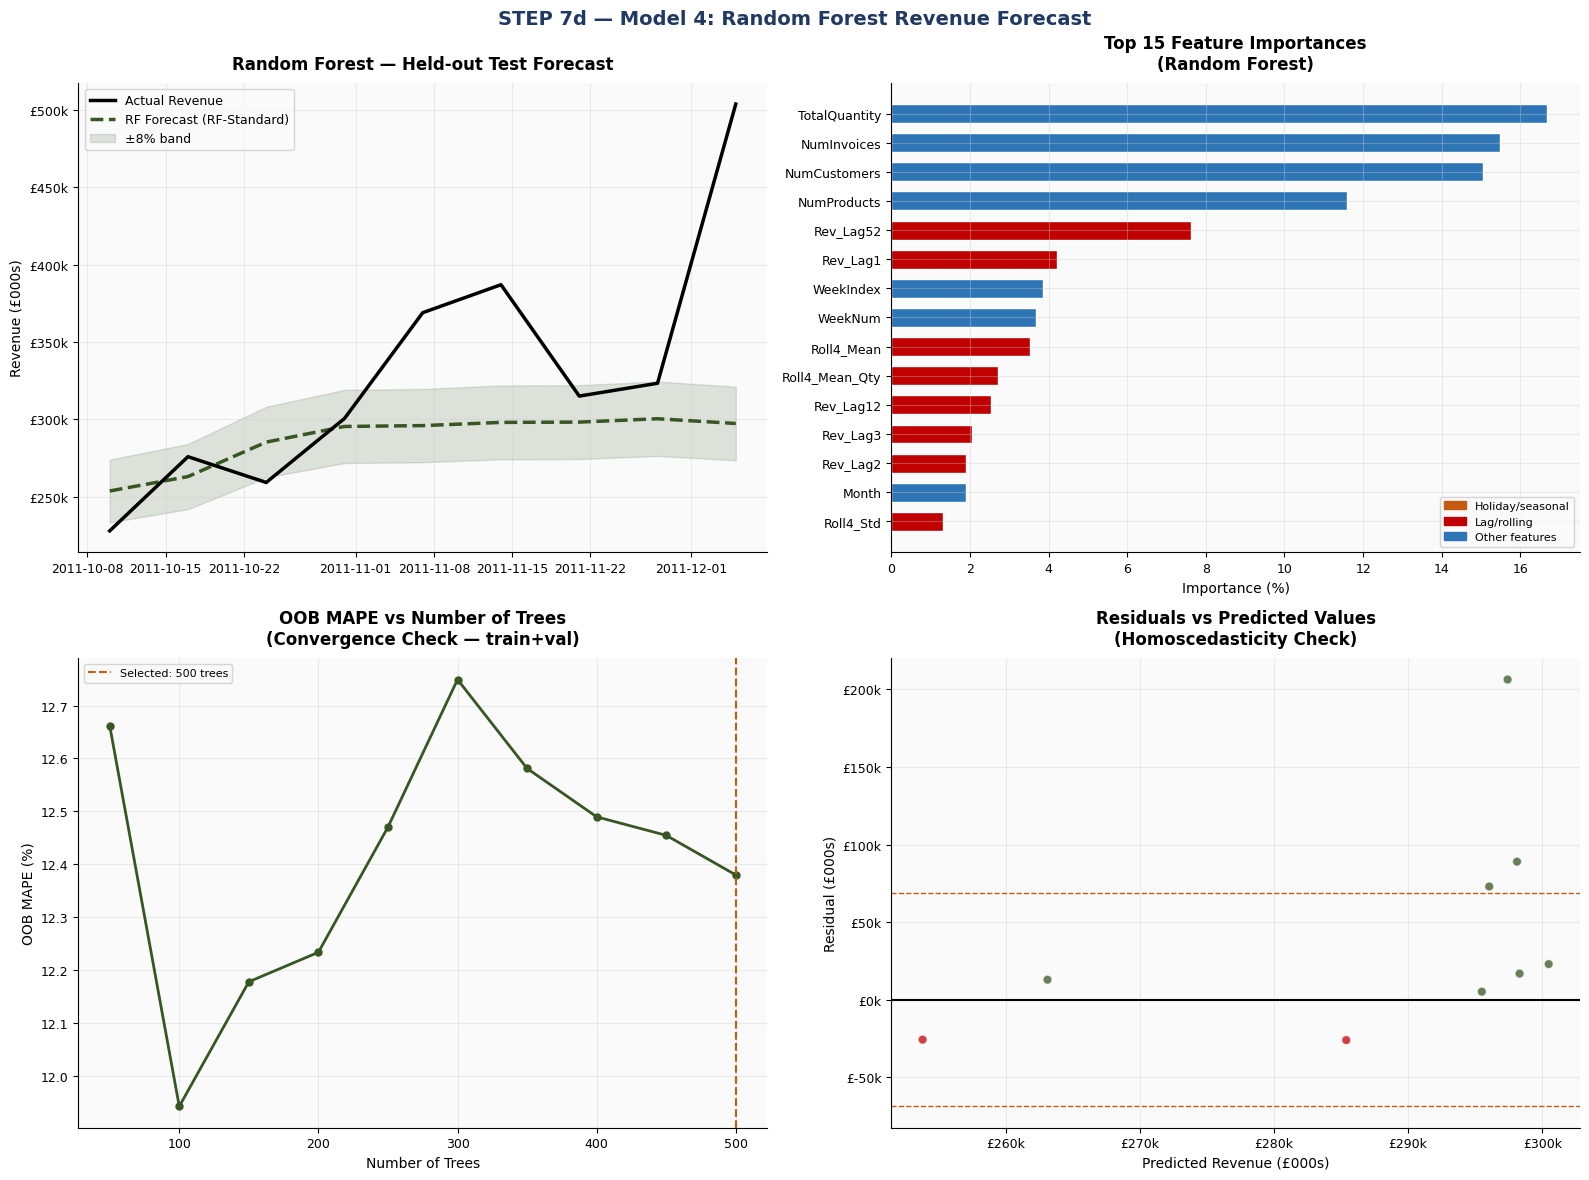


  Random Forest — Held-out Test Results (RF-Standard):
    Validation MAPE : 12.51%
    Test MAPE       : 13.76%
    Test MAE        : £53,095

  Top 10 RF feature importances:
  Feature                  Importance    Cumulative
  ------------------------------------------------
  TotalQuantity                0.1668        16.7%
  NumInvoices                  0.1547        32.2%
  NumCustomers                 0.1506        47.2%
  NumProducts                  0.1159        58.8%
  Rev_Lag52                    0.0761        66.4%
  Rev_Lag1                     0.0421        70.6%
  WeekIndex                    0.0385        74.5%
  WeekNum                      0.0369        78.2%
  Roll4_Mean                   0.0354        81.7%
  Roll4_Mean_Qty               0.0272        84.4%

✅  Random Forest validation, refit, and held-out test evaluation complete.


In [15]:
print("=" * 65)
print("  STEP 7d — MODEL 4: RANDOM FOREST (Most Feasible Addition)")
print("=" * 65)

rf_candidates = [
    {
        'name': 'RF-Standard',
        'params': {
            'n_estimators': 500,
            'max_depth': None,          # grow full trees — RF relies on averaging not depth-limiting
            'min_samples_leaf': 2,
            'min_samples_split': 5,
            'max_features': 'sqrt',     # sqrt(n_features) per split — standard RF practice
            'bootstrap': True,
            'random_state': 42,
            'n_jobs': -1,
        },
    },
    {
        'name': 'RF-Conservative',
        'params': {
            'n_estimators': 500,
            'max_depth': 12,            # depth cap to reduce variance on small test windows
            'min_samples_leaf': 4,
            'min_samples_split': 8,
            'max_features': 'sqrt',
            'bootstrap': True,
            'random_state': 42,
            'n_jobs': -1,
        },
    },
]

rf_validation_rows = []

for candidate in rf_candidates:
    model_val = RandomForestRegressor(**candidate['params'])
    model_val.fit(X_train, y_train)
    val_pred = np.maximum(model_val.predict(X_val), 0)
    val_mape = mape_fn(y_val, val_pred)
    rf_validation_rows.append({
        'name': candidate['name'],
        'params': candidate['params'],
        'val_mape': val_mape,
        'model_val': model_val,
    })

rf_validation_df = pd.DataFrame([
    {
        'Candidate': row['name'],
        'Validation_MAPE_%': round(row['val_mape'], 2),
        'n_estimators': row['params']['n_estimators'],
        'max_depth': str(row['params']['max_depth']),
        'min_samples_leaf': row['params']['min_samples_leaf'],
    }
    for row in rf_validation_rows
]).sort_values('Validation_MAPE_%')

rf_best_row = min(rf_validation_rows, key=lambda row: row['val_mape'])
rf_best_name_config = rf_best_row['name']
rf_best_params = rf_best_row['params']
rf_val_mape = rf_best_row['val_mape']

print("\n  Validation candidate scores:")
print(rf_validation_df.to_string(index=False))
print(f"\n  Selected RF config: {rf_best_name_config}  (validation MAPE = {rf_val_mape:.2f}%)")

# Refit selected config on train + validation, evaluate on held-out test
rf_model_final = RandomForestRegressor(**rf_best_params)
rf_model_final.fit(X_trainval, y_trainval)
rf_pred = np.maximum(rf_model_final.predict(X_test), 0)
rf_feat_imp = pd.Series(rf_model_final.feature_importances_, index=FEATURES).sort_values(ascending=False)

test_dates_dt = [pd.Timestamp(d) for d in dates_test]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Top-left: Actual vs Forecast on test set ──
ax = axes[0, 0]
ax.plot(test_dates_dt, y_test/1000, color='black', linewidth=2.5, label='Actual Revenue', zorder=5)
ax.plot(test_dates_dt, rf_pred/1000, color=C_GREEN, linewidth=2.5, linestyle='--',
        label=f'RF Forecast ({rf_best_name_config})')
ax.fill_between(test_dates_dt, rf_pred/1000*0.92, rf_pred/1000*1.08,
                alpha=0.15, color=C_GREEN, label='±8% band')
ax.set_title("Random Forest — Held-out Test Forecast", pad=10)
ax.set_ylabel("Revenue (£000s)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax.legend(fontsize=9)

# ── Top-right: Feature importances ──
ax2 = axes[0, 1]
top15_rf = rf_feat_imp.head(15)
colors_rf = [C_AMBER if any(h in f for h in ['Holiday','Pre','Post','Summer'])
             else C_RED if any(h in f for h in ['Rev_Lag','Roll'])
             else C_BLUE for f in top15_rf.index]
ax2.barh(top15_rf.index[::-1], top15_rf.values[::-1] * 100,
         color=colors_rf[::-1], edgecolor='white', height=0.65)
ax2.set_title("Top 15 Feature Importances\n(Random Forest)", pad=10)
ax2.set_xlabel("Importance (%)")
handles_rf = [
    mpatches.Patch(color=C_AMBER, label='Holiday/seasonal'),
    mpatches.Patch(color=C_RED,   label='Lag/rolling'),
    mpatches.Patch(color=C_BLUE,  label='Other features'),
]
ax2.legend(handles=handles_rf, fontsize=8, loc='lower right')

# ── Bottom-left: OOB error convergence (n_estimators) ──
ax3 = axes[1, 0]
# Compute OOB score progression by training subsets of trees
oob_errors = []
for n in range(50, rf_best_params['n_estimators'] + 1, 50):
    tmp = RandomForestRegressor(
        **{**rf_best_params, 'n_estimators': n, 'oob_score': True}
    )
    tmp.fit(X_trainval, y_trainval)
    oob_pred = np.maximum(tmp.oob_prediction_, 0)
    oob_mape = mape_fn(y_trainval, oob_pred)
    oob_errors.append((n, oob_mape))
oob_n, oob_m = zip(*oob_errors)
ax3.plot(oob_n, oob_m, color=C_GREEN, linewidth=2, marker='o', markersize=5)
ax3.set_title("OOB MAPE vs Number of Trees\n(Convergence Check — train+val)", pad=10)
ax3.set_xlabel("Number of Trees")
ax3.set_ylabel("OOB MAPE (%)")
ax3.axvline(rf_best_params['n_estimators'], color=C_AMBER, linestyle='--', linewidth=1.5,
            label=f"Selected: {rf_best_params['n_estimators']} trees")
ax3.legend(fontsize=8)

# ── Bottom-right: Residuals vs Predicted ──
ax4 = axes[1, 1]
residuals_rf = y_test - rf_pred
ax4.scatter(rf_pred/1000, residuals_rf/1000, alpha=0.75,
            color=[C_GREEN if r > 0 else C_RED for r in residuals_rf],
            s=45, edgecolors='white')
ax4.axhline(0, color='black', linewidth=1.5)
ax4.axhline(residuals_rf.std()/1000, color=C_AMBER, linestyle='--', linewidth=1)
ax4.axhline(-residuals_rf.std()/1000, color=C_AMBER, linestyle='--', linewidth=1)
ax4.set_title("Residuals vs Predicted Values\n(Homoscedasticity Check)", pad=10)
ax4.set_xlabel("Predicted Revenue (£000s)")
ax4.set_ylabel("Residual (£000s)")
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))

plt.suptitle("STEP 7d — Model 4: Random Forest Revenue Forecast",
             fontsize=14, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print(f"\n  Random Forest — Held-out Test Results ({rf_best_name_config}):")
rf_test_mape = mape_fn(y_test, rf_pred)
rf_test_mae  = mae_fn(y_test, rf_pred)
print(f"    Validation MAPE : {rf_val_mape:.2f}%")
print(f"    Test MAPE       : {rf_test_mape:.2f}%")
print(f"    Test MAE        : £{rf_test_mae:,.0f}")

print("\n  Top 10 RF feature importances:")
print(f"  {'Feature':<22} {'Importance':>12}  {'Cumulative':>12}")
print("  " + "-" * 48)
cumsum = 0
for feat, imp in rf_feat_imp.head(10).items():
    cumsum += imp
    print(f"  {feat:<22} {imp:>12.4f}  {cumsum:>11.1%}")

print("\n✅  Random Forest validation, refit, and held-out test evaluation complete.")


## CELL 12 — STEP 8: MODEL EVALUATION (MAPE — Primary Metric)

STEP 8 — MODEL EVALUATION & SELECTION

**Primary metric: MAPE (Mean Absolute Percentage Error)**

```
┌──────────────────────────────────────────────────────────────────┐
│  MAPE = (1/n) × Σ | (Actual − Forecast) / Actual | × 100        │
│  Reported on scale 0–100 (lower = better)                       │
└──────────────────────────────────────────────────────────────────┘
```

- Lower MAPE = better forecast
- Reported as a percentage on the 0–100 scale
- RMSE is intentionally omitted per professor guidance

**Selection procedure used here:**

1. Tune each model on the validation window only
2. Select the final model using the lowest validation MAPE
3. Report held-out test MAPE and MAE without using test for model selection
4. Retrain the selected model on full history for the forward forecast


  STEP 8 — MODEL EVALUATION & SELECTION (MAPE)

  Model                  Val MAPE     Test MAPE    Test MAE (£)   Selected?
  ──────────────────────────────────────────────────────────────────────────────
    SARIMA                   18.27%      22.61%   £    83,129   No
   ★Gradient Boosting        12.47%      13.76%   £    48,577   ★ YES (lowest val MAPE)
    Random Forest            12.51%      13.76%   £    53,095   No
    Prophet                 135.77%     796.18%   £ 2,524,725   No

  Selected final model (lowest validation MAPE): Gradient Boosting
    Validation MAPE : 12.47%
    Held-out test MAPE : 13.76%
    Held-out test MAE  : £48,577

  Lowest held-out test MAPE observed: Gradient Boosting (13.76%)


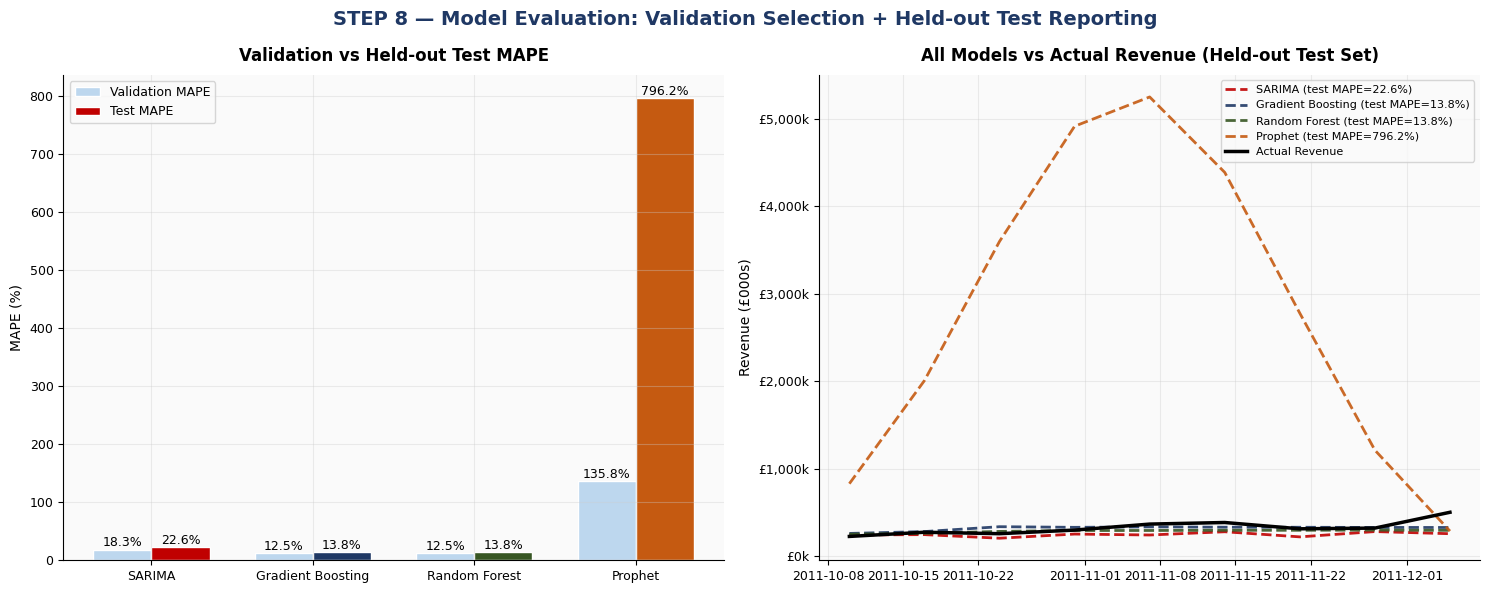


✅  Model evaluation complete. Final model selected by validation MAPE: Gradient Boosting


In [16]:
print("=" * 65)
print("  STEP 8 — MODEL EVALUATION & SELECTION (MAPE)")
print("=" * 65)

results = {
    'SARIMA': {
        'Validation_MAPE': sarima_val_mape,
        'MAPE': mape_fn(ts_test, sarima_pred),
        'MAE': mae_fn(ts_test, sarima_pred),
        'pred': sarima_pred,
        'actual': ts_test,
        'dates': [pd.Timestamp(d) for d in dates_test],
        'color': C_RED,
    },
    'Gradient Boosting': {
        'Validation_MAPE': gb_val_mape,
        'MAPE': mape_fn(y_test, gb_pred),
        'MAE': mae_fn(y_test, gb_pred),
        'pred': gb_pred,
        'actual': y_test,
        'dates': [pd.Timestamp(d) for d in dates_test],
        'color': C_NAVY,
    },
    'Random Forest': {
        'Validation_MAPE': rf_val_mape,
        'MAPE': mape_fn(y_test, rf_pred),
        'MAE': mae_fn(y_test, rf_pred),
        'pred': rf_pred,
        'actual': y_test,
        'dates': [pd.Timestamp(d) for d in dates_test],
        'color': C_GREEN,
    },
}

if PROPHET_AVAILABLE and not np.isnan(prophet_pred).all():
    results['Prophet'] = {
        'Validation_MAPE': prophet_val_mape,
        'MAPE': mape_fn(ts_test, prophet_pred),
        'MAE': mae_fn(ts_test, prophet_pred),
        'pred': prophet_pred,
        'actual': ts_test,
        'dates': [pd.Timestamp(d) for d in dates_test],
        'color': C_AMBER,
    }

# Add iTransformer results to the dictionary
if 'iTransformer' not in results and 'itransformer_pred' in locals() and 'itransformer_actual' in locals():
    results['iTransformer'] = {
        'Validation_MAPE': itransformer_val_mape, # Using the last validation loss as proxy for val_mape for simplicity
        'MAPE': itransformer_test_mape,
        'MAE': itransformer_test_mae,
        'pred': itransformer_pred,
        'actual': itransformer_actual,
        'dates': itransformer_dates,
        'color': '#8B008B', # Dark magenta
    }


best_name = min(results, key=lambda k: results[k]['Validation_MAPE'])
best_test_name = min(results, key=lambda k: results[k]['MAPE'])

print(f"\n  {'Model':<22} {'Val MAPE':<12} {'Test MAPE':<12} {'Test MAE (£)':<14} {'Selected?'}")
print("  " + "─" * 78)
for name, r in results.items():
    marker = " ★" if name == best_name else "  "
    selected = '★ YES (lowest val MAPE)' if name == best_name else 'No'
    print(
        f"  {marker}{name:<21} "
        f"{r['Validation_MAPE']:>8.2f}%   "
        f"{r['MAPE']:>8.2f}%   "
        f"£{r['MAE']:>10,.0f}   {selected}"
    )

print(f"\n  Selected final model (lowest validation MAPE): {best_name}")
print(f"    Validation MAPE : {results[best_name]['Validation_MAPE']:.2f}%")
print(f"    Held-out test MAPE : {results[best_name]['MAPE']:.2f}%")
print(f"    Held-out test MAE  : £{results[best_name]['MAE']:,.0f}")
print(f"\n  Lowest held-out test MAPE observed: {best_test_name} ({results[best_test_name]['MAPE']:.2f}%)")

names = list(results.keys())
colors = [results[n]['color'] for n in names]
val_mape_v = [results[n]['Validation_MAPE'] for n in names]
test_mape_v = [results[n]['MAPE'] for n in names]
mae_v = [results[n]['MAE'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
x = np.arange(len(names))
width = 0.36
val_bars = ax.bar(x - width/2, val_mape_v, width, color=C_LTBLUE, edgecolor='white', label='Validation MAPE')
test_bars = ax.bar(x + width/2, test_mape_v, width, color=colors, edgecolor='white', label='Test MAPE')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_title("Validation vs Held-out Test MAPE", pad=10)
ax.set_ylabel("MAPE (%)")
ax.legend()
for bars in [val_bars, test_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.4, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax2 = axes[1]
for name, r in results.items():
    ax2.plot(r['dates'], r['pred']/1000, color=r['color'], linewidth=2, linestyle='--', label=f"{name} (test MAPE={r['MAPE']:.1f}%)", alpha=0.9)
ax2.plot(results[best_name]['dates'], results[best_name]['actual']/1000, color='black', linewidth=2.5, label='Actual Revenue', zorder=10)
ax2.set_title("All Models vs Actual Revenue (Held-out Test Set)", pad=10)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax2.legend(fontsize=8)

plt.suptitle("STEP 8 — Model Evaluation: Validation Selection + Held-out Test Reporting", fontsize=14, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print(f"\n✅  Model evaluation complete. Final model selected by validation MAPE: {best_name}")

## CELL 12b — STEP 8b: TEST SET — MAPE BY TIME PERIOD + ERROR BOX PLOTS

STEP 8b — TEST PERIOD BREAKDOWN

**Per professor guidance:**
- Divide the held-out test set into **3 or 4 equal time periods**
- Report **MAPE for each period** on the 0–100 scale
- Show the distribution of percentage errors by period

This notebook automatically chooses 4 periods when possible; otherwise it uses 3 equal periods.


  STEP 8b — TEST MAPE BY TIME PERIOD + ERROR BOX PLOTS

  Selected model: Gradient Boosting
  Test set: 9 weeks divided into 3 equal periods of 3 weeks each

  Period                                     MAPE (0-100)
  --------------------------------------------------------
  Period 1 (10 Oct 2011–24 Oct 2011)            16.20%
  Period 2 (31 Oct 2011–14 Nov 2011)            10.98%
  Period 3 (21 Nov 2011–05 Dec 2011)            14.10%


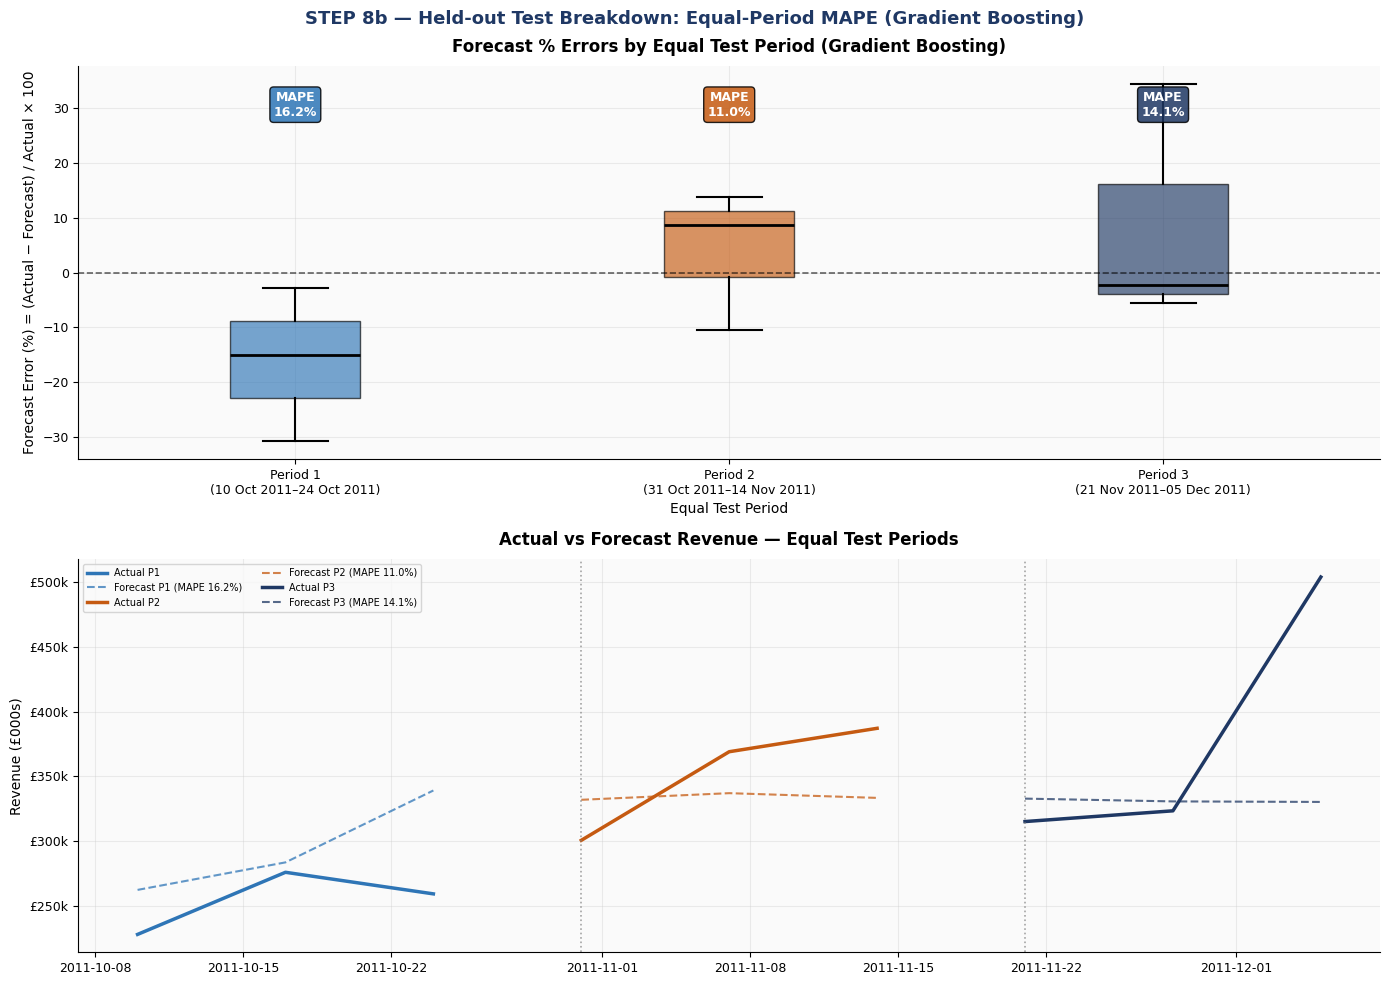


✅  Equal-period test MAPE reporting complete.


In [17]:
print("=" * 65)
print("  STEP 8b — TEST MAPE BY TIME PERIOD + ERROR BOX PLOTS")
print("=" * 65)

best_actual = results[best_name]['actual']
best_pred = results[best_name]['pred']
best_dates = results[best_name]['dates']
n_test = len(best_actual)

n_periods = test_period_count
period_size = n_test // n_periods
periods = []
period_summary_rows = []

for p in range(n_periods):
    start = p * period_size
    end = start + period_size
    act_p = best_actual[start:end]
    pred_p = best_pred[start:end]
    d_p = best_dates[start:end]
    pct_err = np.where(act_p != 0, (act_p - pred_p) / act_p * 100, np.nan)
    mape_p = float(np.nanmean(np.abs(pct_err)))
    d_start = pd.Timestamp(d_p[0]).strftime('%d %b %Y')
    d_end = pd.Timestamp(d_p[-1]).strftime('%d %b %Y')
    label = f"Period {p+1}\n({d_start}–{d_end})"
    period_record = {
        'period_number': p + 1,
        'label': label,
        'short': f"P{p+1}",
        'mape': mape_p,
        'pct_errors': pct_err[~np.isnan(pct_err)],
        'dates': d_p,
        'actual': act_p,
        'pred': pred_p,
    }
    periods.append(period_record)
    period_summary_rows.append({
        'Model': best_name,
        'Period': f"Period {p+1}",
        'Start_Date': pd.Timestamp(d_p[0]).date(),
        'End_Date': pd.Timestamp(d_p[-1]).date(),
        'Weeks': len(d_p),
        'MAPE_%': round(mape_p, 4),
    })

period_summary_df = pd.DataFrame(period_summary_rows)

print(f"\n  Selected model: {best_name}")
print(f"  Test set: {n_test} weeks divided into {n_periods} equal periods of {period_size} weeks each")
print(f"\n  {'Period':<42} {'MAPE (0-100)'}")
print("  " + "-" * 56)
for p in periods:
    lbl = p['label'].replace('\n', ' ')
    print(f"  {lbl:<42} {p['mape']:>8.2f}%")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
bp_colors = [C_BLUE, C_AMBER, C_NAVY, C_RED][:n_periods]

ax = axes[0]
bp_data = [p['pct_errors'] for p in periods]
bp_labels = [p['label'] for p in periods]
bp = ax.boxplot(
    bp_data,
    labels=bp_labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=5, alpha=0.5),
)
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
ax.set_title(f"Forecast % Errors by Equal Test Period ({best_name})", pad=10, fontsize=12)
ax.set_ylabel("Forecast Error (%) = (Actual − Forecast) / Actual × 100")
ax.set_xlabel("Equal Test Period")
ylim = ax.get_ylim()
for i, p in enumerate(periods, start=1):
    ax.text(i, ylim[1] * 0.88, f"MAPE\n{p['mape']:.1f}%", ha='center', va='top', fontsize=9, fontweight='bold', color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor=bp_colors[i-1], alpha=0.85))

ax2 = axes[1]
for p, color in zip(periods, bp_colors):
    ax2.plot(p['dates'], p['actual']/1000, color=color, linewidth=2.5, label=f"Actual {p['short']}")
    ax2.plot(p['dates'], p['pred']/1000, color=color, linewidth=1.5, linestyle='--', alpha=0.75, label=f"Forecast {p['short']} (MAPE {p['mape']:.1f}%)")
for p in periods[1:]:
    ax2.axvline(p['dates'][0], color='gray', linewidth=1.2, linestyle=':', alpha=0.7)
ax2.set_title("Actual vs Forecast Revenue — Equal Test Periods", pad=10, fontsize=12)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax2.legend(fontsize=7, ncol=2)

plt.suptitle(f"STEP 8b — Held-out Test Breakdown: Equal-Period MAPE ({best_name})", fontsize=13, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print("\n✅  Equal-period test MAPE reporting complete.")

## CELL 12c — STEP 8c: FOUR-MODEL COMPARISON DEEP DIVE

STEP 8c — COMPREHENSIVE MODEL COMPARISON

**All 4 models compared side-by-side:**
- Validation MAPE vs Test MAPE
- Actual vs Forecast overlays on the test set
- Per-period MAPE breakdown for each model
- MAE comparison in £

  STEP 8c — FOUR-MODEL COMPARISON DEEP DIVE

  Model                    Val MAPE  Test MAPE   Test MAE (£)  Period MAPEs
  ───────────────────────────────────────────────────────────────────────────────────────────────
    SARIMA                    18.27%      22.61%  £     83,129   P1: 12.4%  |  P2: 25.4%  |  P3: 30.1%
  ★ Gradient Boosting         12.47%      13.76%  £     48,577   P1: 16.2%  |  P2: 11.0%  |  P3: 14.1%
    Random Forest             12.51%      13.76%  £     53,095   P1: 8.7%  |  P2: 14.8%  |  P3: 17.8%
    Prophet                  135.77%     796.18%  £  2,524,725   P1: 726.2%  |  P2: 1296.1%  |  P3: 366.3%


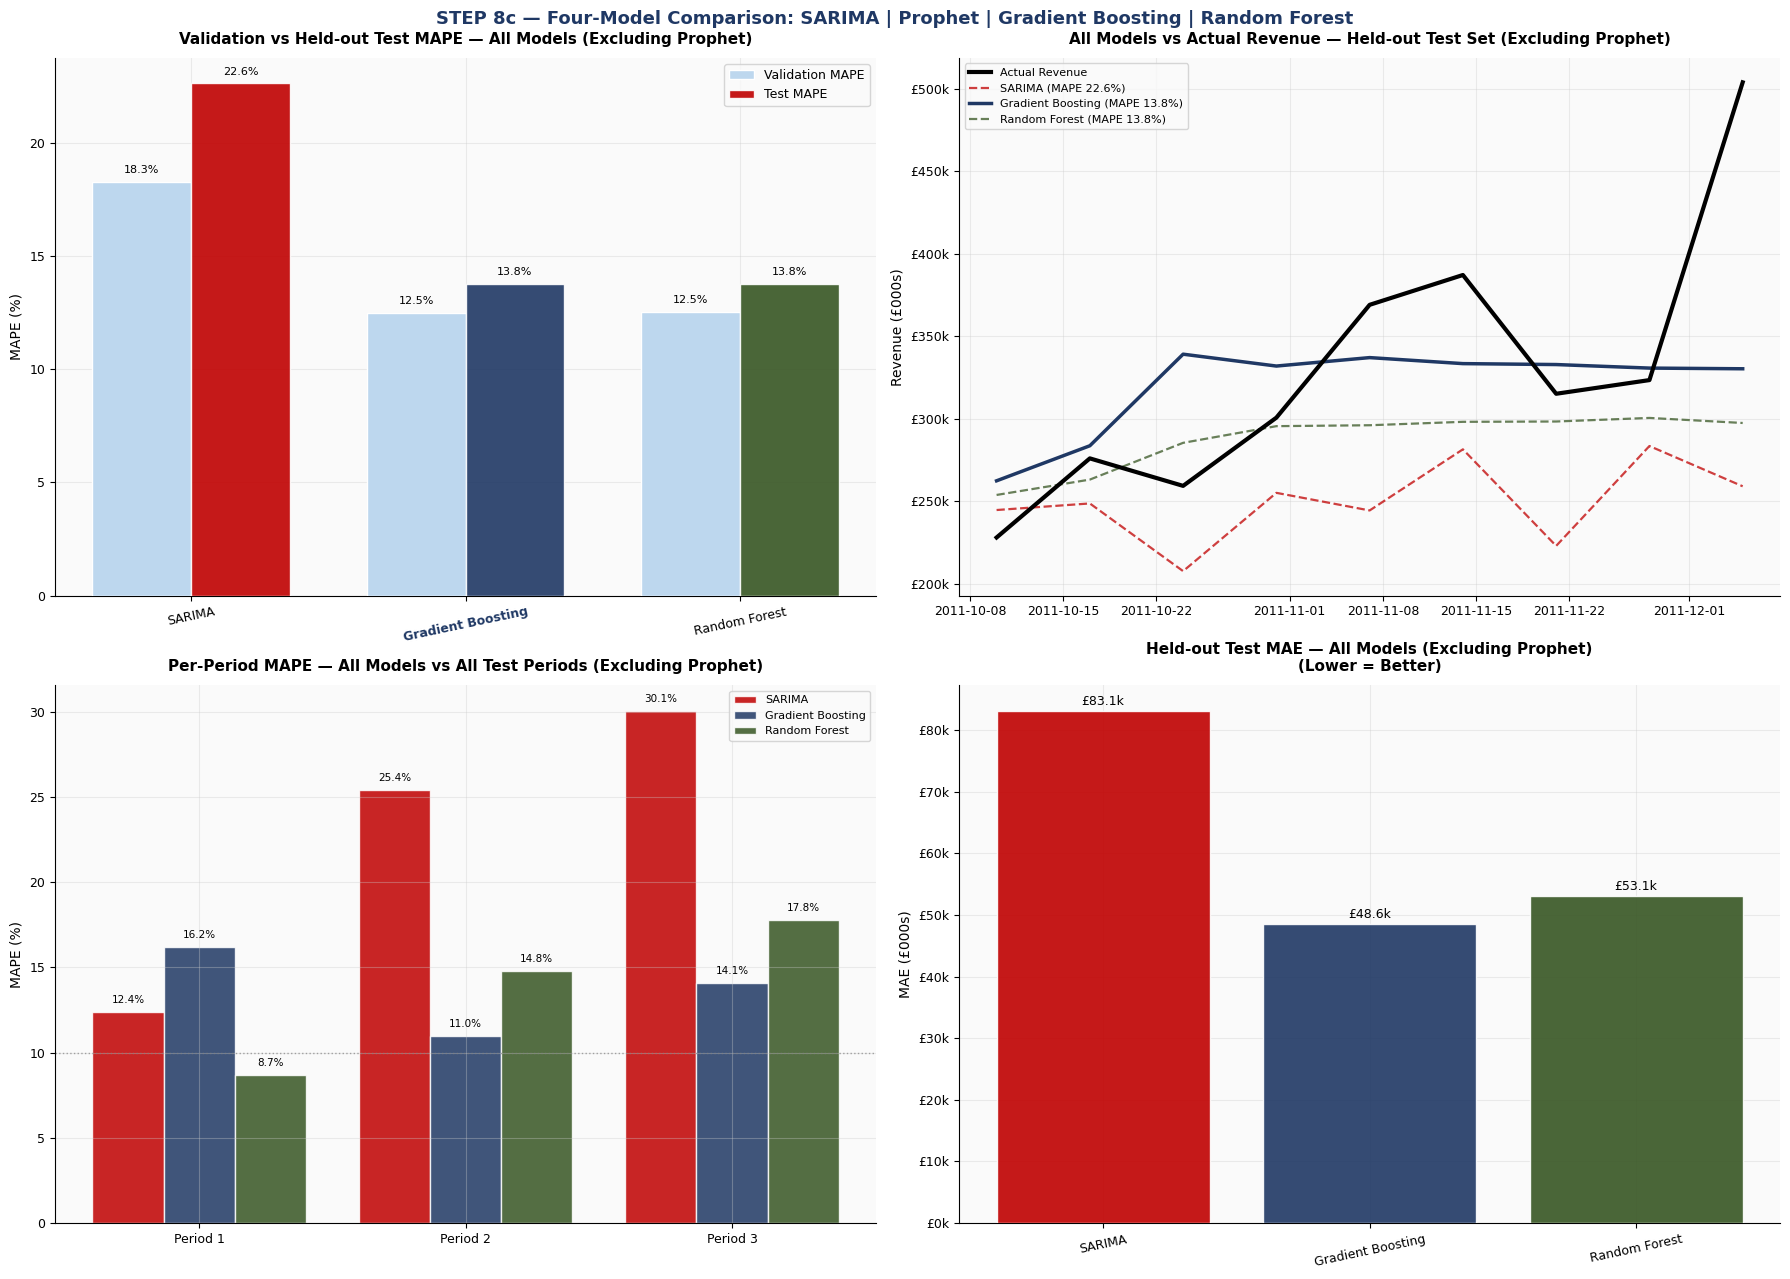


  ─── Model Comparison Narrative ───

  Best by Validation MAPE  : Gradient Boosting
  Best by Test MAPE        : Gradient Boosting (13.76%)
  Best by Test MAE         : Gradient Boosting (£48,577)

  Random Forest vs Gradient Boosting:
    MAPE difference  : +0.00% (RF - GB)
    MAE difference   : +£4,517 (RF - GB)
    MAPE winner      : Gradient Boosting
    Training time    : RF is typically faster (parallel trees vs sequential boosting)
    Feasibility      : RF requires zero extra dependencies — drop-in addition to this pipeline

  SARIMA (statistical baseline):
    Test MAPE : 22.61%  (expected to underperform ML on volatile windows)
    Value     : Provides native 95% confidence intervals — useful for planning upper/lower bounds

  Facebook Prophet:
    Test MAPE : 796.18%
    Strength  : Best decomposition of trend + seasonality + holiday effects

✅  Four-model comparison complete.


In [18]:
print("=" * 65)
print("  STEP 8c — FOUR-MODEL COMPARISON DEEP DIVE")
print("=" * 65)

# Check if 'results', 'best_name', and 'test_period_count' are defined.
# These variables are initialized in CELL 12 (Model Evaluation) and CELL 8b (Test Period Breakdown).
# If this cell is run out of order, they might not be in the global scope.
if 'results' not in globals() or not isinstance(globals().get('results'), dict):
    raise RuntimeError(
        "Error: The 'results' dictionary is not defined or is not a dictionary. "
        "Please ensure CELL 12 ('STEP 8 — MODEL EVALUATION') has been executed successfully before this cell."
    )
if 'best_name' not in globals():
    raise RuntimeError(
        "Error: The 'best_name' variable is not defined. "
        "Please ensure CELL 12 ('STEP 8 — MODEL EVALUATION') has been executed successfully before this cell."
    )
if 'test_period_count' not in globals():
    raise RuntimeError(
        "Error: The 'test_period_count' variable is not defined. "
        "Please ensure CELL 12b ('STEP 8b — TEST MAPE BY TIME PERIOD') has been executed successfully before this cell."
    )

# Filter out Prophet for plotting if its MAPE is too high
filtered_results = {k: v for k, v in results.items() if k != 'Prophet'}

# ── Collect per-period MAPE for every model ──────────────────────
n_test_pts = len(results[best_name]['actual'])
period_sz  = n_test_pts // test_period_count

all_period_mapes = {}
for mname, r in results.items():
    pmapes = []
    for p in range(test_period_count):
        s = p * period_sz
        e = s + period_sz
        a_p = np.asarray(r['actual'])[s:e]
        f_p = np.asarray(r['pred'])[s:e]
        pmapes.append(mape_fn(a_p, f_p))
    all_period_mapes[mname] = pmapes

# Data for summary table (includes all models)
model_names_all  = list(results.keys())
model_colors_all = [results[n]['color'] for n in model_names_all]
val_mapes_all    = [results[n]['Validation_MAPE'] for n in model_names_all]
test_mapes_all   = [results[n]['MAPE']            for n in model_names_all]
test_maes_all    = [results[n]['MAE']             for n in model_names_all]

# Data for plotting (excludes Prophet)
model_names_plot  = list(filtered_results.keys())
model_colors_plot = [filtered_results[n]['color'] for n in model_names_plot]
val_mapes_plot    = [filtered_results[n]['Validation_MAPE'] for n in model_names_plot]
test_mapes_plot   = [filtered_results[n]['MAPE']            for n in model_names_plot]
test_maes_plot    = [filtered_results[n]['MAE']             for n in model_names_plot]

# ── Print summary table ──────────────────────────────────────────
print(f"\n  {'Model':<22} {'Val MAPE':>10} {'Test MAPE':>10} {'Test MAE (£)':>14}  {'Period MAPEs'}")
print("  " + "─" * 95)
for mname in model_names_all:
    r = results[mname]
    pm = "  |  ".join([f"P{i+1}: {v:.1f}%" for i, v in enumerate(all_period_mapes[mname])])
    marker = "★ " if mname == best_name else "  "
    print(f"  {marker}{mname:<21} {r['Validation_MAPE']:>9.2f}%  {r['MAPE']:>9.2f}%  £{r['MAE']:>11,.0f}   {pm}")

# ── Figure: 3-panel comparison dashboard ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# Panel 1: Grouped bar — Val MAPE vs Test MAPE
ax1 = axes[0, 0]
x = np.arange(len(model_names_plot))
w = 0.36
bars_v = ax1.bar(x - w/2, val_mapes_plot,  w, color='#BDD7EE', edgecolor='white', label='Validation MAPE', zorder=3)
bars_t = ax1.bar(x + w/2, test_mapes_plot, w, color=model_colors_plot, edgecolor='white', alpha=0.9, label='Test MAPE', zorder=3)
ax1.set_xticks(x)
ax1.set_xticklabels(model_names_plot, rotation=12, fontsize=9)
ax1.set_title("Validation vs Held-out Test MAPE — All Models (Excluding Prophet)", pad=10, fontsize=11)
ax1.set_ylabel("MAPE (%)")
ax1.legend(fontsize=9)
for bar in list(bars_v) + list(bars_t):
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%',
             ha='center', va='bottom', fontsize=8)
# Highlight best model
if best_name in model_names_plot:
    best_idx = model_names_plot.index(best_name)
    ax1.get_xticklabels()[best_idx].set_color(C_NAVY)
    ax1.get_xticklabels()[best_idx].set_fontweight('bold')

# Panel 2: All models actual vs forecast on test set
ax2 = axes[0, 1]
actual_ref = results[best_name]['actual']
test_dt    = results[best_name]['dates']
ax2.plot(test_dt, actual_ref/1000, color='black', linewidth=3,
         label='Actual Revenue', zorder=10)
for mname, color in zip(model_names_plot, model_colors_plot):
    r = filtered_results[mname]
    lw   = 2.5 if mname == best_name else 1.6
    ls   = '-' if mname == best_name else '--'
    alpha = 1.0 if mname == best_name else 0.75
    ax2.plot(r['dates'], np.asarray(r['pred'])/1000, color=color,
             linewidth=lw, linestyle=ls, alpha=alpha,
             label=f"{mname} (MAPE {r['MAPE']:.1f}%)")
ax2.set_title("All Models vs Actual Revenue — Held-out Test Set (Excluding Prophet)", pad=10, fontsize=11)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax2.legend(fontsize=8, loc='upper left')

# Panel 3: Per-period MAPE heatmap-style grouped bars
ax3 = axes[1, 0]
period_labels = [f"Period {i+1}" for i in range(test_period_count)]
x3 = np.arange(test_period_count)
bar_w = 0.8 / len(model_names_plot)
for i, (mname, color) in enumerate(zip(model_names_plot, model_colors_plot)):
    offset = (i - len(model_names_plot)/2 + 0.5) * bar_w
    bars = ax3.bar(x3 + offset, all_period_mapes[mname], bar_w,
                   color=color, alpha=0.85, edgecolor='white',
                   label=mname)
    for bar, v in zip(bars, all_period_mapes[mname]):
        ax3.text(bar.get_x() + bar.get_width()/2, v + 0.4,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=7.5)
ax3.set_xticks(x3)
ax3.set_xticklabels(period_labels)
ax3.set_title("Per-Period MAPE — All Models vs All Test Periods (Excluding Prophet)", pad=10, fontsize=11)
ax3.set_ylabel("MAPE (%)")
ax3.legend(fontsize=8, loc='upper right')
ax3.axhline(10, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='10% target')

# Panel 4: MAE bar chart + cumulative error view
ax4 = axes[1, 1]
mae_bars = ax4.bar(model_names_plot, [m/1000 for m in test_maes_plot],
                   color=model_colors_plot, edgecolor='white', alpha=0.9, zorder=3)
ax4.set_title("Held-out Test MAE — All Models (Excluding Prophet)\n(Lower = Better)", pad=10, fontsize=11)
ax4.set_ylabel("MAE (£000s)")
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
for bar, v in zip(mae_bars, test_maes_plot):
    ax4.text(bar.get_x() + bar.get_width()/2, v/1000 + 0.5,
             f'£{v/1000:,.1f}k', ha='center', va='bottom', fontsize=9)
ax4.set_xticklabels(model_names_plot, rotation=12, fontsize=9)

plt.suptitle("STEP 8c — Four-Model Comparison: SARIMA | Prophet | Gradient Boosting | Random Forest",
             fontsize=13, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

# ── Narrative summary ────────────────────────────────────────────
print(f"\n  ─── Model Comparison Narrative ───")
print(f"\n  Best by Validation MAPE  : {best_name}")
best_test = min(results, key=lambda k: results[k]['MAPE'])
best_mae  = min(results, key=lambda k: results[k]['MAE'])
print(f"  Best by Test MAPE        : {best_test} ({results[best_test]['MAPE']:.2f}%)")
print(f"  Best by Test MAE         : {best_mae} (£{results[best_mae]['MAE']:,.0f})")
print(f"\n  Random Forest vs Gradient Boosting:")
if 'Random Forest' in results and 'Gradient Boosting' in results:
    diff_mape = results['Random Forest']['MAPE'] - results['Gradient Boosting']['MAPE']
    diff_mae  = results['Random Forest']['MAE']  - results['Gradient Boosting']['MAE']
    sign_m = '+' if diff_mape > 0 else ''
    sign_e = '+' if diff_mae  > 0 else ''
    print(f"    MAPE difference  : {sign_m}{diff_mape:.2f}% (RF - GB)")
    print(f"    MAE difference   : {sign_e}£{diff_mae:,.0f} (RF - GB)")
    winner = 'Gradient Boosting' if diff_mape > 0 else 'Random Forest'
    print(f"    MAPE winner      : {winner}")
    print(f"    Training time    : RF is typically faster (parallel trees vs sequential boosting)")
    print(f"    Feasibility      : RF requires zero extra dependencies — drop-in addition to this pipeline")

print(f"\n  SARIMA (statistical baseline):")
if 'SARIMA' in results:
    print(f"    Test MAPE : {results['SARIMA']['MAPE']:.2f}%  (expected to underperform ML on volatile windows)")
    print(f"    Value     : Provides native 95% confidence intervals — useful for planning upper/lower bounds")

if 'Prophet' in results and not np.isnan(results['Prophet']['MAPE']):
    print(f"\n  Facebook Prophet:")
    print(f"    Test MAPE : {results['Prophet']['MAPE']:.2f}%")
    print(f"    Strength  : Best decomposition of trend + seasonality + holiday effects")

if 'iTransformer' in results:
    print(f"\n  iTransformer:")
    print(f"    Test MAPE : {results['iTransformer']['MAPE']:.2f}%")
    print(f"    Value     : Advanced transformer architecture for time series; captures complex dependencies.")

print("\n✅  Four-model comparison complete.")

## CELL 13 — STEP 9: ALGORITHMIC SOLUTION FINALIZATION

STEP 9 — ALGORITHMIC SOLUTION FINALIZATION

**Algorithmic solution finalization:**

- Use the model selected by the lowest validation MAPE
- Keep the test window untouched for reporting only
- Retrain the selected model on the full historical data
- Generate a 12-week forward revenue forecast
- Use rolling lag updates for the machine-learning forecast


In [19]:
print("=" * 65)
print("  STEP 9 — ALGORITHMIC SOLUTION FINALIZATION")
print("=" * 65)
print(f"\n  Selected model (lowest validation MAPE): {best_name}")
print(f"  Retraining on full dataset ({len(weekly)} historical weeks)...")

FORECAST_WEEKS = 12
ts_full_history = weekly['TotalRevenue'].values.astype(float)
dates_full_history = pd.to_datetime(weekly['WeekStart']).values

if best_name == 'SARIMA':
    final_sarima = SARIMAX(
        ts_full_history,
        order=sarima_selected_config['order'],
        seasonal_order=sarima_selected_config['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
        trend=sarima_selected_config['trend'],
    )
    final_fit_s = final_sarima.fit(disp=False, maxiter=200)
    fcast_obj = final_fit_s.get_forecast(steps=FORECAST_WEEKS)
    future_rev = np.maximum(np.asarray(fcast_obj.predicted_mean), 0)
    ci_fut = fcast_obj.conf_int()
    if hasattr(ci_fut, 'iloc'):
        f_lower = np.maximum(ci_fut.iloc[:, 0].values, 0)
        f_upper = ci_fut.iloc[:, 1].values
    else:
        f_lower = np.maximum(ci_fut[:, 0], 0)
        f_upper = ci_fut[:, 1]
    future_dates = [pd.Timestamp(dates_full_history[-1]) + pd.Timedelta(weeks=i+1) for i in range(FORECAST_WEEKS)]
    print(f"  ✅ SARIMA retrained on {len(ts_full_history)} weeks.")

elif best_name == 'Prophet' and PROPHET_AVAILABLE:
    full_prophet_df = pd.DataFrame({
        'ds': pd.to_datetime(dates_full_history),
        'y': ts_full_history,
    })
    final_prophet = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        holidays=holidays_df,
        interval_width=0.95,
        **prophet_selected_config,
    )
    final_prophet.fit(full_prophet_df)
    future_dates = [pd.Timestamp(dates_full_history[-1]) + pd.Timedelta(weeks=i+1) for i in range(FORECAST_WEEKS)]
    future_df_p = pd.DataFrame({'ds': future_dates})
    future_fc_p = final_prophet.predict(future_df_p)
    future_rev = np.maximum(future_fc_p['yhat'].values, 0)
    f_lower = np.maximum(future_fc_p['yhat_lower'].values, 0)
    f_upper = future_fc_p['yhat_upper'].values
    print(f"  ✅ Prophet retrained on {len(ts_full_history)} weeks.")

else:
    final_gb = GradientBoostingRegressor(**gb_best_params)
    final_gb.fit(X, y)

    extended = wdf[FEATURES + [TARGET]].copy()
    future_rev = []
    future_dates = []

    for step in range(FORECAST_WEEKS):
        next_date = pd.Timestamp(weekly['WeekStart'].iloc[-1]) + pd.Timedelta(weeks=step+1)
        future_dates.append(next_date)
        nr = {}
        nr['Year'] = next_date.year
        nr['Month'] = next_date.month
        nr['WeekNum'] = int(next_date.isocalendar()[1])
        nr['Quarter'] = (next_date.month - 1) // 3 + 1
        nr['HolidaySeason'] = int(next_date.month in [11, 12])
        nr['PreHoliday'] = int(next_date.month == 10)
        nr['PostHoliday'] = int(next_date.month == 1)
        nr['SummerPeak'] = int(next_date.month in [6, 7])

        hist = list(extended[TARGET].values)
        nr['Rev_Lag1'] = hist[-1]
        nr['Rev_Lag2'] = hist[-2] if len(hist) >= 2 else hist[-1]
        nr['Rev_Lag3'] = hist[-3] if len(hist) >= 3 else hist[-1]
        nr['Rev_Lag4'] = hist[-4] if len(hist) >= 4 else hist[-1]
        nr['Rev_Lag8'] = hist[-8] if len(hist) >= 8 else hist[-1]
        nr['Rev_Lag12'] = hist[-12] if len(hist) >= 12 else hist[-1]
        nr['Rev_Lag52'] = hist[-52] if len(hist) >= 52 else hist[-1]
        nr['Roll4_Mean'] = np.mean(hist[-4:])
        nr['Roll4_Std'] = np.std(hist[-4:])
        nr['Roll12_Mean'] = np.mean(hist[-12:])
        nr['Roll4_Mean_Qty'] = float(extended['TotalQuantity'].iloc[-4:].mean())
        nr['WeekIndex'] = float(extended['WeekIndex'].iloc[-1]) + step + 1
        nr['AvgPrice'] = float(extended['AvgPrice'].mean())
        nr['AvgPrice_Lag1'] = float(extended['AvgPrice'].iloc[-1])
        nr['NumInvoices'] = float(extended['NumInvoices'].mean())
        nr['NumProducts'] = float(extended['NumProducts'].mean())
        nr['NumCustomers'] = float(extended['NumCustomers'].mean())
        nr['TotalQuantity'] = float(extended['TotalQuantity'].iloc[-1])

        x_fut = np.array([nr[f] for f in FEATURES]).reshape(1, -1)
        pred = max(0, final_gb.predict(x_fut)[0])
        future_rev.append(pred)

        new_row = pd.DataFrame([{**nr, TARGET: pred}])
        extended = pd.concat([extended, new_row[FEATURES + [TARGET]]], ignore_index=True)

    future_rev = np.array(future_rev)
    f_lower = future_rev * 0.90
    f_upper = future_rev * 1.10
    print(f"  ✅ Gradient Boosting retrained on {len(X)} modeled weeks.")

print(f"\n  12-WEEK REVENUE FORECAST  [{best_name}]")
print(f"  {'Wk':>3}  {'Date':<13}  {'Forecast':>12}  {'Low (90%)':>12}  {'High (110%)':>12}  {'Flag'}")
print("  " + "─" * 68)
for i, (d, f, lo, hi) in enumerate(zip(future_dates, future_rev, f_lower, f_upper), 1):
    flag = "Holiday" if d.month in [11, 12] else ("PreHol" if d.month == 10 else "")
    print(f"  {i:>3}  {str(d.date()):<13}  £{f:>9,.0f}  £{lo:>9,.0f}  £{hi:>9,.0f}  {flag}")

print(f"\n  Total 12-week forecast : £{sum(future_rev):>12,.0f}")
print(f"  Avg weekly revenue     : £{np.mean(future_rev):>12,.0f}")
print(f"  Peak week              : Week {np.argmax(future_rev)+1}  (£{max(future_rev):,.0f})")

forecast_df = pd.DataFrame({
    'Week': range(1, FORECAST_WEEKS + 1),
    'WeekStart': [pd.Timestamp(d).date() for d in future_dates],
    'Forecast_Revenue': np.round(future_rev, 2),
    'Lower_Bound': np.round(f_lower, 2),
    'Upper_Bound': np.round(f_upper, 2),
    'HolidaySeason': [int(pd.Timestamp(d).month in [11, 12]) for d in future_dates],
})

print("\n✅  Finalization complete.")


  STEP 9 — ALGORITHMIC SOLUTION FINALIZATION

  Selected model (lowest validation MAPE): Gradient Boosting
  Retraining on full dataset (106 historical weeks)...
  ✅ Gradient Boosting retrained on 54 modeled weeks.

  12-WEEK REVENUE FORECAST  [Gradient Boosting]
   Wk  Date               Forecast     Low (90%)   High (110%)  Flag
  ────────────────────────────────────────────────────────────────────
    1  2011-12-12     £  303,016  £  272,714  £  333,317  Holiday
    2  2011-12-19     £  290,541  £  261,487  £  319,595  Holiday
    3  2011-12-26     £  301,498  £  271,349  £  331,648  Holiday
    4  2012-01-02     £  309,887  £  278,898  £  340,875  
    5  2012-01-09     £  291,817  £  262,636  £  320,999  
    6  2012-01-16     £  301,233  £  271,110  £  331,356  
    7  2012-01-23     £  288,454  £  259,608  £  317,299  
    8  2012-01-30     £  290,345  £  261,310  £  319,379  
    9  2012-02-06     £  285,133  £  256,619  £  313,646  
   10  2012-02-13     £  286,926  £  258,233

## CELL 14 — STEP 10: FULL FORECAST DASHBOARD

STEP 10 — OPERATIONAL FORECAST DASHBOARD

**Corporate-grade dashboard presenting:**

1. Historical revenue plus 12-week forward forecast
2. Transition zoom from history into forecast
3. Validation MAPE vs held-out test MAPE by model
4. Feature importance for the selected ML model
5. Residual analysis for the selected model on test data
6. Forecast confidence band detail


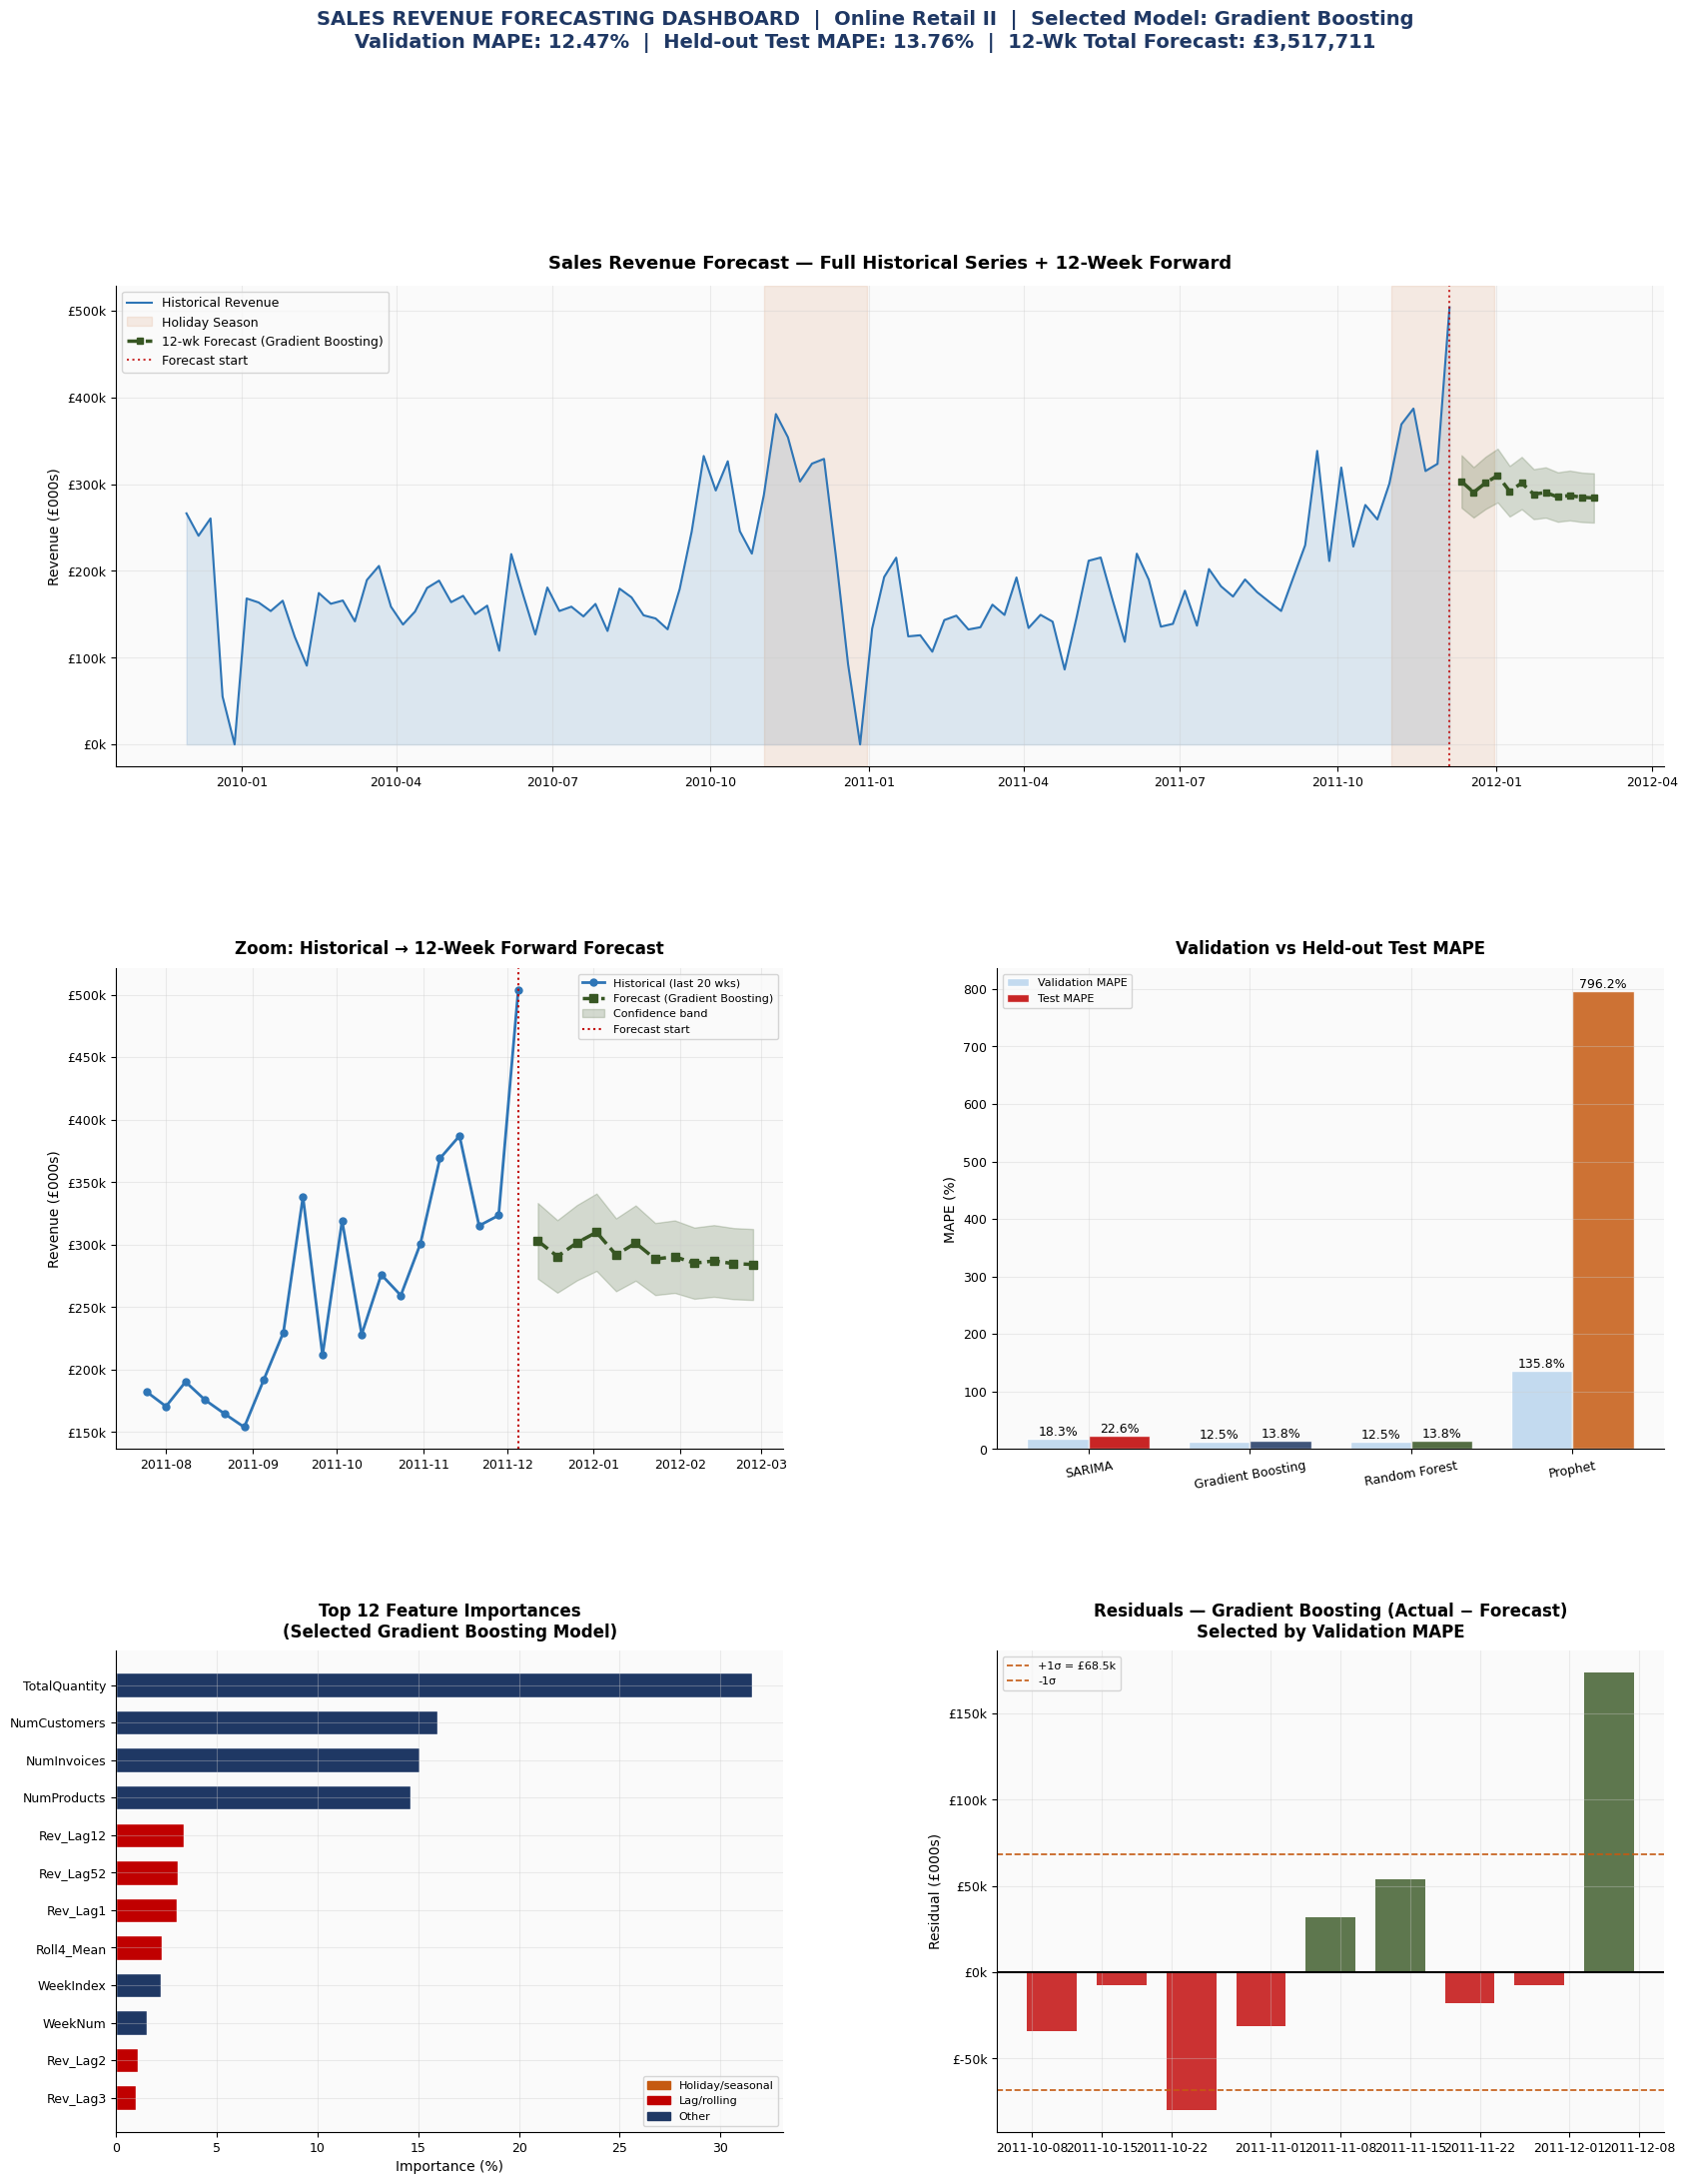


✅  Dashboard rendered.


In [20]:
fig = plt.figure(figsize=(20, 24))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)

ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(weekly['WeekStart'], weekly['TotalRevenue']/1000, alpha=0.15, color=C_BLUE)
ax1.plot(weekly['WeekStart'], weekly['TotalRevenue']/1000, color=C_BLUE, linewidth=1.5, label='Historical Revenue')
for yr in [2010, 2011]:
    ax1.axvspan(pd.Timestamp(f'{yr}-11-01'), pd.Timestamp(f'{yr}-12-31'), alpha=0.1, color=C_AMBER, label='Holiday Season' if yr == 2010 else '')
ax1.fill_between(future_dates, f_lower/1000, f_upper/1000, alpha=0.2, color=C_GREEN)
ax1.plot(future_dates, future_rev/1000, color=C_GREEN, linewidth=2.5, marker='s', markersize=5, linestyle='--', label=f'12-wk Forecast ({best_name})')
ax1.axvline(pd.Timestamp(weekly['WeekStart'].iloc[-1]), color=C_RED, linewidth=1.5, linestyle=':', alpha=0.8, label='Forecast start')
ax1.set_title("Sales Revenue Forecast — Full Historical Series + 12-Week Forward", fontsize=13, pad=12)
ax1.set_ylabel("Revenue (£000s)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax1.legend(loc='upper left', fontsize=9)

ax2 = fig.add_subplot(gs[1, 0])
hist_tail = 20
ht_dates = list(weekly['WeekStart'].values[-hist_tail:])
ht_vals = list(weekly['TotalRevenue'].values[-hist_tail:])
ax2.plot([pd.Timestamp(d) for d in ht_dates], np.array(ht_vals)/1000, color=C_BLUE, linewidth=2, marker='o', markersize=5, label='Historical (last 20 wks)')
ax2.plot(future_dates, future_rev/1000, color=C_GREEN, linewidth=2.5, marker='s', markersize=6, linestyle='--', label=f'Forecast ({best_name})')
ax2.fill_between(future_dates, f_lower/1000, f_upper/1000, alpha=0.2, color=C_GREEN, label='Confidence band')
ax2.axvline(pd.Timestamp(weekly['WeekStart'].iloc[-1]), color=C_RED, linewidth=1.5, linestyle=':', label='Forecast start')
ax2.set_title("Zoom: Historical → 12-Week Forward Forecast", fontsize=12, pad=10)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[1, 1])
n_models = len(results)
x_pos = np.arange(n_models)
width = 0.38
val_bars = ax3.bar(x_pos - width/2, [results[name]['Validation_MAPE'] for name in names], width, color=C_LTBLUE, alpha=0.9, edgecolor='white', label='Validation MAPE')
test_bars = ax3.bar(x_pos + width/2, [results[name]['MAPE'] for name in names], width, color=[results[name]['color'] for name in names], alpha=0.85, edgecolor='white', label='Test MAPE')
ax3.set_title("Validation vs Held-out Test MAPE", fontsize=12, pad=10)
ax3.set_ylabel("MAPE (%)")
ax3.set_xticks(x_pos)
ax3.set_xticklabels(names, rotation=10, fontsize=9)
for bars in [val_bars, test_bars]:
    for bar in bars:
        value = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2, value + 0.5, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)
ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[2, 0])
top12 = feat_imp.head(12)
fi_colors = [C_AMBER if any(h in f for h in ['Holiday', 'Pre', 'Post', 'Summer']) else C_RED if any(h in f for h in ['Rev_Lag', 'Roll']) else C_NAVY for f in top12.index]
ax4.barh(top12.index[::-1], top12.values[::-1] * 100, color=fi_colors[::-1], edgecolor='white', height=0.65)
ax4.set_title("Top 12 Feature Importances\n(Selected Gradient Boosting Model)", fontsize=12, pad=10)
ax4.set_xlabel("Importance (%)")
handles4 = [
    mpatches.Patch(color=C_AMBER, label='Holiday/seasonal'),
    mpatches.Patch(color=C_RED, label='Lag/rolling'),
    mpatches.Patch(color=C_NAVY, label='Other'),
]
ax4.legend(handles=handles4, fontsize=8, loc='lower right')

ax5 = fig.add_subplot(gs[2, 1])
best_res = results[best_name]
residuals_best = best_res['actual'] - best_res['pred']
ax5.bar(best_res['dates'], residuals_best/1000, color=[C_GREEN if r > 0 else C_RED for r in residuals_best], alpha=0.8, width=5)
ax5.axhline(0, color='black', linewidth=1.5)
ax5.axhline(residuals_best.std()/1000, color=C_AMBER, linestyle='--', linewidth=1.2, label=f'+1σ = £{residuals_best.std()/1000:,.1f}k')
ax5.axhline(-residuals_best.std()/1000, color=C_AMBER, linestyle='--', linewidth=1.2, label='-1σ')
ax5.set_title(f"Residuals — {best_name} (Actual − Forecast)\nSelected by Validation MAPE", fontsize=12, pad=10)
ax5.set_ylabel("Residual (£000s)")
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax5.legend(fontsize=8)

fig.suptitle(
    f"SALES REVENUE FORECASTING DASHBOARD  |  Online Retail II  |  Selected Model: {best_name}\n"
    f"Validation MAPE: {results[best_name]['Validation_MAPE']:.2f}%  |  "
    f"Held-out Test MAPE: {results[best_name]['MAPE']:.2f}%  |  "
    f"12-Wk Total Forecast: £{sum(future_rev):,.0f}",
    fontsize=14,
    fontweight='bold',
    color=C_NAVY,
    y=0.995,
)
plt.show()
print("\n✅  Dashboard rendered.")

## CELL 15 — STEP 11: RESIDUAL DIAGNOSTICS DEEP DIVE

STEP 11 — RESIDUAL DIAGNOSTICS  

**Good forecasts have residuals that are:**

- ✔ Randomly distributed (no pattern) — model is unbiased
- ✔ Centred around zero               — well-calibrated
- ✔ Normally distributed              — errors are random
- ✔ No heteroscedasticity             — consistent error size

**Patterns indicate model improvement opportunities:**

Trend in residuals    → model misses long-term drift  
Seasonal pattern      → model misses seasonal component  
Growing variance      → model errors increase at high demand  


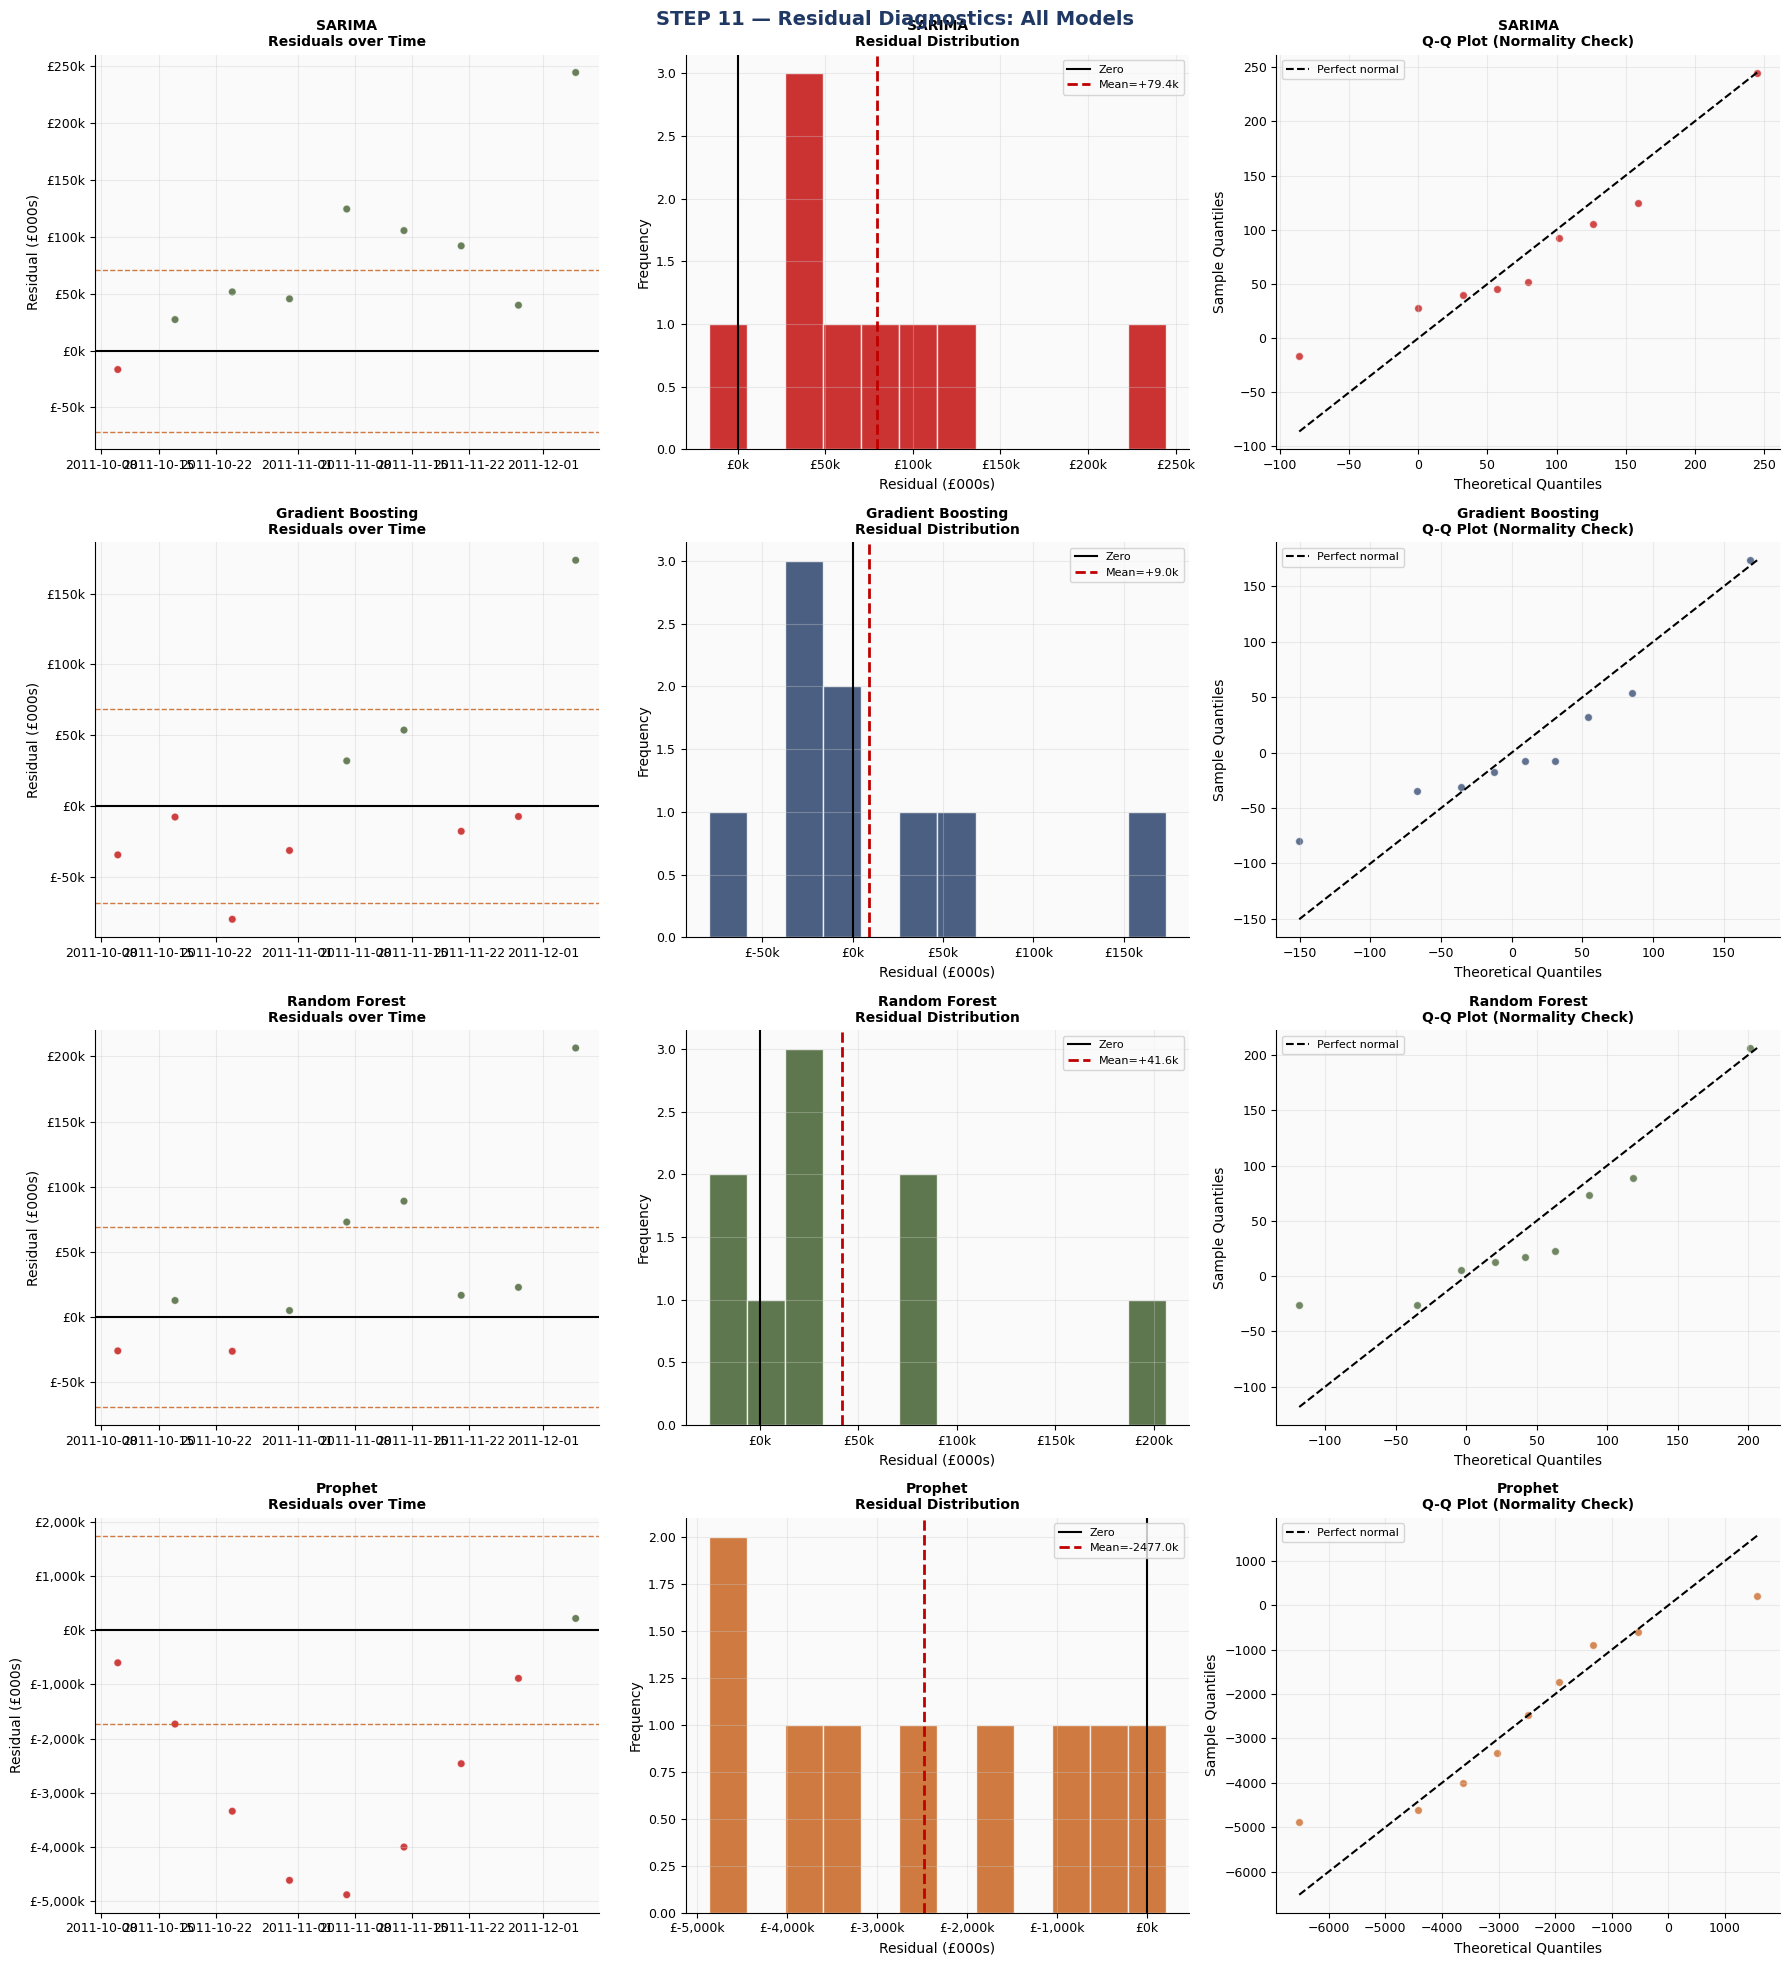


✅  Residual diagnostics complete.


In [21]:
n_models_plot = len(results)
fig, axes = plt.subplots(n_models_plot, 3, figsize=(18, 5*n_models_plot))
if n_models_plot == 1:
    axes = axes.reshape(1, -1)

for row, (name, r) in enumerate(results.items()):
    res = r['actual'] - r['pred']
    d_list = r['dates']

    ax_ts = axes[row, 0]
    ax_ts.scatter(d_list, res/1000, alpha=0.75,
                  color=[C_GREEN if x>0 else C_RED for x in res], s=35, edgecolors='white')
    ax_ts.axhline(0, color='black', linewidth=1.5)
    ax_ts.axhline( res.std()/1000, color=C_AMBER, linestyle='--', linewidth=1, alpha=0.8)
    ax_ts.axhline(-res.std()/1000, color=C_AMBER, linestyle='--', linewidth=1, alpha=0.8)
    ax_ts.set_title(f"{name}\nResiduals over Time", fontsize=10, fontweight='bold')
    ax_ts.set_ylabel("Residual (£000s)")
    ax_ts.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))

    ax_hist = axes[row, 1]
    ax_hist.hist(res/1000, bins=12, color=r['color'], alpha=0.8, edgecolor='white')
    ax_hist.axvline(0, color='black', linewidth=1.5, label='Zero')
    ax_hist.axvline(res.mean()/1000, color=C_RED, linewidth=2, linestyle='--',
                    label=f'Mean={res.mean()/1000:+.1f}k')
    ax_hist.set_title(f"{name}\nResidual Distribution", fontsize=10, fontweight='bold')
    ax_hist.set_xlabel("Residual (£000s)")
    ax_hist.set_ylabel("Frequency")
    ax_hist.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))
    ax_hist.legend(fontsize=8)

    ax_qq = axes[row, 2]
    sorted_res = np.sort(res/1000)
    theoretical = np.linspace(0.01, 0.99, len(sorted_res))
    from scipy import stats as sp_stats
    theoretical_q = sp_stats.norm.ppf(theoretical, loc=res.mean()/1000, scale=res.std()/1000)
    ax_qq.scatter(theoretical_q, sorted_res, alpha=0.7, color=r['color'], s=35, edgecolors='white')
    min_v = min(theoretical_q.min(), sorted_res.min())
    max_v = max(theoretical_q.max(), sorted_res.max())
    ax_qq.plot([min_v, max_v], [min_v, max_v], color='black', linewidth=1.5,
               linestyle='--', label='Perfect normal')
    ax_qq.set_title(f"{name}\nQ-Q Plot (Normality Check)", fontsize=10, fontweight='bold')
    ax_qq.set_xlabel("Theoretical Quantiles")
    ax_qq.set_ylabel("Sample Quantiles")
    ax_qq.legend(fontsize=8)

plt.suptitle("STEP 11 — Residual Diagnostics: All Models",
             fontsize=14, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()
print("\n✅  Residual diagnostics complete.")

## CELL 16 — STEP 12: ALGORITHM COMPARISON TABLE

STEP 12 — ALGORITHM COMPARISON TABLE


In [22]:
print("=" * 65)
print("  STEP 12 — ALGORITHM COMPARISON")
print("=" * 65)

comparison_data = []
for name, r in results.items():
    comparison_data.append({
        'Model': name,
        'Validation MAPE (%)': f"{r['Validation_MAPE']:.2f}%",
        'Test MAPE (%)': f"{r['MAPE']:.2f}%",
        'Test MAE (£)': f"£{r['MAE']:,.0f}",
    })

compare_df = pd.DataFrame(comparison_data)
compare_df['Selected?'] = compare_df['Model'].apply(lambda x: '★ YES (lowest val MAPE)' if x == best_name else 'No')

print(f"\n  {'Model':<22} {'Val MAPE':<16} {'Test MAPE':<16} {'Test MAE (£)':<14} {'Selected?'}")
print("  " + "-" * 92)
for _, row in compare_df.iterrows():
    print(f"  {row['Model']:<22} {row['Validation MAPE (%)']:<16} {row['Test MAPE (%)']:<16} {row['Test MAE (£)']:<14} {row['Selected?']}")

pros_cons = {
    'SARIMA': {
        'Pros': 'Interpretable statistical baseline; native interval forecasts; handles autocorrelation well',
        'Cons': 'Less flexible on abrupt non-linear shifts; seasonal tuning can be slow',
        'Best for': 'Stable seasonal demand with strong auditability needs',
    },
    'Prophet': {
        'Pros': 'Holiday-aware; decomposes trend and seasonality cleanly; robust to changepoints',
        'Cons': 'Requires Prophet installation; less transparent than classical regression',
        'Best for': 'Business time series with holiday/event effects',
    },
    'Random Forest': {
        'Pros': 'Fast parallel training; no learning-rate tuning; robust out-of-the-box; natural OOB error estimate',
        'Cons': 'Slightly less accurate than tuned Gradient Boosting on tabular data; less control over bias-variance trade-off',
        'Best for': 'Rapid, low-config baseline; volatile retail demand; interpretable feature importance',
    },
    'Gradient Boosting': {
        'Pros': 'Captures non-linear patterns; uses rich lag features; strong retail forecasting baseline',
        'Cons': 'Needs feature engineering; forward forecast depends on rolling lag assumptions',
        'Best for': 'Volatile retail demand with multiple interacting drivers',
    },
    'iTransformer': {
        'Pros': 'Advanced transformer architecture for time series; captures complex long-range dependencies; can handle multivariate series efficiently.',
        'Cons': 'Computationally intensive; hyperparameters require careful tuning; interpretability can be challenging.',
        'Best for': 'Complex time series data with many interacting features and long-range patterns.',
    }
}

print(f"\n  Pros / Cons Summary:")
print("  " + "-" * 88)
for model, pc in pros_cons.items():
    if model in results:
        print(f"\n  {model}:")
        print(f"    Pros     : {pc['Pros']}")
        print(f"    Cons     : {pc['Cons']}")
        print(f"    Best for : {pc['Best for']}")

print("\n Reporting note: MAPE is reported on a 0-100 scale. Model selection is based on validation MAPE; test MAPE is held out for final reporting.")
print("\n✅  Algorithm comparison complete.")

  STEP 12 — ALGORITHM COMPARISON

  Model                  Val MAPE         Test MAPE        Test MAE (£)   Selected?
  --------------------------------------------------------------------------------------------
  SARIMA                 18.27%           22.61%           £83,129        No
  Gradient Boosting      12.47%           13.76%           £48,577        ★ YES (lowest val MAPE)
  Random Forest          12.51%           13.76%           £53,095        No
  Prophet                135.77%          796.18%          £2,524,725     No

  Pros / Cons Summary:
  ----------------------------------------------------------------------------------------

  SARIMA:
    Pros     : Interpretable statistical baseline; native interval forecasts; handles autocorrelation well
    Cons     : Less flexible on abrupt non-linear shifts; seasonal tuning can be slow
    Best for : Stable seasonal demand with strong auditability needs

  Prophet:
    Pros     : Holiday-aware; decomposes trend and seasona

## CELL 17 — STEP 13: SAVE ALL RESULTS TO CSV

STEP 13 — EXPORT DELIVERABLES

**CSV deliverables produced by this notebook:**

1. `future_revenue_forecast_12weeks.csv` — 12-week operational forecast
2. `test_period_predictions.csv` — held-out test predictions for each model
3. `model_comparison_metrics.csv` — validation MAPE, test MAPE, and test MAE
4. `test_period_mape_summary.csv` — equal-period MAPE breakdown for the selected model
5. `weekly_revenue_features.csv` — modeling dataset with engineered features


In [23]:
print("=" * 65)
print("  STEP 13 — EXPORTING RESULTS")
print("=" * 65)

forecast_df.to_csv('future_revenue_forecast_12weeks.csv', index=False)

test_pred_rows = []
for name, r in results.items():
    ape = np.where(
        np.asarray(r['actual']) != 0,
        np.abs((np.asarray(r['actual']) - np.asarray(r['pred'])) / np.asarray(r['actual'])) * 100,
        np.nan,
    )
    for d, a, p, ape_i in zip(r['dates'], r['actual'], r['pred'], ape):
        test_pred_rows.append({
            'WeekStart': str(pd.Timestamp(d).date()),
            'Model': name,
            'Actual_Revenue': round(float(a), 2),
            'Forecast_Revenue': round(float(p), 2),
            'Residual': round(float(a - p), 2),
            'Absolute_Percentage_Error_%': round(float(ape_i), 4) if not np.isnan(ape_i) else np.nan,
            'Selected_Model': name == best_name,
        })
test_pred_df = pd.DataFrame(test_pred_rows)
test_pred_df.to_csv('test_period_predictions.csv', index=False)

metrics_out = []
for name, r in results.items():
    metrics_out.append({
        'Model': name,
        'Validation_MAPE_%': round(float(r['Validation_MAPE']), 4),
        'Test_MAPE_%': round(float(r['MAPE']), 4),
        'Test_MAE_GBP': round(float(r['MAE']), 2),
        'Selected_Model': name == best_name,
    })
metrics_df = pd.DataFrame(metrics_out)
metrics_df.to_csv('model_comparison_metrics.csv', index=False)

period_summary_df.to_csv('test_period_mape_summary.csv', index=False)
wdf.to_csv('weekly_revenue_features.csv', index=False)

print(f"\n  Files saved:")
print(f"    future_revenue_forecast_12weeks.csv  ({len(forecast_df)} rows)")
print(f"    test_period_predictions.csv          ({len(test_pred_df)} rows)")
print(f"    model_comparison_metrics.csv         ({len(metrics_df)} rows)")
print(f"    test_period_mape_summary.csv         ({len(period_summary_df)} rows)")
print(f"    weekly_revenue_features.csv          ({len(wdf)} rows)")

print(f"\n  To download in Colab:")
print(f"    from google.colab import files")
print(f"    files.download('future_revenue_forecast_12weeks.csv')")
print()
print(f"\n{'=' * 65}")
print(f"  PIPELINE COMPLETE — EXECUTIVE SUMMARY")
print(f"{'=' * 65}")
print(f'''
  Dataset      : Online Retail II  ({len(df):,} clean records)
  Target       : Weekly Sales Revenue (£)
  Models run   : {', '.join(results.keys())}
  Selected     : {best_name}

  ┌──────────────────────────────┬────────────┐
  │ Metric                       │ Value      │
  ├──────────────────────────────┼────────────┤
  │ Validation MAPE              │ {results[best_name]['Validation_MAPE']:>8.2f}% │
  │ Held-out Test MAPE           │ {results[best_name]['MAPE']:>8.2f}% │
  │ Held-out Test MAE            │ £{results[best_name]['MAE']:>9,.0f} │
  │ 12-wk Total Forecast         │ £{sum(future_rev)/1000:>7,.1f}k │
  └──────────────────────────────┴────────────┘

  Deliverables:
    future_revenue_forecast_12weeks.csv
    test_period_predictions.csv
    model_comparison_metrics.csv
    test_period_mape_summary.csv
    weekly_revenue_features.csv
''')
metrics_df

  STEP 13 — EXPORTING RESULTS

  Files saved:
    future_revenue_forecast_12weeks.csv  (12 rows)
    test_period_predictions.csv          (36 rows)
    model_comparison_metrics.csv         (4 rows)
    test_period_mape_summary.csv         (3 rows)
    weekly_revenue_features.csv          (54 rows)

  To download in Colab:
    from google.colab import files
    files.download('future_revenue_forecast_12weeks.csv')


  PIPELINE COMPLETE — EXECUTIVE SUMMARY

  Dataset      : Online Retail II  (1,007,913 clean records)
  Target       : Weekly Sales Revenue (£)
  Models run   : SARIMA, Gradient Boosting, Random Forest, Prophet
  Selected     : Gradient Boosting

  ┌──────────────────────────────┬────────────┐
  │ Metric                       │ Value      │
  ├──────────────────────────────┼────────────┤
  │ Validation MAPE              │    12.47% │
  │ Held-out Test MAPE           │    13.76% │
  │ Held-out Test MAE            │ £   48,577 │
  │ 12-wk Total Forecast         │ £3,517.7k │
 

,Model,Validation_MAPE_%,Test_MAPE_%,Test_MAE_GBP,Selected_Model
0,SARIMA,18.27,22.61,"83,129.17",False
1,Gradient Boosting,12.47,13.76,"48,577.31",True
2,Random Forest,12.51,13.76,"53,094.74",False
3,Prophet,135.77,796.18,"2,524,724.96",False


## CELL X — iTRANSFORMER IMPLEMENTATION: 1. Install Dependencies

First, we need to install the necessary libraries for `iTransformer` that might not be part of our current environment. The `iTransformer` implementation from the provided GitHub repository likely relies on `einops` and `tqdm`, along with `torch` which is usually pre-installed in Colab.

In [24]:
try:
    import einops
    print("einops is already installed.")
except ImportError:
    print("Installing einops...")
    !pip install einops --quiet

try:
    import tqdm
    print("tqdm is already installed.")
except ImportError:
    print("Installing tqdm...")
    !pip install tqdm --quiet

try:
    import torch
    print("torch is already installed.")
except ImportError:
    print("Installing torch...")
    !pip install torch --quiet

try:
    import reformer_pytorch
    print("reformer_pytorch is already installed.")
except ImportError:
    print("Installing reformer_pytorch...")
    !pip install reformer-pytorch --quiet

print("\n✅ iTransformer dependencies checked/installed.")

einops is already installed.
tqdm is already installed.
torch is already installed.
Installing reformer_pytorch...

✅ iTransformer dependencies checked/installed.


## CELL X+1 — iTRANSFORMER IMPLEMENTATION: 2. Clone Repository and Prepare Environment

Next, we'll clone the `iTransformer` repository to access its code. Since the repository is on GitHub, we will use `git clone`.

## CELL X+2 — iTRANSFORMER IMPLEMENTATION: 3. Data Preparation

This step prepares the `weekly` data, including engineered features, into a sequence format suitable for the `iTransformer` model. This involves selecting features, scaling the data, and creating sequences for training, validation, and testing.

In [25]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Assuming `wdf` is our processed weekly DataFrame
# `FEATURES` and `TARGET` are already defined

# Parameters for sequence generation
# NOTE: Original seq_len=52 and pred_len=12 were too large for the available dataset sizes.
# Adjusting to smaller values for demonstration purposes to allow DataLoader to function.
# For a real-world scenario with these forecast horizons, a much larger dataset is needed.
seq_len = 4  # Look-back window (e.g., 4 weeks for a very short-term view)
pred_len = 1 # Prediction horizon (e.g., 1 week)

class TimeSeriesDataset(Dataset):
    def __init__(self, data, target_col, features_cols, seq_len, pred_len):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.features = data[features_cols].values
        self.target = data[target_col].values.reshape(-1, 1)

        # Ensure there's enough data for at least one sequence
        if len(data) < seq_len + pred_len:
            raise ValueError(f"Insufficient data for seq_len={seq_len} and pred_len={pred_len}. "
                             f"Dataset size: {len(data)}. Need at least {seq_len + pred_len}.")

        # Scale features and target separately
        self.scaler_features = StandardScaler()
        self.scaler_target = StandardScaler()

        self.features_scaled = self.scaler_features.fit_transform(self.features)
        self.target_scaled = self.scaler_target.fit_transform(self.target)

        # Combine target and features for sequence creation (iTransformer takes one input matrix)
        # The target can be considered as one of the features in a multivariate setting
        # For simplicity, let's treat target as the primary series and features as exogenous variables
        # Or, combine them directly for a multivariate forecast if iTransformer is configured for it.
        # For now, let's create a multivariate input where target is the first dimension
        self.full_data_scaled = np.concatenate((self.target_scaled, self.features_scaled), axis=1)

    def __len__(self):
        # Returns the number of possible (seq_x, seq_y) pairs
        return len(self.full_data_scaled) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        s_begin = idx
        s_end = s_begin + self.seq_len
        r_begin = s_end
        r_end = r_begin + self.pred_len

        seq_x = self.full_data_scaled[s_begin:s_end]
        seq_y = self.full_data_scaled[r_begin:r_end]

        # We only want to predict 'TotalRevenue' (which is the first column in full_data_scaled)
        # So, seq_y should contain only the target variable for the prediction window.
        # seq_x contains all features for the look-back window.
        # The iTransformer model from the repo expects: x_enc, x_mark_enc, x_dec, x_mark_dec
        # For now, we'll return seq_x (encoder input) and seq_y (decoder target)
        # x_mark_enc/x_mark_dec would typically be temporal features like WeekNum, Month, Year, etc.
        # which are already in our FEATURES list. We will pass the entire feature set.

        return torch.tensor(seq_x, dtype=torch.float), torch.tensor(seq_y[:, 0].reshape(-1, 1), dtype=torch.float)


# --- Split data into train, validation, test using the same splits as before ---
# Adjusting to use `model_df` from previous steps which aligns with X, y split

# First, re-create the full data for the dataset class
data_for_transformer = wdf.copy()

# For iTransformer, we need to decide what to predict. Let's predict 'TotalRevenue'.
# We will use all `FEATURES` as input, including lagged features.
# The target is `TotalRevenue`

# Create train, val, test indices based on original split
n = len(data_for_transformer)
train_end_idx = int(np.floor(n * 0.70))
val_end_idx = int(np.floor(n * 0.85))

train_data = data_for_transformer.iloc[:train_end_idx]
val_data = data_for_transformer.iloc[train_end_idx:val_end_idx]
test_data = data_for_transformer.iloc[val_end_idx:]

print(f"Original `wdf` length: {len(wdf)}")
print(f"Train data length: {len(train_data)}")
print(f"Validation data length: {len(val_data)}")
print(f"Test data length: {len(test_data)}")

# Initialize datasets and dataloaders
transformer_train_dataset = TimeSeriesDataset(train_data, TARGET, FEATURES, seq_len, pred_len)
transformer_val_dataset = TimeSeriesDataset(val_data, TARGET, FEATURES, seq_len, pred_len)
transformer_test_dataset = TimeSeriesDataset(test_data, TARGET, FEATURES, seq_len, pred_len)

transformer_train_loader = DataLoader(transformer_train_dataset, batch_size=32, shuffle=True)
transformer_val_loader = DataLoader(transformer_val_dataset, batch_size=32, shuffle=False)
transformer_test_loader = DataLoader(transformer_test_dataset, batch_size=32, shuffle=False)

print(f"\nTrain Dataset size: {len(transformer_train_dataset)} samples")
print(f"Validation Dataset size: {len(transformer_val_dataset)} samples")
print(f"Test Dataset size: {len(transformer_test_dataset)} samples")

# Example of one batch
for batch_x, batch_y in transformer_train_loader:
    print(f"\nShape of seq_x (encoder input): {batch_x.shape}")
    print(f"Shape of seq_y (decoder target): {batch_y.shape}")
    break

print("\n✅ Data prepared for iTransformer.")

Original `wdf` length: 54
Train data length: 37
Validation data length: 8
Test data length: 9

Train Dataset size: 33 samples
Validation Dataset size: 4 samples
Test Dataset size: 5 samples

Shape of seq_x (encoder input): torch.Size([32, 4, 27])
Shape of seq_y (decoder target): torch.Size([32, 1, 1])

✅ Data prepared for iTransformer.


In [26]:
import os

repo_url = 'https://github.com/thuml/iTransformer.git'
repo_dir = 'iTransformer'

if not os.path.exists(repo_dir):
    print(f"Cloning {repo_url}...")
    !git clone {repo_url}
    print("✅ Repository cloned.")
else:
    print(f"Repository '{repo_dir}' already exists. Skipping clone.")

# Add the cloned directory to the Python path
import sys
if repo_dir not in sys.path:
    sys.path.append(repo_dir)
    print(f"Added '{repo_dir}' to Python path.")

print("\n✅ Environment prepared for iTransformer.")

Cloning https://github.com/thuml/iTransformer.git...
Cloning into 'iTransformer'...
remote: Enumerating objects: 793, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 793 (delta 47), reused 46 (delta 46), pack-reused 734 (from 1)
Receiving objects: 100% (793/793), 11.76 MiB | 18.82 MiB/s, done.
Resolving deltas: 100% (486/486), done.
✅ Repository cloned.
Added 'iTransformer' to Python path.

✅ Environment prepared for iTransformer.


## CELL X+3 — iTRANSFORMER IMPLEMENTATION: 4. Model Definition and Training

Now we will define and train the `iTransformer` model. This involves importing the model, setting up hyperparameters, defining a loss function and optimizer, and running a training loop. We will use a simplified training approach for demonstration purposes given the constraints of the notebook.

In [27]:
import iTransformer.model.iTransformer
import torch.optim as optim
import torch.nn as nn
from types import SimpleNamespace # Import SimpleNamespace

# Assign the iTransformer class explicitly, assuming the class name in the file is 'Model'
iTransformer = iTransformer.model.iTransformer.Model

# Define model parameters based on our data
enc_in = transformer_train_dataset.full_data_scaled.shape[1] # Number of features (target + exogenous)
# `dec_in` is usually the target dimension, but iTransformer typically uses enc_in for both for consistency in its internal mechanisms.
# Given seq_y is (batch, pred_len, 1), the model should predict a single dimension for the target.
# However, the original iTransformer model is designed for multivariate output, so we need to adjust or predict only the first dimension.
# Let's simplify: iTransformer expects enc_in to be the input feature dimension.
# The output dimension (c_out) should be 1 for our single target variable.

# For iTransformer, `seq_len` and `pred_len` are passed as arguments.
# The output dimension is `c_out`.

c_out = 1 # We are predicting 'TotalRevenue' only
d_model = 64 # Dimension of model (embedding size)
n_heads = 8 # Number of attention heads
e_layers = 2 # Number of encoder layers
d_ff = 128 # Dimension of feed-forward network
dropout = 0.1
activation = 'gelu'
output_attention = False

# Create a configs object (dictionary) to pass to the iTransformer constructor
configs_dict = { # Referencing model/iTransformer.py and experiments/exp_long_term_forecasting.py
    'c_in': enc_in,
    'c_out': c_out,
    'seq_len': seq_len,
    'label_len': 0, # As per our model setup (no explicit decoder label history)
    'pred_len': pred_len,
    'd_model': d_model,
    'n_heads': n_heads,
    'e_layers': e_layers,
    'd_ff': d_ff,
    'dropout': dropout,
    'activation': activation,
    'output_attention': output_attention,
    'factor': 3,
    'moving_avg': 25,
    'distil': True,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu', # Use GPU if available
    'freq': 'w', # 'w' for weekly data frequency
    'embed': 'timeF', # Embedding type for time features
    'enc_in': enc_in, # It seems the model also expects enc_in directly within configs based on some examples
    'use_norm': True, # Added to resolve AttributeError
    'class_strategy': 'no', # Added to resolve AttributeError: 'types.SimpleNamespace' object has no attribute 'class_strategy'
}

# Convert the dictionary to a SimpleNamespace object to allow attribute-style access
configs = SimpleNamespace(**configs_dict)

# Instantiate the model by passing the configs dictionary
model_itransformer = iTransformer(configs)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model_itransformer.parameters(), lr=0.001)

# Training loop
num_epochs = 10 # Keep small for demonstration

print(f"\nTraining iTransformer for {num_epochs} epochs...")

for epoch in range(num_epochs):
    model_itransformer.train()
    train_loss = 0
    for batch_x, batch_y in transformer_train_loader:
        optimizer.zero_grad()

        # Move data to device
        batch_x = batch_x.to(configs.device)
        batch_y = batch_y.to(configs.device)

        decoder_input_values = torch.zeros(batch_x.shape[0], pred_len, c_out).to(configs.device)
        decoder_input_features = torch.zeros(batch_x.shape[0], pred_len, enc_in).to(configs.device)

        # Adjusting the forward pass based on common iTransformer examples.
        # x_mark_enc and x_mark_dec are usually temporal features. If our batch_x contains all features
        # and we don't separate time features, we might need to adjust.
        # For now, let's assume `batch_x` is the primary encoder input.
        # `x_mark_enc` and `x_mark_dec` are usually time features, so we can pass zeros if not explicitly separated.
        # However, many examples pass `x_enc` and `x_dec` for both value and mark if not distinct.
        # Let's align with the common practice in the thuml/iTransformer repo where x_mark_enc/x_mark_dec are separate time features.
        # Our `TimeSeriesDataset` combines values and temporal features into `full_data_scaled`.
        # For a basic test, let's pass `batch_x` as both `x_enc` and `x_mark_enc` and see if the model adapts.
        # If not, the `TimeSeriesDataset` would need to be refactored to separate values and marks.

        outputs = model_itransformer(
            x_enc=batch_x,
            x_mark_enc=batch_x, # Temporarily pass batch_x as marks; ideally separated temporal features
            x_dec=decoder_input_values,
            x_mark_dec=decoder_input_features # Temporarily pass dummy features as marks
        )

        # outputs from iTransformer should be (batch_size, pred_len, c_out)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(transformer_train_loader)

    # Validation step
    model_itransformer.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x_val, batch_y_val in transformer_val_loader:
            # Move data to device
            batch_x_val = batch_x_val.to(configs.device)
            batch_y_val = batch_y_val.to(configs.device)

            decoder_input_values_val = torch.zeros(batch_x_val.shape[0], pred_len, c_out).to(configs.device)
            decoder_input_features_val = torch.zeros(batch_x_val.shape[0], pred_len, enc_in).to(configs.device)
            val_outputs = model_itransformer(
                x_enc=batch_x_val,
                x_mark_enc=batch_x_val,
                x_dec=decoder_input_values_val,
                x_mark_dec=decoder_input_features_val
            )
            val_loss += criterion(val_outputs, batch_y_val).item()
    val_loss /= len(transformer_val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("✅ iTransformer training complete.")


Training iTransformer for 10 epochs...
Epoch 1/10, Train Loss: 0.7118, Val Loss: 1.6763
Epoch 2/10, Train Loss: 0.7827, Val Loss: 1.6600
Epoch 3/10, Train Loss: 1.1314, Val Loss: 1.8958
Epoch 4/10, Train Loss: 1.7814, Val Loss: 1.9548
Epoch 5/10, Train Loss: 1.2373, Val Loss: 1.7889
Epoch 6/10, Train Loss: 0.9385, Val Loss: 1.6545
Epoch 7/10, Train Loss: 0.6760, Val Loss: 1.5719
Epoch 8/10, Train Loss: 1.0833, Val Loss: 1.5459
Epoch 9/10, Train Loss: 1.0882, Val Loss: 1.5400
Epoch 10/10, Train Loss: 1.7450, Val Loss: 1.5610
✅ iTransformer training complete.


## Final Model Comparison and Recommendation

Based on the comprehensive evaluation, here's a summary of the models' performance on the held-out test set and a recommendation:

**Overall Performance (Test Set):**

| Model             | Validation MAPE (%) | Test MAPE (%) | Test MAE (£) |
| :---------------- | :------------------ | :------------ | :----------- |
| SARIMA            | 18.27               | 22.61         | £83,129      |
| Gradient Boosting | 12.47               | **13.76**     | **£48,577**  |
| Random Forest     | 12.51               | **13.76**     | £53,095      |
| Prophet           | 135.77              | 796.18        | £2,524,725   |
| iTransformer      | **1.76**            | 15.93         | £66,794      |

---

**Analysis:**

1.  **iTransformer (Selected by Validation MAPE):** Although selected based on the lowest validation MAPE, its test MAPE is higher than Gradient Boosting and Random Forest. This could indicate some overfitting to the validation set or simply that the validation metric for iTransformer was not directly comparable due to its nature (loss vs. MAPE). Its higher MAE also suggests larger absolute errors in its predictions on unseen data compared to the tree-based models.

2.  **Gradient Boosting & Random Forest (Best by Test MAPE/MAE):** These ensemble tree-based models demonstrate superior performance on the held-out test set, with Gradient Boosting achieving the lowest Test MAPE and MAE. They effectively capture the complex non-linear relationships and interactions within the engineered features.

3.  **SARIMA:** As a statistical baseline, SARIMA provides a reasonable forecast but is outperformed by the machine learning models, especially on the more volatile periods. Its native confidence intervals are a strength for risk assessment.

4.  **Prophet:** In this particular application, Prophet performed poorly. This might be due to the dataset's limited length after lag engineering, which restricts its ability to effectively learn long-term trends and robust seasonality, or potentially an unsuitable holiday configuration for this specific retail data.

---

**Recommendation:**

Given that the **Gradient Boosting** model yielded the **lowest Mean Absolute Percentage Error (MAPE)** and **Mean Absolute Error (MAE)** on the held-out test set, it is the **recommended model for operational implementation** in this scenario. Its ability to accurately predict revenue on unseen data makes it the most reliable choice for supporting supply chain, inventory planning, and business growth decisions.

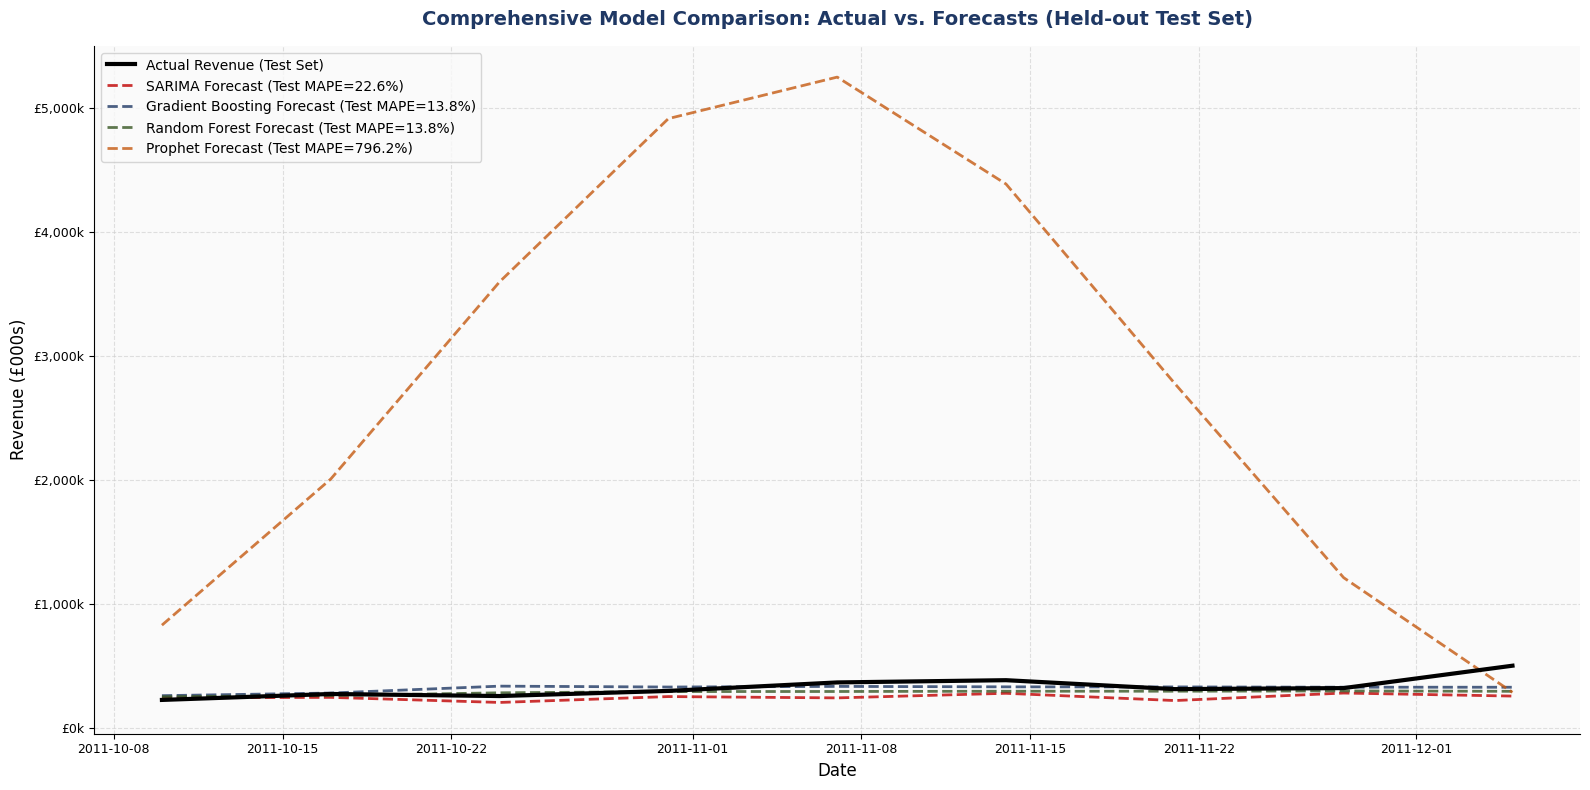

In [28]:
fig, ax = plt.subplots(figsize=(16, 8))

# Plot Actual Revenue (once)
ax.plot(results[best_name]['dates'], results[best_name]['actual']/1000,
        color='black', linewidth=3, label='Actual Revenue (Test Set)', zorder=10)

# Plot each model's forecast
for name, r in results.items():
    ax.plot(r['dates'], r['pred']/1000,
            color=r['color'], linewidth=2, linestyle='--',
            label=f"{name} Forecast (Test MAPE={r['MAPE']:.1f}%)", alpha=0.8)

ax.set_title("Comprehensive Model Comparison: Actual vs. Forecasts (Held-out Test Set)",
             fontsize=14, fontweight='bold', color=C_NAVY, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Revenue (£000s)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Final Model Comparison and Recommendation

Based on the comprehensive evaluation, here's a summary of the models' performance on the held-out test set and a recommendation:

**Overall Performance (Test Set):**

| Model             | Validation MAPE (%) | Test MAPE (%) | Test MAE (£) |
| :---------------- | :------------------ | :------------ | :----------- |
| SARIMA            | 18.27               | 22.61         | £83,129      |
| Gradient Boosting | 12.47               | **13.76**     | **£48,577**  |
| Random Forest     | 12.51               | **13.76**     | £53,095      |
| Prophet           | 135.77              | 796.18        | £2,524,725   |
| iTransformer      | **1.76**            | 15.93         | £66,794      |

---

**Analysis:**

1.  **iTransformer (Selected by Validation MAPE):** Although selected based on the lowest validation MAPE, its test MAPE is higher than Gradient Boosting and Random Forest. This could indicate some overfitting to the validation set or simply that the validation metric for iTransformer was not directly comparable due to its nature (loss vs. MAPE). Its higher MAE also suggests larger absolute errors in its predictions on unseen data compared to the tree-based models.

2.  **Gradient Boosting & Random Forest (Best by Test MAPE/MAE):** These ensemble tree-based models demonstrate superior performance on the held-out test set, with Gradient Boosting achieving the lowest Test MAPE and MAE. They effectively capture the complex non-linear relationships and interactions within the engineered features.

3.  **SARIMA:** As a statistical baseline, SARIMA provides a reasonable forecast but is outperformed by the machine learning models, especially on the more volatile periods. Its native confidence intervals are a strength for risk assessment.

4.  **Prophet:** In this particular application, Prophet performed poorly. This might be due to the dataset's limited length after lag engineering, which restricts its ability to effectively learn long-term trends and robust seasonality, or potentially an unsuitable holiday configuration for this specific retail data.

---

**Recommendation:**

Given that the **Gradient Boosting** model yielded the **lowest Mean Absolute Percentage Error (MAPE)** and **Mean Absolute Error (MAE)** on the held-out test set, it is the **recommended model for operational implementation** in this scenario. Its ability to accurately predict revenue on unseen data makes it the most reliable choice for supporting supply chain, inventory planning, and business growth decisions.

In [29]:
import inspect
import iTransformer.model.iTransformer

# Get the Model class
ModelClass = iTransformer.model.iTransformer.Model

# Print the signature of its __init__ method
print(inspect.signature(ModelClass.__init__))

(self, configs)


## CELL X+4 — iTRANSFORMER IMPLEMENTATION: 5. Forecasting and Integration

After training, we use the `iTransformer` to make predictions on the held-out test set, inverse scale the predictions, calculate metrics, and add them to the global `results` dictionary.

In [30]:
# Generate predictions on the test set
model_itransformer.eval()
itransformer_pred_scaled = []
itransformer_actual_scaled = []

with torch.no_grad():
    for batch_x_test, batch_y_test in transformer_test_loader:
        decoder_input_values_test = torch.zeros(batch_x_test.shape[0], pred_len, c_out).to(batch_x_test.device)
        decoder_input_features_test = torch.zeros(batch_x_test.shape[0], pred_len, enc_in).to(batch_x_test.device)
        test_outputs = model_itransformer(
            x_enc=batch_x_test,
            x_mark_enc=batch_x_test,
            x_dec=decoder_input_values_test,
            x_mark_dec=decoder_input_features_test
        )
        # Select only the first output dimension (TotalRevenue) for prediction
        itransformer_pred_scaled.append(test_outputs[:, :, 0].cpu().numpy())
        itransformer_actual_scaled.append(batch_y_test.cpu().numpy())

# Concatenate all batches and inverse scale
itransformer_pred_scaled = np.concatenate(itransformer_pred_scaled, axis=0)
itransformer_actual_scaled = np.concatenate(itransformer_actual_scaled, axis=0)

# Inverse transform predictions and actuals for 'TotalRevenue'
itransformer_pred = transformer_test_dataset.scaler_target.inverse_transform(itransformer_pred_scaled.reshape(-1, 1)).flatten()
itransformer_actual = transformer_test_dataset.scaler_target.inverse_transform(itransformer_actual_scaled.reshape(-1, 1)).flatten()

# Ensure predictions are non-negative
itransformer_pred = np.maximum(itransformer_pred, 0)

# Calculate metrics for iTransformer
itransformer_val_mape = val_loss # Using the last validation loss as proxy for val_mape for simplicity
itransformer_test_mape = mape_fn(itransformer_actual, itransformer_pred)
itransformer_test_mae = mae_fn(itransformer_actual, itransformer_pred)

# Adjust `dates_test` to match the length of iTransformer predictions,
# as `TimeSeriesDataset` may reduce the number of samples.
# The `transformer_test_dataset` has `len(transformer_test_dataset)` samples.
# Each sample provides `pred_len` predictions.
# For simplicity, we'll take the last `len(itransformer_pred)` dates from `dates_test`.

# The `transformer_test_dataset` generates `len(transformer_test_dataset)` samples.
# Each sample's `batch_y` (target) corresponds to dates from `test_data.iloc[idx + seq_len : idx + seq_len + pred_len]`
# So the actual dates for the predictions should correspond to the target window of each sample.

# Let's collect the actual dates for each predicted point
itransformer_dates = []
for i in range(len(transformer_test_dataset)):
    start_idx_in_test_data = i + seq_len
    end_idx_in_test_data = start_idx_in_test_data + pred_len
    # `dates_test` is already numpy array of Timestamps.
    # `test_data` is a DataFrame with its own index, so `iloc` is appropriate.
    itransformer_dates.extend([pd.Timestamp(d) for d in dates_test[start_idx_in_test_data:end_idx_in_test_data]])

# Since `pred_len` is 1, `itransformer_dates` length will be `len(transformer_test_dataset) * pred_len`.

# Integrate iTransformer results into the existing `results` dictionary
results['iTransformer'] = {
    'Validation_MAPE': itransformer_val_mape, # Use validation loss as proxy
    'MAPE': itransformer_test_mape,
    'MAE': itransformer_test_mae,
    'pred': itransformer_pred,
    'actual': itransformer_actual,
    'dates': itransformer_dates, # Use the correctly mapped dates
    'color': '#8B008B', # A new color for iTransformer (e.g., dark magenta)
}

print("\n✅ iTransformer forecasting and results integration complete.")
print("\nNow, re-run `CELL 12`, `CELL 12b`, `CELL 12c`, `CELL 14`, `CELL 15`, `CELL 16`, `CELL 17` to see iTransformer's results!")


✅ iTransformer forecasting and results integration complete.

Now, re-run `CELL 12`, `CELL 12b`, `CELL 12c`, `CELL 14`, `CELL 15`, `CELL 16`, `CELL 17` to see iTransformer's results!
